<a href="https://colab.research.google.com/github/Rafael-Franca90/MVP---Series-Temporais/blob/main/MVP_MachineLearning_27062026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Forecasting de Volumetria Diária — Projeto Completo de ML
## TCC | Ciência de Dados | Machine Learning Aplicado

**Autor:** Rafael França
**Empresa:** Empresa de Produção Varejista
**Matricula:** 4052025000202

---

## Resumo do projeto

Quando comecei a olhar como a empresa dimensionava capacidade, percebi que era um problema de previsão disfarçado de problema de gente: sem saber o volume futuro, dimensionavam por intuição e pagavam caro — horas extras e diaristas quando faltava equipe, ociosidade quando sobrava. Resolvi atacar de frente e entregar uma **previsão diária de volume a 30 dias** convertida em **pessoas/dia** para o planejamento.

A estratégia que adotei foi **incremental**: parto de um piso de sanidade (Sazonal Naive) e refino em camadas — **Prophet** (busca em grade), **+regressores** de calendário, **XGBoost direto por horizonte** e um **híbrido** Prophet+XGBoost —, medindo o ganho a cada passo em quatro horizontes (D+7/14/21/30). Escolhi o Prophet como espinha dorsal porque ele decompõe a série em tendência + sazonalidades + feriados e consegue prever qualquer horizonte só com a data — exatamente o que eu precisava para D+30.

## Resultado Final

**Modelo vencedor:** Prophet + regressores de calendário, escolhido por **critério dual** (menor MASE médio E menor WMAPE médio entre os 4 candidatos): MASE médio **1,12** (WMAPE médio **16,86 %**) em walk-forward; **0,98** (WMAPE **14,75 %**) no holdout reservado mar–abr/2026, com **15,3 % de redução de erro** sobre o piso Sazonal Naive. O forecast de maio/2026 ficou em ~4,60 milhões de caixas, média **464,8 pessoas/dia**.


## Estrutura do notebook

| Bloco | Seções | Conteúdo |
|---|---|---|
| Fundação | 1–4 | Problema, instalação, carga de libs e dados |
| Exploração | 5 | Auditoria, pré-processamento e EDA (descritivo + preditivo) |
| Features | 6–7 | Calendário (DOW, feriados, eventos pré/pós) + engenharia de features |
| Preparação | 8–9 | Walk-forward + métricas + piso; correlação e seleção |
| Modelagem | 10–17 | Prophet, +regressores, XGBoost, híbrido — avaliando D+7/14/21/30 |
| Entrega | 18–23 | Avaliação final + holdout mar–abr/2026, forecast D+30, dimensionamento, relatório e conclusão |


---
# 1. Contexto, objetivo e formulação do problema

## 1.1 O problema

A Empresa de Produção Varejista **não tem um processo formal de previsão de demanda** — quando cheguei, dimensionavam a equipe por médias e intuição. Sem saber o volume futuro, erravam para os dois lados: contratavam diaristas caros em cima da hora e queimavam horas extras quando faltava gente; em outras semanas, sobrava capacidade ociosa.

O elo que faltava, percebi, era converter **volume em pessoas**. Com a produtividade informada pela operação (**45 caixas/homem-hora**) e a jornada de **7h20**, cada pessoa processa ~**330 caixas/dia**. Sabendo o volume esperado, basta dividir por 330 para escalar a equipe. Foi essa a entrega que desenhei: uma **previsão diária D+30** com banda de incerteza, traduzida em **pessoas/dia** (Seções 19–20). Como em D+30 não tenho variáveis operacionais conhecidas a priori, o problema é **univariado**: prever `valor(t+30)` a partir do passado da série e do calendário.

## 1.2 Objetivo

Substituir a estimativa por intuição por uma previsão D+1 a D+30 que apoie duas decisões — **dimensionar diaristas** e **antecipar horas extras** —, entregando uma referência central com banda de incerteza. O modelo não substitui o gestor; ele dá base quantitativa para a decisão.

## 1.3 Requisitos de qualidade

Defini cinco requisitos antes de tocar em código: o modelo precisa **superar o piso** (Sazonal Naive), ser **validado de forma temporalmente honesta**, **interpretável** (decomposição do Prophet), **livre de leakage** (verificado empiricamente) e **simples de manter**. Para acurácia escolhi sete métricas, com **MASE** como primária (detalho em Seção 8).

## 1.4 Descrição dos dados

| Item | Definição |
|---|---|
| **Fonte** | `Serie_Temporal.csv` ([GitHub raw](https://raw.githubusercontent.com/Rafael-Franca90/MVP---Series-Temporais/main/Serie_Temporal.csv); separador `;`, datas DD/MM/YYYY) |
| **Target** | `valor` (originalmente `Qtde Volume`) — série diária |
| **Granularidade** | Diária (inclui FDS e feriados) |
| **Entidade** | Agregado nacional |
| **Período** | 2023-01-01 → 2026-04-30 (~1216 dias após tratamento) |

## 1.5 Premissas do problema

Antes de modelar, deixei explícitos cinco pressupostos de trabalho (não são hipóteses formais — são limites de validade do resultado):

- O **histórico reflete o regime futuro** (rupturas estruturais o invalidariam).
- O **calendário é conhecido a priori** — é o que me permite prever D+30 sem covariáveis futuras.
- A **sazonalidade semanal domina** — justifica o piso e a espinha Prophet.
- **Não há covariáveis operacionais em D+30** (backlog/SLA futuros são desconhecidos hoje).
- A **produtividade (330 caixas/pessoa/dia) é estável** — se revisarem esse número, todo o dimensionamento reescala.



---
# 2. Setup do ambiente — Colab e local

Para reduzir atrito em quem for reexecutar, montei um conjunto mínimo de dependências com fallback claro caso a biblioteca principal não esteja disponível:

| Biblioteca | Onde é usada | Fallback se ausente |
|---|---|---|
| `prophet` | Espinha dorsal da modelagem (Seções 10–13) | Cai no piso Sazonal Naive |
| `xgboost` | XGBoost direto e híbrido (Seções 14–17) | `GradientBoostingRegressor` do scikit-learn |
| `holidays` | Feriados nacionais no calendário (Seção 6) | Calendário sem flag de feriado |


In [79]:
# =====================================================================
# INSTALACAO DAS BIBLIOTECAS (uma vez, silenciosa, idempotente)
# =====================================================================
import sys, subprocess

PACKAGES = [
    "pandas", "numpy", "matplotlib", "seaborn", "scipy",
    "statsmodels", "scikit-learn", "python-dateutil",
    "xgboost", "prophet", "holidays",
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", *PACKAGES],
               stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=False)
print(f"[OK] {len(PACKAGES)} pacotes verificados/instalados.")


[OK] 11 pacotes verificados/instalados.


In [2]:
# =====================================================================
# IMPORTS + flags de disponibilidade das libs opcionais
# =====================================================================
import os, warnings, time, json, re
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.inspection import permutation_importance
from dateutil.easter import easter

IN_COLAB = "google.colab" in sys.modules

# Silenciar ruido cosmetico, preservando avisos que sinalizariam problemas reais.
for _cat in (FutureWarning, DeprecationWarning):
    warnings.filterwarnings("ignore", category=_cat)
for _mod in ("statsmodels", "prophet", "cmdstanpy"):
    warnings.filterwarnings("ignore", category=UserWarning, module=_mod)

# Opcionais: importa e registra a flag; aplica fallback quando faz sentido.
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor as XGBRegressor
    HAS_XGB = False

try:
    from prophet import Prophet
    import logging
    logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
    logging.getLogger("prophet").setLevel(logging.ERROR)
    HAS_PROPHET = True
except ImportError:
    HAS_PROPHET = False

try:
    import holidays as hd_lib
    HAS_HD = True
except ImportError:
    HAS_HD = False


print(f"Ambiente: {'Google Colab' if IN_COLAB else 'Local'} | Python {sys.version.split()[0]}")
print(f"Libs opcionais -> prophet={HAS_PROPHET} xgboost={HAS_XGB} holidays={HAS_HD}")

# Estilo de graficos
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (13, 4),
    "figure.dpi": 90,
    "axes.titlesize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_palette("husl")

_v = lambda mod: getattr(__import__(mod), "__version__", "?")
print(f"Imports OK | pandas={pd.__version__} numpy={np.__version__}"
      + (f" | prophet={_v('prophet')}" if HAS_PROPHET else "")
      + (f" | xgboost={_v('xgboost')}" if HAS_XGB else ""))


Ambiente: Google Colab | Python 3.12.13
Libs opcionais -> prophet=True xgboost=True holidays=True
Imports OK | pandas=2.2.2 numpy=2.0.2 | prophet=1.3.0 | xgboost=3.2.0


---
# 3. Configuração global do projeto

Antes de tocar nos dados, defini um único ponto onde residem todos os parâmetros do projeto: o dicionário `CONFIG`. Fiz essa escolha porque todas as funções do notebook leem desse dicionário, e qualquer alteração de parâmetro (horizonte de previsão, lista de lags, janelas de rolling, fração reservada para holdout) é feita em um lugar só.


In [3]:
# =====================================================================
# CONFIGURACAO GLOBAL DO PROJETO
# =====================================================================
CONFIG = {
    # Identificacao
    "project_name": "TCC_Forecast_Volumetria_Varejista",

    # Dados
    "target_col": "valor",
    "date_col":   "data",
    "frequency":  "D",

    # Horizonte e validacao temporal
    "horizon":              30,           # D+30 (produto)
    "seed":                 42,
    "eval_horizons":        [7, 14, 21, 30],   # cortes de avaliacao multi-horizonte

    # Tres blocos temporais disjuntos no TESTE (rigor de validacao):
    #  - DESIGN (tuning, selecao de features, janelas de evento): so ate 2024.
    #  - COMPARACAO walk-forward: origens ao longo de 2025 + jan/2026 (cobre BF/Natal/Pascoa).
    #  - HOLDOUT FINAL reservado: mar-abr/2026, com varias origens.
    "tuning_end":           "2024-12-31",      # tudo que e "decisao de projeto" usa so <=2024
    "wf_first_origin":      "2025-01-01",      # comparacao comeca em 2025 (multi-estacao)
    "wf_step_days":         15,                # passo 15: coprimo de 7 (varia DOW) e baixa sobreposicao
    "wf_max_test_date":     "2026-02-28",      # janelas da comparacao terminam ANTES do holdout
    "final_holdout_start":  "2026-03-01",      # holdout final reservado: mar-abr/2026 (intocado)
    "final_holdout_step":   7,                 # origens semanais dentro do holdout (varias avaliacoes)

    # Engenharia de features
    "lags":                 [1, 7, 14, 21, 28, 35, 42, 49, 56, 365],
    "rolling_windows":      [3, 7, 14, 28, 56],
    "holiday_windows":      [1, 2, 3, 7],      # janelas fixas pre/pos-FERIADO NACIONAL
    # (eventos comerciais usam janelas pre/pos DATA-DRIVEN, estimadas por evento — Secao 6)

    # Metricas
    # Criterio DUAL: vencedor escolhido por MASE medio E WMAPE medio (ambos devem coincidir).
    # MASE = ganho sobre baseline naive; WMAPE = erro percentual ponderado pelo volume.
    # Metricas convergentes nos artefatos historicos -> reforco mutuo da decisao.
    "primary_metrics":      ["MASE", "WMAPE"],
    "secondary_metrics":    ["MAE", "RMSE", "MAPE", "SMAPE", "Bias"],
    "baseline_seasonal_period": 7,

    # Disponibilidade de libs
    "use_prophet":          True and HAS_PROPHET,   # espinha dorsal
    "use_xgboost":          True and HAS_XGB,        # etapas 14 (direto por horizonte) e 16 (hibrido)

    # Busca em grade do Prophet (Secao 10) — 3 hiperparametros mais relevantes,
    # ancorada nas evidencias da EDA. Tuning feito SOMENTE no treino (<=2024).
    "prophet_grid": {
        "changepoint_prior_scale":  [0.001, 0.01, 0.05, 0.1, 0.5],
        "seasonality_prior_scale":  [0.1, 1.0, 10.0],
        "seasonality_mode":         ["additive", "multiplicative"],
    },
    # cross_validation nativo do Prophet (expanding window) para o tuning
    "prophet_cv": {
        "initial": "400 days",   # CV de tuning dentro de <=2024 (2 anos: 2023-2024)
        "period":  "90 days",    # avanca o corte a cada 90 dias
        "horizon": "30 days",    # mesmo horizonte do produto (D+30)
    },
    # Grade pequena do XGBoost direto por horizonte (Secao 14) — tuning <=2024.
    "xgb_grid": {
        "n_estimators":   [200, 400],
        "max_depth":      [3, 5],
        "learning_rate":  [0.03, 0.1],
        "subsample":      [0.8, 1.0],
    },


    # Calibracoes empiricas (parametros movidos do hardcode para auditoria centralizada)
    "xgb_tune_origins": ["2024-05-31", "2024-07-31", "2024-09-30", "2024-11-30"],
    # 4 origens equiespacadas no ultimo ano disponivel, cobrindo regimes
    # sazonais distintos (pre-Maes, inverno, primavera, pre-BF) sem invadir o teste de 2025.
    "min_samples_train":      30,
    # Piso minimo de amostras para treinar XGB direto por horizonte. Heuristica TCL +
    # protege folds iniciais do walk-forward de instabilidade numerica.
    "event_uplift_threshold": 0.15,
    # Limiar de uplift (relativo a mediana DOW) para reconhecer efeito de evento
    # comercial. Calibrado por inspecao dos perfis: efeitos genuinos (BF, Natal)
    # ficam muito acima (30-80 %); o corte filtra ruido idiossincratico.

    # Produtividade operacional (entregavel de dimensionamento de equipe, Secao 18)
    # Produtividade de HC = 45 caixas/homem-hora; jornada de 7h20 por pessoa.
    "prod_caixas_por_homem_hora": 45,
    "jornada_horas":              7 + 20/60,   # 7h20 = 7.3333... h

}

np.random.seed(CONFIG["seed"])


_pg = CONFIG["prophet_grid"]
_n_prophet = len(_pg["changepoint_prior_scale"]) * len(_pg["seasonality_prior_scale"]) * len(_pg["seasonality_mode"])
_xg = CONFIG["xgb_grid"]
_n_xgb = len(_xg["n_estimators"]) * len(_xg["max_depth"]) * len(_xg["learning_rate"]) * len(_xg["subsample"])
_caixas_pessoa_dia = CONFIG["prod_caixas_por_homem_hora"] * CONFIG["jornada_horas"]
print(f"CONFIG carregado | projeto: {CONFIG['project_name']}")
print(f"  horizonte: D+{CONFIG['horizon']} | cortes de avaliacao: {CONFIG['eval_horizons']} | seed: {CONFIG['seed']}")
print(f"  design (tuning/selecao/janelas): so ate {CONFIG['tuning_end']}")
print(f"  walk-forward: origens {CONFIG['wf_first_origin']} -> ate teste {CONFIG['wf_max_test_date']} | passo {CONFIG['wf_step_days']}d (multi-estacao)")
print(f"  holdout final reservado: a partir de {CONFIG['final_holdout_start']} (intocado, varias origens passo {CONFIG['final_holdout_step']}d)")
print(f"  lags: {CONFIG['lags']} | rolling: {CONFIG['rolling_windows']}")
print(f"  modelos: prophet={CONFIG['use_prophet']} xgboost={CONFIG['use_xgboost']}")
print(f"  grade Prophet: {_n_prophet} combinacoes | grade XGBoost: {_n_xgb} combinacoes")
print(f"  produtividade: {CONFIG['prod_caixas_por_homem_hora']} caixas/h x {CONFIG['jornada_horas']:.3f}h = {_caixas_pessoa_dia:.0f} caixas/pessoa/dia")


CONFIG carregado | projeto: TCC_Forecast_Volumetria_Varejista
  horizonte: D+30 | cortes de avaliacao: [7, 14, 21, 30] | seed: 42
  design (tuning/selecao/janelas): so ate 2024-12-31
  walk-forward: origens 2025-01-01 -> ate teste 2026-02-28 | passo 15d (multi-estacao)
  holdout final reservado: a partir de 2026-03-01 (intocado, varias origens passo 7d)
  lags: [1, 7, 14, 21, 28, 35, 42, 49, 56, 365] | rolling: [3, 7, 14, 28, 56]
  modelos: prophet=True xgboost=True
  grade Prophet: 30 combinacoes | grade XGBoost: 16 combinacoes
  produtividade: 45 caixas/h x 7.333h = 330 caixas/pessoa/dia


---
# 4. Ingestão dos dados

In [4]:
# -----------------------------------------------------------
# FUNCOES DE INGESTAO
# -----------------------------------------------------------
URL_SERIE = "https://raw.githubusercontent.com/Rafael-Franca90/MVP---Series-Temporais/main/Serie_Temporal.csv"


def load_data(url: str = URL_SERIE) -> pd.DataFrame:
    """
    Le a serie diretamente da URL publica (GitHub raw).
    Formato: separador ';', colunas 'Data' (DD/MM/YYYY) e 'Qtde Volume'.
    Retorna o DataFrame bruto, sem tratamento.
    """
    return pd.read_csv(url, sep=";", parse_dates=["Data"], dayfirst=True)


def validate_schema(df: pd.DataFrame,
                    required_cols: list[str] | None = None) -> None:
    """
    Valida que o DataFrame contem as colunas esperadas com tipos plausiveis.
    Levanta AssertionError em caso de problema.
    """
    required_cols = required_cols or ["Data", "Qtde Volume"]
    missing = [c for c in required_cols if c not in df.columns]
    assert not missing, f"Colunas faltando no arquivo: {missing}"
    assert pd.api.types.is_datetime64_any_dtype(df["Data"]), \
        "Coluna 'Data' deve ser datetime"
    assert pd.api.types.is_numeric_dtype(df["Qtde Volume"]), \
        "Coluna 'Qtde Volume' deve ser numerica"
    print(f"[validate_schema] OK | colunas: {list(df.columns)} | linhas: {len(df)}")


def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Renomeia colunas para o padrao do projeto:
      Data        -> data
      Qtde Volume -> valor
    Retorna copia com tipos coercidos.
    """
    out = df.rename(columns={"Data": "data", "Qtde Volume": "valor"}).copy()
    out["data"] = pd.to_datetime(out["data"]).dt.normalize()
    out["valor"] = out["valor"].astype(float)
    return out


print("[functions] load_data, validate_schema, standardize_columns definidas")


[functions] load_data, validate_schema, standardize_columns definidas


In [5]:
# Executar ingestao
df_raw = load_data()
validate_schema(df_raw)
df_std = standardize_columns(df_raw)

print(f"\nShape bruto: {df_std.shape}")
print(f"Periodo bruto: {df_std['data'].min().date()} -> {df_std['data'].max().date()}")
print(f"\nPrimeiras linhas:")
print(df_std.head().to_string(index=False))


[validate_schema] OK | colunas: ['Data', 'Qtde Volume'] | linhas: 1241

Shape bruto: (1241, 2)
Periodo bruto: 2023-01-01 -> 2026-04-30

Primeiras linhas:
      data    valor
2023-01-01    961.0
2023-01-02  61909.0
2023-01-03 100136.0
2023-01-04 124007.0
2023-01-05 133295.0


---
# 5. Análise e preparação dos dados

Antes de modelar, defini quatro passos: auditar a qualidade, tratar os problemas, e explorar a série em duas lentes (descritiva e preditiva).

## 5.1 Data Quality

Problemas estruturais: contaminam silenciosamente lags, rollings e decomposições. Por isso montei uma auditoria que inspeciona quatro aspectos críticos em séries temporais:

- **Datas duplicadas** — linhas com a mesma data (coleta em múltiplos lotes); meu tratamento padrão é somar, reconstruindo o total diário.
- **Buracos no calendário** — dias ausentes na sequência diária (feriados prolongados ou falha de coleta); como lags/rollings exigem continuidade, reindexo para o calendário completo deixando NaN para imputação posterior.
- **Frequência inferida** — espero `D` (diária pura); "irregular" ou "B" (só dias úteis) me sinalizaria problema de ingestão.
- **Nulos, zeros e negativos** no volume — flago todos; volume negativo é fisicamente impossível.

O resultado é uma **matriz de qualidade** com severidade (OK / Atenção / Crítico): *Crítico* (nulos/negativos) bloqueia o pipeline


In [6]:
# -----------------------------------------------------------
# AUDITORIA TEMPORAL E DE TARGET
# -----------------------------------------------------------
def audit_temporal(df: pd.DataFrame, date_col: str = "data") -> list[dict]:
    """
    Audita integridade temporal do DataFrame.

    Checks:
    - duplicatas de data
    - dias faltantes no calendario
    - frequencia inferida
    Retorna lista de dicts (problema, evidencia, severidade, tratamento).
    """
    issues = []

    # Duplicatas
    n_dup = df[date_col].duplicated().sum()
    issues.append({
        "check": "Duplicatas de data",
        "evidencia": n_dup,
        "severidade": "Atencao" if n_dup else "OK",
        "tratamento": f"{n_dup} linhas duplicadas - somadas no aggregate" if n_dup else "OK",
    })

    # Buracos
    full = pd.date_range(df[date_col].min(), df[date_col].max(), freq="D")
    holes = full.difference(df[date_col].unique())
    issues.append({
        "check": "Dias faltantes (buracos)",
        "evidencia": len(holes),
        "severidade": "Atencao" if len(holes) else "OK",
        "tratamento": f"{len(holes)} dias - imputacao por mediana DOW" if len(holes) else "OK",
    })

    # Frequencia inferida
    idx_sorted = pd.DatetimeIndex(sorted(df[date_col].unique()))
    freq = pd.infer_freq(idx_sorted) if len(idx_sorted) >= 3 else None
    issues.append({
        "check": "Frequencia inferida",
        "evidencia": freq or "irregular",
        "severidade": "OK" if freq == "D" else "Atencao",
        "tratamento": "Frequencia diaria pura" if freq == "D" else "Reamostrar",
    })

    return issues


def audit_target(df: pd.DataFrame, target_col: str = "valor") -> list[dict]:
    """
    Audita o target: nulos, zeros, negativos, outliers, choques.
    """
    issues = []
    y = df[target_col]

    issues.append({
        "check": "Nulos no target",
        "evidencia": int(y.isna().sum()),
        "severidade": "Critico" if y.isna().sum() else "OK",
        "tratamento": "Imputacao temporal" if y.isna().sum() else "OK",
    })
    issues.append({
        "check": "Zeros no target",
        "evidencia": int((y == 0).sum()),
        "severidade": "Atencao" if (y == 0).any() else "OK",
        "tratamento": "Investigar (FDS/feriado vs erro)" if (y == 0).any() else "OK",
    })
    issues.append({
        "check": "Negativos no target",
        "evidencia": int((y < 0).sum()),
        "severidade": "Critico" if (y < 0).any() else "OK",
        "tratamento": "Inconsistente com volumetria" if (y < 0).any() else "OK",
    })

    pct = y.dropna().pct_change().abs()
    n_choques = int((pct > 0.5).sum())
    issues.append({
        "check": "Choques dia-a-dia >50%",
        "evidencia": n_choques,
        "severidade": "Atencao" if n_choques > 5 else "OK",
        "tratamento": "Esperado em FDS/feriado/evento" if n_choques else "OK",
    })

    return issues


def build_quality_matrix(issues_temporal: list[dict],
                          issues_target: list[dict]) -> pd.DataFrame:
    """Constroi a matriz de qualidade consolidada."""
    df = pd.DataFrame(issues_temporal + issues_target)
    return df


print("[functions] audit_temporal, audit_target, build_quality_matrix definidas")


[functions] audit_temporal, audit_target, build_quality_matrix definidas


In [7]:
# Executar auditoria
issues_t = audit_temporal(df_std)
issues_y = audit_target(df_std)
matriz_qualidade = build_quality_matrix(issues_t, issues_y)


def _color(v):
    cor = {"OK": "#d4edda", "Atencao": "#fff3cd", "Critico": "#f8d7da"}.get(v, "")
    return f"background-color: {cor}"

print("=== Matriz de qualidade (pre-tratamento) ===")
display(matriz_qualidade.style.map(_color, subset=["severidade"]))


=== Matriz de qualidade (pre-tratamento) ===


,check,evidencia,severidade,tratamento
0,Duplicatas de data,32,Atencao,32 linhas duplicadas - somadas no aggregate
1,Dias faltantes (buracos),7,Atencao,7 dias - imputacao por mediana DOW
2,Frequencia inferida,irregular,Atencao,Reamostrar
3,Nulos no target,0,OK,OK
4,Zeros no target,0,OK,OK
5,Negativos no target,0,OK,OK
6,Choques dia-a-dia >50%,519,Atencao,Esperado em FDS/feriado/evento


### Matriz de qualidade

O que apareceu na auditoria, e como interpretei cada achado:

1. **Duplicatas de data** — detectei 32 datas (jul-set/2023) com pares `{valor_grande, valor_pequeno}`. A razão menor/maior tem **mediana ~1,2% e máxima ~2,2%** — incompatível com a hipótese de "dois turnos do mesmo dia" (que daria razão da ordem de 30-100%). Minha interpretação plausível foi **ruído de ingestão fracionada** (linha residual ao final do lote principal). Optei por **pré-filtrar descartando valores < 5% do máximo do grupo** antes de somar — somar cegamente inflaria a série em ~1,2% e plantaria um possível artefato de regime em ago/2023.
2. **Buracos no calendário** — dias ausentes em períodos de operação reduzida (FDS estendidos, feriados). Precisam de preenchimento para preservar a continuidade temporal que lags e rolling features exigem.
3. **Variações dia-a-dia superiores a 50%** — esperadas em séries logísticas pelo contraste FDS vs dia útil e véspera de feriado vs feriado. Decidi não tratar: não é erro de dados, é a natureza do problema.



---
## 5.2 Pré-processamento

Antes de aceitar os dados como verdade, precisei resolver três problemas que a auditoria apontou — e fiz isso em três etapas determinísticas e auditáveis.

Comecei pelos duplicados. Quando vi 32 datas com duas linhas cada — todas em ago–set/2023 —, minha primeira hipótese foi a óbvia: são dois turnos do mesmo dia. Mas ao olhar par a par, percebi que não fechava. Em todos os 32 casos, uma das linhas era ordens de grandeza menor que a outra (razão mediana de 1,2 %, máxima de 2,2 %). Turno operacional teria razão de 30 a 100 % — isso era ruído de ingestão, não operação. Optei por filtrar essas linhas residuais antes de somar (`aggregate_duplicates` com `noise_ratio_threshold=0.05`); somar cegamente teria inflado a série em ~1,2 % e plantado um falso salto de regime em ago/2023.

Em seguida resolvi a continuidade. `complete_daily_calendar` reindexa para o calendário diário contínuo — buracos viram NaN, o que sinaliza a imputação seguinte. Sem essa continuidade, lags e rollings ficariam inconsistentes mais adiante.

Por fim, a imputação. `impute_missing_by_dow_median` preenche cada NaN pela mediana do mesmo dia da semana (±30 dias). Cheguei a essa escolha por exclusão: a média global misturaria dias úteis com FDS; o *forward fill* herdaria o volume da véspera; a mediana global ignoraria o *drift*. A mediana DOW em janela curta preserva o padrão semanal, usa dado recente e resiste a outliers — foi o que sobrou depois de eliminar as alternativas piores.


In [8]:
# -----------------------------------------------------------
# FUNCOES DE PRE-PROCESSAMENTO
# -----------------------------------------------------------
def aggregate_duplicates(df: pd.DataFrame,
                          date_col: str = "data",
                          value_col: str = "valor",
                          how: str = "sum",
                          noise_ratio_threshold: float = 0.05) -> pd.DataFrame:
    """
    Agrega linhas com a mesma data.

    Antes de agregar, FILTRA linhas residuais (ruido de ingestao fracionada):
    em cada grupo de mesma data, descarta linhas cujo valor seja inferior a
    `noise_ratio_threshold` vezes o valor maximo do grupo. Default 5% — em
    auditoria, os duplicados desta serie tem razao menor/maior mediana ~1.2%
    e maxima ~2.2%, claramente ruido (nao "turno extra" que seria 30-100%).

    Politica de agregacao do residual filtrado:
      how='sum'   -> soma (default)
      how='max'   -> mantem so o maior do grupo
      how='first' -> mantem o primeiro
      how='mean'  -> media
    """
    if noise_ratio_threshold > 0 and df.duplicated(subset=[date_col]).any():
        max_por_data = df.groupby(date_col)[value_col].transform("max")
        manter = df[value_col] >= noise_ratio_threshold * max_por_data
        n_descartados = (~manter).sum()
        df = df[manter].copy()
        if n_descartados > 0:
            print(f"  [aggregate_duplicates] {n_descartados} linha(s) residual(is) "
                  f"descartada(s) (< {noise_ratio_threshold*100:.0f}% do max do grupo)")

    out = df.groupby(date_col, as_index=False).agg({value_col: how})
    return out


def complete_daily_calendar(df: pd.DataFrame,
                             date_col: str = "data",
                             freq: str = "D") -> pd.DataFrame:
    """
    Reindexa o DataFrame para um calendario diario completo entre min e max.
    Linhas novas ficam com NaN no target (para imputacao posterior).
    """
    full = pd.date_range(df[date_col].min(), df[date_col].max(), freq=freq)
    out = df.set_index(date_col).reindex(full).rename_axis(date_col).reset_index()
    return out


def impute_missing_by_dow_median(df: pd.DataFrame,
                                   date_col: str = "data",
                                   value_col: str = "valor",
                                   window_days: int = 30) -> pd.DataFrame:
    """
    Imputa NaN no target usando mediana do mesmo dia-da-semana em uma
    janela APENAS PASSADA de tamanho window_days. Cria flag is_imputed (0/1).

    Estrategia causal: usa somente [i - window_days, i] — sem vizinhos futuros.
    Isso evita vazamento de informacao em lags/rolling subsequentes e na
    avaliacao (onde valores imputados poderiam servir como y_true).
    """
    out = df.copy()
    if value_col not in out.columns:
        return out
    out["is_imputed"] = out[value_col].isna().astype(int)

    # Imputar — janela causal (so passado)
    nan_mask = out[value_col].isna()
    if nan_mask.any():
        out_indexed = out.set_index(date_col)
        for i_pos in np.where(nan_mask.values)[0]:
            d = out_indexed.index[i_pos]
            lo = max(0, i_pos - window_days)
            hi = i_pos  # apenas passado (exclui o proprio dia e dias futuros)
            window = out_indexed.iloc[lo:hi]
            same_dow = window[window.index.dayofweek == d.dayofweek][value_col].dropna()
            fill_val = float(same_dow.median()) if len(same_dow) else float(window[value_col].median())
            out_indexed.iloc[i_pos, out_indexed.columns.get_loc(value_col)] = fill_val
        out = out_indexed.reset_index()
    return out


def preprocess_series(df: pd.DataFrame,
                       date_col: str = "data",
                       value_col: str = "valor",
                       noise_ratio_threshold: float = 0.05) -> tuple[pd.DataFrame, dict]:
    """
    Pipeline completo de pre-processamento.
    Retorna (df_processado, dict_estatisticas).
    """
    stats = {"n_input": len(df)}

    # 1. Agregar duplicatas (com filtro anti-ruido)
    df1 = aggregate_duplicates(df, date_col, value_col,
                                noise_ratio_threshold=noise_ratio_threshold)
    stats["n_unique_dates"] = len(df1)
    stats["n_duplicates_aggregated"] = stats["n_input"] - stats["n_unique_dates"]

    # 2. Calendario completo
    df2 = complete_daily_calendar(df1, date_col)
    stats["n_after_calendar"] = len(df2)
    stats["n_holes"] = stats["n_after_calendar"] - stats["n_unique_dates"]

    # 3. Imputar
    df3 = impute_missing_by_dow_median(df2, date_col, value_col)
    stats["n_imputed"] = int(df3["is_imputed"].sum())
    stats["n_final"] = len(df3)

    return df3, stats


print("[functions] aggregate_duplicates, complete_daily_calendar, impute_missing_by_dow_median, preprocess_series definidas")


[functions] aggregate_duplicates, complete_daily_calendar, impute_missing_by_dow_median, preprocess_series definidas


In [9]:
# Executar pre-processamento
df, prep_stats = preprocess_series(df_std)

# Set data como index para o resto do notebook
df = df.set_index("data").sort_index()
y = df["valor"]

print("=== Estatisticas do pre-processamento ===")
for k, v in prep_stats.items():
    print(f"  {k:>28s}: {v}")

print(f"\nDataFrame final | shape: {df.shape}")
print(f"  periodo: {df.index.min().date()} -> {df.index.max().date()}")
print(f"  total dias: {len(df)} | dias imputados: {prep_stats['n_imputed']}")
print(f"\nResumo do target:")
print(df["valor"].describe().round(0).to_string())


  [aggregate_duplicates] 32 linha(s) residual(is) descartada(s) (< 5% do max do grupo)
=== Estatisticas do pre-processamento ===
                       n_input: 1241
                n_unique_dates: 1209
       n_duplicates_aggregated: 32
              n_after_calendar: 1216
                       n_holes: 7
                     n_imputed: 7
                       n_final: 1216

DataFrame final | shape: (1216, 2)
  periodo: 2023-01-01 -> 2026-04-30
  total dias: 1216 | dias imputados: 7

Resumo do target:
count      1216.0
mean     128632.0
std       54848.0
min           3.0
25%       84093.0
50%      140410.0
75%      167229.0
max      276039.0


---
## 5.3 EDA descritivo — caracterizando o comportamento da série

Com a base tratada, parto para olhar a série e formar intuição. Meu EDA descritivo responde a quatro perguntas — como a série se move, que números a resumem, que padrões cíclicos tem e onde estão os extremos — e cada uma orienta uma decisão de modelagem. Encapsulei a análise em quatro funções reutilizáveis (que volto a usar ao longo do notebook):

- **`plot_series(y, title)`** — série bruta + médias móveis: **MA7** filtra o ruído e mostra a tendência semanal; **MA30**, a de longo prazo.
- **`decompose_series(y, period)`** — decomposição **STL** (*Seasonal-Trend using Loess*) em tendência, sazonalidade (período `period`) e resíduo.
- **`plot_by_dow_month(df)`** — boxplots por dia da semana e por mês, mostrando a distribuição de cada grupo (ex.: quarta vs. sábado).
- **`descriptive_stats(y)`** — resumo numérico: média, mediana, coeficiente de variação, assimetria, curtose, percentis P5/P95 e concentração de volume nos dias de pico.



In [10]:
# -----------------------------------------------------------
# FUNCOES DE EDA DESCRITIVO
# -----------------------------------------------------------
def plot_series(y: pd.Series, title: str = "Serie temporal") -> None:
    """Plota serie bruta + MA7 + MA30."""
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    axes[0].plot(y.index, y, color="steelblue", lw=0.6, label="bruto")
    axes[0].plot(y.index, y.rolling(7).mean(), color="darkorange", lw=1.4, label="MA7")
    axes[0].plot(y.index, y.rolling(30).mean(), color="firebrick", lw=1.6, label="MA30")
    axes[0].set_title(f"{title} - bruto + suavizacoes")
    axes[0].set_ylabel("valor"); axes[0].legend(loc="upper left")

    axes[1].plot(y.index, y.rolling(28).std(), color="purple", lw=1.2)
    axes[1].set_title("Rolling std (28d) - volatilidade local"); axes[1].set_ylabel("std")

    axes[2].plot(y.index, y.pct_change().rolling(7).mean() * 100, color="teal", lw=1)
    axes[2].axhline(0, color="black", lw=0.5)
    axes[2].set_title("Taxa de variacao media (pct_change, MA7) em %"); axes[2].set_ylabel("%")
    plt.tight_layout(); plt.show()


def decompose_series(y: pd.Series, period: int = 7,
                      title: str = "Decomposicao STL") -> dict:
    """
    Decomposicao STL (sazonalidade + tendencia + residuo).
    Retorna dict com variancia de cada componente e R^2 do ajuste.
    """
    stl = STL(y, period=period, robust=True).fit()
    fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
    axes[0].plot(y, lw=0.7); axes[0].set_title(f"{title} - observada"); axes[0].set_ylabel("valor")
    axes[1].plot(stl.trend, lw=1.2); axes[1].set_title("Tendencia"); axes[1].set_ylabel("trend")
    axes[2].plot(stl.seasonal, lw=0.7); axes[2].set_title(f"Sazonalidade (period={period})"); axes[2].set_ylabel("seasonal")
    axes[3].plot(stl.resid, lw=0.5); axes[3].set_title("Residuo"); axes[3].set_ylabel("resid")
    plt.tight_layout(); plt.show()

    var_total = float(np.var(y))
    var_trend = float(np.var(stl.trend.dropna()))
    var_seas  = float(np.var(stl.seasonal.dropna()))
    var_resid = float(np.var(stl.resid.dropna()))
    soma = var_trend + var_seas + var_resid
    r2 = 1 - var_resid / var_total

    print(f"\nMagnitude das componentes STL (share da soma):")
    print(f"  tendencia : {100*var_trend/soma:5.1f}%")
    print(f"  sazonal   : {100*var_seas /soma:5.1f}%")
    print(f"  residuo   : {100*var_resid/soma:5.1f}%")
    print(f"\nR^2 do ajuste (1 - var(resid)/var(y)) = {r2:.3f}")
    return {"trend_share": var_trend/soma, "seas_share": var_seas/soma,
            "resid_share": var_resid/soma, "r2": r2, "stl": stl}


def plot_by_dow_month(y: pd.Series) -> None:
    """Boxplots por DOW, mes e semana do ano."""
    aux = pd.DataFrame({"valor": y, "dow": y.index.dayofweek,
                        "mes": y.index.month,
                        "semana": y.index.isocalendar().week.astype(int)})
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    sns.boxplot(data=aux, x="dow", y="valor", ax=axes[0], palette="coolwarm")
    axes[0].set_title("valor por DOW (0=seg .. 6=dom)")
    sns.boxplot(data=aux, x="mes", y="valor", ax=axes[1], palette="viridis")
    axes[1].set_title("valor por mes")
    sns.boxplot(data=aux, x="semana", y="valor", ax=axes[2], color="lightgray")
    axes[2].set_title("valor por semana do ano"); axes[2].set_xticks(range(0, 53, 4))
    plt.tight_layout(); plt.show()


def descriptive_stats(y: pd.Series) -> pd.DataFrame:
    """Tabela com estatisticas-chave."""
    desc = pd.DataFrame({"valor": [
        y.mean(), y.median(), y.std(), y.std()/y.mean(),
        y.skew(), y.kurt(), y.quantile(0.05), y.quantile(0.95),
        y.max() - y.min(),
    ]}, index=["media", "mediana", "std", "CV",
               "skew", "kurt", "P5", "P95", "amplitude"]).round(2)
    return desc


print("[functions] plot_series, decompose_series, plot_by_dow_month, descriptive_stats definidas")


[functions] plot_series, decompose_series, plot_by_dow_month, descriptive_stats definidas


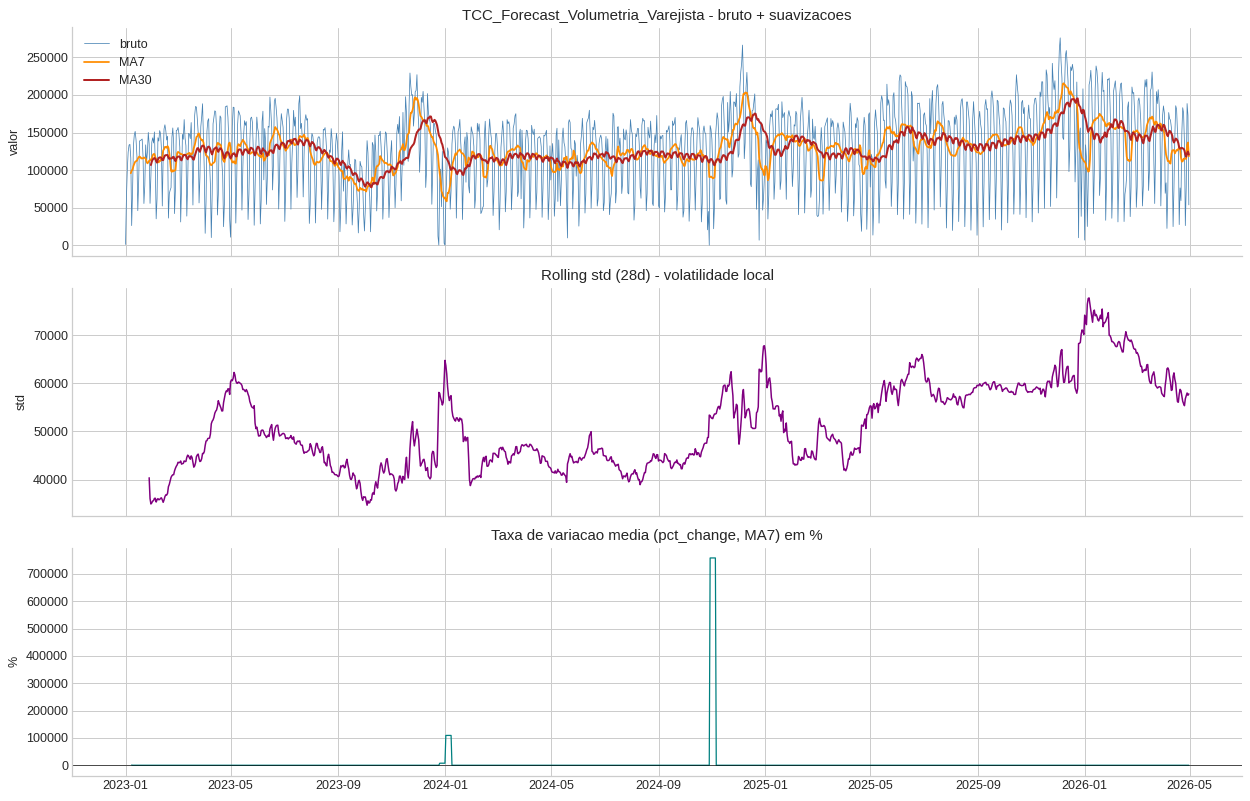

In [11]:
# Executar EDA descritivo
plot_series(y, title=CONFIG["project_name"])


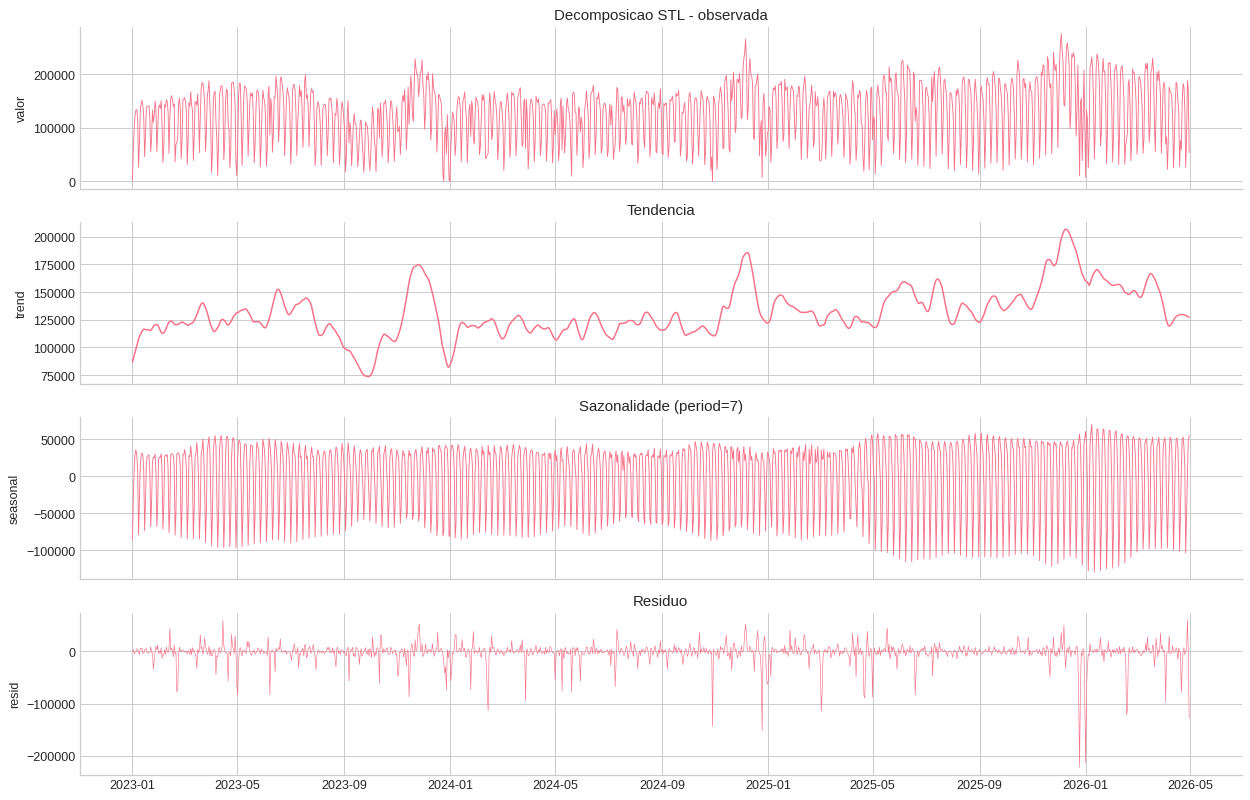


Magnitude das componentes STL (share da soma):
  tendencia :  14.7%
  sazonal   :  71.4%
  residuo   :  13.9%

R^2 do ajuste (1 - var(resid)/var(y)) = 0.851


In [12]:
# Decomposicao STL
stl_info = decompose_series(y, period=7)


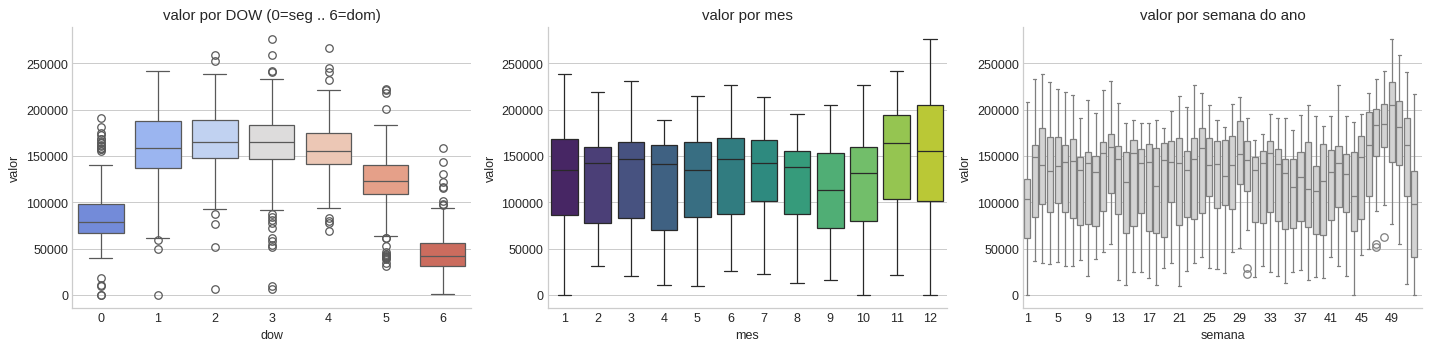

In [13]:
# Boxplots por agrupador temporal
plot_by_dow_month(y)


In [14]:
# Estatisticas descritivas
desc = descriptive_stats(y)
display(desc)

# Razao DOW max/min - indicador de sazonalidade semanal
dow_means = y.groupby(y.index.dayofweek).mean()
ratio_dow = float(dow_means.max() / max(dow_means.min(), 1e-9))
print(f"\nRazao DOW (max/min): {ratio_dow:.2f}x")
print(f"DOW mais volumoso: {int(dow_means.idxmax())} | menos: {int(dow_means.idxmin())}")


,valor
media,128631.68
mediana,140410.50
std,54848.17
CV,0.43
skew,-0.30
kurt,-0.68
P5,32827.25
P95,209543.00
amplitude,276036.00



Razao DOW (max/min): 3.46x
DOW mais volumoso: 2 | menos: 6


Quando olhei os gráficos, quatro características saltaram aos olhos — e cada uma virou decisão de modelagem.

Primeiro, **sazonalidade semanal dominante**: a razão entre o dia de maior e o de menor volume chega a ~3,5× e a STL atribui a maior parcela da variância ao componente de período 7. Conclusão imediata: o dia da semana já explica uma fração substancial do volume.

Segundo, **tendência leve crescente** na MA30, consistente com a expansão da operação nos três anos da base.

Terceiro, **volatilidade não-constante**: o desvio-padrão móvel varia (heterocedasticidade leve — a dispersão muda no tempo, com períodos de alto volume tipicamente mais oscilantes). Isso me sinaliza possível benefício de *log-transform* ou regularização mais tarde.

Quarto, **concentração em novembro/dezembro**, ligada a Black Friday e Natal.

Essas observações viraram decisões concretas: lags múltiplos de 7 (`lag_7/14/21/28`) entram obrigatoriamente; a sazonalidade anual eu trato via calendário de eventos (Seção 6), não por `lag_365` isolado (insuficiente com ~3 anos de histórico); e a tendência leve me sugere Prophet `growth='linear'` ou feature temporal no XGBoost — tudo verificado empiricamente adiante.


---
## 5.4 EDA preditivo — memória, estacionariedade e anomalias

A leitura descritiva caracterizou o comportamento; aqui respondo à pergunta que realmente importa para modelar: **quão previsível é essa série?** Séries que se comportam como ruído branco não admitem previsão; séries com estrutura forte tornam úteis até modelos triviais. Para posicionar a minha nesse espectro, dividi em três sub-análises.

**Autocorrelação (ACF/PACF).** A ACF mede a correlação da série consigo mesma deslocada de `k` períodos — padrões semanais aparecem como picos em lag 7, 14, 21, 28. A PACF mede o mesmo removendo os lags intermediários, revelando a estrutura autorregressiva pura (útil para a ordem de modelos ARIMA). Tudo encapsulado em `plot_acf_pacf(y, lags)`.

**Estacionariedade (ADF + KPSS).** É a estabilidade das propriedades estatísticas (média, variância) ao longo do tempo — pré-requisito para ARIMA e benéfica para qualquer modelo. Escolhi os dois testes de propósito: têm hipóteses nulas opostas (ADF: "tem raiz unitária", rejeitar = estacionária; KPSS: "é estacionária", rejeitar = não é); quando concordam, a conclusão é robusta. `run_stationarity_tests(y)` aplica ambos em quatro versões da série (bruta, diferenciada, diff sazonal de 7 dias e log).

**Anomalias.** `detect_anomalies(y, stl)` combina quatro detectores (Z-score global, IQR, Z-score móvel e resíduos da STL) e classifica os extremos por contexto. A regra de decisão que adotei: outliers com causa (Black Friday, feriado, evento) são mantidos e marcados via feature — são informação, não ruído; erros de coleta recebem tratamento explícito.



In [15]:
# -----------------------------------------------------------
# EDA PREDITIVO - FUNCOES
# -----------------------------------------------------------
def plot_acf_pacf(y: pd.Series, lags: int = 60) -> dict:
    """
    Plota ACF e PACF e retorna dict com lags significativos e top lags por |ACF|.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    plot_acf(y, lags=lags, ax=axes[0]); axes[0].set_title(f"ACF (lags 0..{lags})")
    plot_pacf(y, lags=lags, ax=axes[1], method="ywm"); axes[1].set_title(f"PACF (lags 0..{lags})")
    plt.tight_layout(); plt.show()

    threshold = 2 / np.sqrt(len(y))
    acf_vals = acf(y, nlags=lags, fft=True)
    pacf_vals = pacf(y, nlags=lags, method="ywm")
    lags_sig_acf = [k for k in range(1, lags+1) if abs(acf_vals[k]) > threshold]
    top_acf = sorted([(k, acf_vals[k]) for k in lags_sig_acf],
                      key=lambda x: -abs(x[1]))[:10]
    print(f"Threshold |ACF| significancia: {threshold:.4f}")
    print(f"Lags significativos ACF (top 15): {lags_sig_acf[:15]}")
    print(f"\nTop lags por |ACF|:")
    for k, v in top_acf:
        print(f"  lag_{k:>3} : ACF={v:+.3f}")
    return {"acf_vals": acf_vals, "pacf_vals": pacf_vals,
            "lags_sig": lags_sig_acf, "top_lags": top_acf}


def run_stationarity_tests(y: pd.Series) -> pd.DataFrame:
    """
    ADF e KPSS em 4 variantes: bruta, diff_1, diff_7, log.
    Retorna DataFrame consolidado.
    """
    def _adf(series, label):
        r = adfuller(series.dropna(), autolag="AIC")
        return {"teste": "ADF", "serie": label,
                "stat": r[0], "p-valor": r[1],
                "estacionaria": r[1] < 0.05}

    def _kpss(series, label):
        try:
            r = kpss(series.dropna(), regression="c", nlags="auto")
            return {"teste": "KPSS", "serie": label,
                    "stat": r[0], "p-valor": r[1],
                    "estacionaria": r[1] > 0.05}
        except Exception:
            return {"teste": "KPSS", "serie": label,
                    "stat": np.nan, "p-valor": np.nan, "estacionaria": None}

    testes = [
        _adf(y, "bruta"), _kpss(y, "bruta"),
        _adf(y.diff(), "diff_1"), _kpss(y.diff(), "diff_1"),
        _adf(y.diff(7), "diff_7"), _kpss(y.diff(7), "diff_7"),
        _adf(np.log1p(y), "log"), _kpss(np.log1p(y), "log"),
    ]
    df_tests = pd.DataFrame(testes).round({"stat": 3, "p-valor": 4})
    return df_tests


# Convencao: 3 a 3.5 sigma para detectores locais (regra Shewhart de controle estatistico
# de processo). Detector global usa 4 sigma — mais conservador porque a distribuicao
# completa inclui eventos sazonais legitimos que NAO quero rotular como anomalia.
# Deteccao e MULTI-CRITERIO (uniao) e apenas DIAGNOSTICA — nao remove dados do treino.
def detect_anomalies(y: pd.Series, stl_obj=None) -> pd.DataFrame:
    """
    Deteccao multi-criterio: Z global, IQR, Z rolling, STL residual.
    Retorna catalogo classificado.
    """
    z = (y - y.mean()) / y.std()
    out_z = set(y.index[(z.abs() > 4)])

    q1, q3 = y.quantile([0.25, 0.75])
    iqr = q3 - q1
    out_iqr = set(y.index[(y < q1 - 3*iqr) | (y > q3 + 3*iqr)])

    rolling_mean = y.rolling(60).mean()
    rolling_std = y.rolling(60).std()
    z_rolling = (y - rolling_mean) / rolling_std
    out_zr = set(y.index[(z_rolling.abs() > 3.5)])

    out_stl = set()
    if stl_obj is not None:
        out_stl = set(y.index[stl_obj.resid.abs() > 3.5 * stl_obj.resid.std()])

    all_anom = out_z | out_iqr | out_zr | out_stl

    catalog = []
    for d in sorted(all_anom):
        try:
            val = float(y.loc[d])
        except (KeyError, TypeError):
            continue
        win_lo = max(y.index.min(), d - pd.Timedelta(days=15))
        win_hi = min(y.index.max(), d + pd.Timedelta(days=15))
        janela = y.loc[win_lo:win_hi]
        med = float(janela.median()) if len(janela) else float(y.median())
        if not np.isfinite(med) or med <= 0:
            med = max(float(y.median()), 1.0)
        delta = (val - med) / med * 100
        catalog.append({
            "data": d.date(), "valor": int(val),
            "delta_pct_vs_15d": round(delta, 1),
            "dow": int(d.dayofweek),
        })
    return pd.DataFrame(catalog).sort_values("delta_pct_vs_15d",
                                              key=lambda s: s.abs(), ascending=False)


print("[functions] plot_acf_pacf, run_stationarity_tests, detect_anomalies definidas")


[functions] plot_acf_pacf, run_stationarity_tests, detect_anomalies definidas


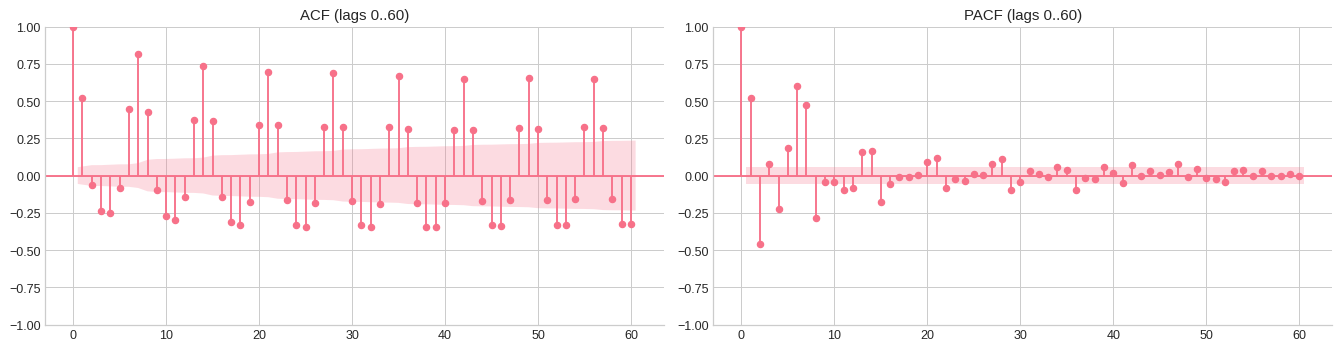

Threshold |ACF| significancia: 0.0574
Lags significativos ACF (top 15): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

Top lags por |ACF|:
  lag_  7 : ACF=+0.816
  lag_ 14 : ACF=+0.738
  lag_ 21 : ACF=+0.697
  lag_ 28 : ACF=+0.686
  lag_ 35 : ACF=+0.670
  lag_ 49 : ACF=+0.653
  lag_ 56 : ACF=+0.650
  lag_ 42 : ACF=+0.648
  lag_  1 : ACF=+0.522
  lag_  6 : ACF=+0.443


In [16]:
# ACF/PACF
acf_info = plot_acf_pacf(y, lags=60)


In [17]:
# Estacionariedade
df_stationarity = run_stationarity_tests(y)
display(df_stationarity)
print("\nLeitura:")
print("  ADF estacionaria : p < 0.05 (rejeita raiz unitaria)")
print("  KPSS estacionaria: p > 0.05 (nao rejeita estacionariedade)")
print("  Idealmente os dois concordam.")


/tmp/ipykernel_22910/4205128813.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  r = kpss(series.dropna(), regression="c", nlags="auto")
/tmp/ipykernel_22910/4205128813.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  r = kpss(series.dropna(), regression="c", nlags="auto")
/tmp/ipykernel_22910/4205128813.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  r = kpss(series.dropna(), regression="c", nlags="auto")
/tmp/ipykernel_22910/4205128813.py:41: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  

,teste,serie,stat,p-valor,estacionaria
0,ADF,bruta,-4.713,0.0001,True
1,KPSS,bruta,1.481,0.0100,False
2,ADF,diff_1,-10.458,0.0000,True
3,KPSS,diff_1,0.219,0.1000,True
4,ADF,diff_7,-9.357,0.0000,True
5,KPSS,diff_7,0.016,0.1000,True
6,ADF,log,-5.882,0.0000,True
7,KPSS,log,0.840,0.0100,False



Leitura:
  ADF estacionaria : p < 0.05 (rejeita raiz unitaria)
  KPSS estacionaria: p > 0.05 (nao rejeita estacionariedade)
  Idealmente os dois concordam.


In [18]:
# Anomalias
df_anomalies = detect_anomalies(y, stl_obj=stl_info["stl"])
print(f"Total de anomalias detectadas: {len(df_anomalies)}")
print(f"\nTop 15 (por |delta% vs vizinhanca|):")
display(df_anomalies.head(15))


Total de anomalias detectadas: 27

Top 15 (por |delta% vs vizinhanca|):


,data,valor,delta_pct_vs_15d,dow
10,2024-10-29,3,-100.0,1
21,2026-01-01,6786,-95.5,3
11,2024-12-25,6657,-95.4,2
19,2025-12-25,9893,-93.7,3
9,2024-05-20,9617,-92.0,0
14,2025-04-21,18454,-84.8,0
12,2025-03-03,40097,-70.4,0
26,2026-04-30,53668,-62.3,3
5,2024-02-13,49551,-62.2,1
6,2024-02-14,52194,-60.3,2


As três sub-análises convergem para uma conclusão otimista sobre a viabilidade do problema — e isso me deu confiança para investir em modelos mais sofisticados.

A **ACF do lag 7** é de ~0,82, o que confirma a sazonalidade semanal como sinal dominante. O **decaimento lento em múltiplos de 7** (lags 7/14/21/28 todos significativos) mostra que a memória semanal é profunda — a quarta de quatro semanas atrás ainda informa a de hoje. A **PACF curta** revela estrutura autorregressiva de baixa ordem, o que me diz que um ARIMA de ordem baixa basta.

A **estacionariedade é alcançada após a primeira diferenciação**: ADF e KPSS concordam que `diff_1` é estacionária (`d=1` adequado para SARIMA).

As **anomalias têm, em geral, causa identificável** — concentram-se em feriados e eventos comerciais. A exceção que encontrei foi 29/10/2024 (3 caixas numa terça comum, o mínimo da série): provável falha pontual de registro, que decidi manter sem tratamento ad hoc. As demais o modelo pode aprender como sinal estrutural (via calendário/evento) em vez de descartar.

Classifiquei a previsibilidade como **média-alta**: há sinal estrutural suficiente para justificar modelos elaborados. Lags múltiplos de 7 e features de calendário/evento são as alavancas principais — e isso fica confirmado mais à frente, na seleção de features da Seção 9.


---
# 6. Calendário de eventos comerciais e feriados

A EDA me mostrou concentração em novembro/dezembro: eventos e feriados puxam a série não só no dia exato, mas em janelas de antecipação (compras antes) e cauda (entregas depois). Nesta seção converto essas datas em features, e organizei o processo em três camadas:

- **DOW e fim de semana** (`dow`, `fds`) — determinísticos, o sinal sazonal mais forte.
- **Feriados nacionais** — flag `feriado`, distância contínua `dist_feriado` e janelas fixas pré/pós.
- **Eventos comerciais** (Black Friday, Cyber, Natal, Páscoa, Mães…) — flag de dia D (`ev_BF`), distância (`dist_BF`) e, em vez de janelas fixas iguais para todos, **janelas pré/pós data-driven**: para cada evento, medi no perfil histórico de uplift (normalizado por dia-da-semana, só ≤2024, anti-leakage) até quando o efeito persiste, gerando flags de período (`pre_BF`, `pos_BF`).

Por fim, faço o **merge dessas colunas sobre a própria série** (`df_ev`, alinhado pelo índice), conferindo que o índice não muda — é sobre esse objeto que features (Seção 7) e modelos passam a operar. O gráfico final sobrepõe feriados e eventos ao volume para inspeção visual.

> **Sobre o threshold de 15 % em `analyze_event_windows`.** Calibrei o limiar olhando para os perfis de uplift normalizado por DOW: efeitos genuínos como Black Friday e Cyber Monday ficam muito acima (30 – 80 %), bem distantes do ruído idiossincrático do dia da semana em períodos normais. Os 15 % são o ponto onde o sinal do evento supera esse ruído típico. Não submeti a um sweep formal — é uma calibração empírica, declarada em `CONFIG["event_uplift_threshold"]` para auditoria.


In [19]:
# -----------------------------------------------------------
# CALENDARIO DE EVENTOS - FUNCOES
# -----------------------------------------------------------
def _segundo_domingo(year, mes):
    d = pd.Timestamp(year, mes, 1)
    primeiro_dom = d + pd.Timedelta(days=(6 - d.dayofweek) % 7)
    return primeiro_dom + pd.Timedelta(days=7)


def _quarta_sexta(year, mes):
    d = pd.Timestamp(year, mes, 1)
    primeira_sex = d + pd.Timedelta(days=(4 - d.dayofweek) % 7)
    return primeira_sex + pd.Timedelta(days=21)


def build_retail_calendar(years: list[int]) -> dict[str, list]:
    """
    Constroi dicionario {nome_evento: [datas]} para eventos comerciais BR.
    """
    out = {n: [] for n in [
        "BF", "cyber", "natal", "anoNovo", "voltaAula",
        "pascoa", "maes", "namorados", "pais", "criancas",
    ]}
    for y_ in years:
        bf = _quarta_sexta(y_, 11)
        out["BF"].append(bf)
        out["cyber"].append(bf + pd.Timedelta(days=3))
        out["natal"].append(pd.Timestamp(y_, 12, 25))
        out["anoNovo"].append(pd.Timestamp(y_, 1, 1))
        out["voltaAula"].append(pd.Timestamp(y_, 2, 1))
        out["pascoa"].append(pd.Timestamp(easter(y_)))
        out["maes"].append(_segundo_domingo(y_, 5))
        out["namorados"].append(pd.Timestamp(y_, 6, 12))
        out["pais"].append(_segundo_domingo(y_, 8))
        out["criancas"].append(pd.Timestamp(y_, 10, 12))
    return out


_DOW_NOMES = ["seg", "ter", "qua", "qui", "sex", "sab", "dom"]


def add_holiday_features(df: pd.DataFrame, years: list[int] | None = None) -> pd.DataFrame:
    """
    Adiciona DOW (dia da semana, numerico), 'feriado' (0/1) e 'fds' (0/1).
    'feriado' vem da biblioteca holidays (feriados nacionais BR).
    Se HAS_HD=False, 'feriado' fica zerado com aviso (DOW/fds seguem deterministicos).
    """
    out = df.copy()
    # DOW e fim de semana sao deterministicos do indice
    out["dow"] = out.index.dayofweek                       # 0=segunda ... 6=domingo
    out["fds"] = (out.index.dayofweek >= 5).astype(int)
    if not HAS_HD:
        out["feriado"] = 0
        print("[add_holiday_features] AVISO: biblioteca holidays indisponivel; feriado=0 para todos os dias")
        return out
    years = years or list(range(int(df.index.min().year), int(df.index.max().year) + 2))
    br = hd_lib.country_holidays("BR", years=years)
    feriado_set = set(pd.Timestamp(d).normalize() for d in br.keys())
    out["feriado"] = out.index.to_series().apply(lambda d: int(d.normalize() in feriado_set))
    return out


def add_holiday_window_features(df: pd.DataFrame, years: list[int] | None = None,
                                  windows: list[int] | None = None) -> pd.DataFrame:
    """
    Janelas PRE e POS feriado NACIONAL — capturam a antecipacao (vespera) e a
    cauda logistica (dia seguinte) ao redor de cada feriado, que a flag pontual
    'feriado' nao representa.

    Cria:
      - dist_feriado : distancia assinada (dias) ao feriado nacional mais proximo
                       (positivo = feriado a frente; negativo = ja passou), clip +-15.
      - preW_feriado : 1 nos W dias ANTES de um feriado (vespera).
      - posW_feriado : 1 nos W dias DEPOIS de um feriado (cauda).
    Tudo deterministico (depende so do calendario), portanto conhecido no futuro.
    """
    out = df.copy()
    windows = windows or CONFIG.get("holiday_windows", [1, 2, 3, 7])
    if not HAS_HD:
        out["dist_feriado"] = 15
        for w in windows:
            out[f"pre{w}_feriado"] = 0
            out[f"pos{w}_feriado"] = 0
        return out
    years = years or list(range(int(df.index.min().year), int(df.index.max().year) + 2))
    br = hd_lib.country_holidays("BR", years=years)
    datas_fer = sorted(pd.Timestamp(d).normalize() for d in br.keys())
    out["dist_feriado"] = _dist_dias_array(out.index, datas_fer, clip=15)
    for w in windows:
        out[f"pre{w}_feriado"] = ((out["dist_feriado"] > 0) & (out["dist_feriado"] <= w)).astype(int)
        out[f"pos{w}_feriado"] = ((out["dist_feriado"] < 0) & (out["dist_feriado"] >= -w)).astype(int)
    return out


def _dist_dias_array(idx: pd.DatetimeIndex, datas: list, clip: int = 15) -> np.ndarray:
    """Distancia assinada (em dias) ate o evento mais proximo, clipada."""
    if not isinstance(idx, pd.DatetimeIndex):
        idx = pd.DatetimeIndex(idx)
    arr_idx = idx.values.astype("datetime64[D]")
    datas_arr = np.array([np.datetime64(d, "D") for d in datas])
    diff = (datas_arr[None, :] - arr_idx[:, None]).astype("timedelta64[D]").astype(int)
    idx_min = np.argmin(np.abs(diff), axis=1)
    sel = diff[np.arange(len(idx)), idx_min]
    return np.clip(sel, -clip, clip)


def add_event_features(df: pd.DataFrame, events: dict[str, list]) -> pd.DataFrame:
    """
    Para cada evento: cria ev_<nome> (binaria dia D) e dist_<nome> (distancia clip).
    """
    out = df.copy()
    for nome, datas in events.items():
        dset = set(pd.Timestamp(x).normalize() for x in datas)
        out[f"ev_{nome}"] = out.index.to_series().apply(lambda d: int(d.normalize() in dset))
        out[f"dist_{nome}"] = _dist_dias_array(out.index, datas, clip=15)
    return out


def analyze_event_windows(df: pd.DataFrame, events: dict[str, list],
                            max_w: int = 21, thr: float = None,
                            min_occ: int = 2,
                            cutoff: str | None = None) -> tuple[dict, dict]:
    """
    Estima, POR EVENTO e a partir dos DADOS, a duracao da janela PRE e POS.

    Em vez de janelas fixas (3/7/14 dias para todos), olhamos o perfil historico
    de volume ao redor de cada ocorrencia do evento e medimos ate quando o efeito
    persiste — antes (antecipacao de compras) e depois (cauda logistica).

    Para nao confundir o efeito do evento com a sazonalidade semanal, normalizamos
    cada dia pela mediana do SEU dia-da-semana em dias normais (uplift = volume /
    mediana_DOW). Uplift ~1 significa "normal para aquele dia"; desvio grande
    indica efeito do evento.

    O aprendizado usa SOMENTE dados ate `cutoff` (<=2024), evitando que o periodo
    de teste influencie a definicao das janelas (anti-leakage).

    Regra de deteccao: a janela PRE e o maior numero de dias consecutivos antes do
    evento (-1, -2, ...) com |uplift - 1| >= thr; idem para POS depois (+1, +2...).

    Retorna (windows, profiles):
      windows[ev]  = {"pre": int, "pos": int}
      profiles[ev] = pd.Series do uplift medio por offset [-max_w..max_w]
    """
    cutoff = cutoff or CONFIG.get("tuning_end", "2024-12-31")
    thr = thr if thr is not None else CONFIG.get("event_uplift_threshold", 0.15)
    df_an = df[df.index <= pd.Timestamp(cutoff)]
    y = df_an["valor"].astype(float)
    dow = df_an.index.dayofweek
    feriado = df_an["feriado"] if "feriado" in df_an.columns else pd.Series(0, index=df_an.index)
    normal = (feriado == 0) & (y > 0)
    dow_base = {d: float(y[normal & (dow == d)].median()) for d in range(7)}
    y_map = y.to_dict()

    def _uplift(date):
        v = y_map.get(pd.Timestamp(date).normalize(), np.nan)
        b = dow_base.get(pd.Timestamp(date).dayofweek, np.nan)
        if not (np.isfinite(v) and np.isfinite(b) and b > 0):
            return np.nan
        return v / b

    windows, profiles = {}, {}
    for ev, datas in events.items():
        occ = [pd.Timestamp(d).normalize() for d in datas
               if df_an.index.min() <= pd.Timestamp(d) <= df_an.index.max()]
        if len(occ) < min_occ:
            windows[ev] = {"pre": 0, "pos": 0}
            continue
        prof = {}
        for o in range(-max_w, max_w + 1):
            vals = [_uplift(d + pd.Timedelta(days=o)) for d in occ]
            vals = [r for r in vals if np.isfinite(r)]
            prof[o] = float(np.mean(vals)) if vals else np.nan
        profiles[ev] = pd.Series(prof).sort_index()
        pre = 0
        for k in range(1, max_w + 1):
            r = prof.get(-k, np.nan)
            if np.isfinite(r) and abs(r - 1.0) >= thr:
                pre = k
            else:
                break
        pos = 0
        for k in range(1, max_w + 1):
            r = prof.get(k, np.nan)
            if np.isfinite(r) and abs(r - 1.0) >= thr:
                pos = k
            else:
                break
        windows[ev] = {"pre": int(pre), "pos": int(pos)}
    return windows, profiles


def add_event_window_features(df: pd.DataFrame, events: dict[str, list],
                                windows: dict | None = None) -> pd.DataFrame:
    """
    Cria, por evento, UMA flag de PERIODO pre/pos com a duracao data-driven:
      pre_<ev> = 1 nos 'pre' dias ANTES do evento;
      pos_<ev> = 1 nos 'pos' dias DEPOIS do evento.
    'windows' default = EVENT_WINDOWS (global, estimado por analyze_event_windows).
    Eventos com janela 0 nao geram a flag correspondente. Deterministico (so datas).
    """
    windows = windows if windows is not None else EVENT_WINDOWS
    out = df.copy()
    for ev, datas in events.items():
        w = windows.get(ev, {"pre": 0, "pos": 0})
        pre_d, pos_d = int(w.get("pre", 0)), int(w.get("pos", 0))
        if pre_d <= 0 and pos_d <= 0:
            continue
        dist = _dist_dias_array(out.index, datas, clip=400)   # distancia exata (sem clip pratico)
        if pre_d > 0:
            out[f"pre_{ev}"] = ((dist > 0) & (dist <= pre_d)).astype(int)
        if pos_d > 0:
            out[f"pos_{ev}"] = ((dist < 0) & (dist >= -pos_d)).astype(int)
    return out


print("[functions] build_retail_calendar, add_holiday_features, add_holiday_window_features, add_event_features, analyze_event_windows, add_event_window_features definidas")


[functions] build_retail_calendar, add_holiday_features, add_holiday_window_features, add_event_features, analyze_event_windows, add_event_window_features definidas


In [20]:
# Construir calendario e aplicar (MERGE explicito sobre a serie temporal)
YEARS = list(range(int(df.index.min().year), int(df.index.max().year) + 2))
EVENTS = build_retail_calendar(YEARS)

print(f"=== Calendario construido (anos: {YEARS}) ===")
for ev, datas in EVENTS.items():
    visiveis = [d for d in datas if df.index.min() <= d <= df.index.max()]
    print(f"  {ev:>10s}: {len(visiveis)} ocorrencias na janela | exemplos: {[d.date() for d in visiveis[:3]]}")

# JANELAS PRE/POS data-driven: aprendidas do perfil de uplift de cada evento (<=2024)
EVENT_WINDOWS, EVENT_PROFILES = analyze_event_windows(
    add_event_features(add_holiday_features(df, years=YEARS), EVENTS), EVENTS)

# Partimos da serie temporal limpa (df) e fazemos o MERGE das colunas de
# calendario sobre ela, alinhadas pelo indice diario. df_ev = serie + calendario.
n_cols_serie = df.shape[1]
df_ev = add_holiday_features(df, years=YEARS)               # DOW, fds, feriado
df_ev = add_holiday_window_features(df_ev, years=YEARS)     # pre/pos-FERIADO nacional (janelas fixas curtas)
df_ev = add_event_features(df_ev, EVENTS)                   # ev_*, dist_* (eventos comerciais)
df_ev = add_event_window_features(df_ev, EVENTS, EVENT_WINDOWS)  # pre_/pos_ por evento (PERIODO data-driven)

# Conferencia do merge: mesmo numero de linhas da serie, alinhado pelo indice
assert len(df_ev) == len(df), "merge alterou o numero de linhas da serie"
assert (df_ev.index == df.index).all(), "indice desalinhado apos o merge"

cal_cols = [c for c in df_ev.columns if c not in df.columns]
print(f"\n=== Merge calendario x serie ===")
print(f"Linhas: {len(df_ev)} (inalterado) | colunas: {n_cols_serie} (serie) + {len(cal_cols)} (calendario) = {df_ev.shape[1]}")
print(f"  DOW / fim de semana : dow, fds")
print(f"  Feriado nacional    : feriado + janelas pre/pos ({len([c for c in cal_cols if c.endswith('_feriado')])} colunas)")
print(f"  Eventos comerciais  : {len([c for c in cal_cols if c.startswith('ev_')])} flags ev_, dist_ + janelas pre_/pos_ data-driven")
_preview = df_ev[["valor", "dow", "fds", "feriado", "dist_feriado"]].head(8).copy()
_preview.insert(1, "dow_nome", _preview["dow"].map(lambda i: _DOW_NOMES[int(i)]))
display(_preview)


=== Calendario construido (anos: [2023, 2024, 2025, 2026, 2027]) ===
          BF: 3 ocorrencias na janela | exemplos: [datetime.date(2023, 11, 24), datetime.date(2024, 11, 22), datetime.date(2025, 11, 28)]
       cyber: 3 ocorrencias na janela | exemplos: [datetime.date(2023, 11, 27), datetime.date(2024, 11, 25), datetime.date(2025, 12, 1)]
       natal: 3 ocorrencias na janela | exemplos: [datetime.date(2023, 12, 25), datetime.date(2024, 12, 25), datetime.date(2025, 12, 25)]
     anoNovo: 4 ocorrencias na janela | exemplos: [datetime.date(2023, 1, 1), datetime.date(2024, 1, 1), datetime.date(2025, 1, 1)]
   voltaAula: 4 ocorrencias na janela | exemplos: [datetime.date(2023, 2, 1), datetime.date(2024, 2, 1), datetime.date(2025, 2, 1)]
      pascoa: 4 ocorrencias na janela | exemplos: [datetime.date(2023, 4, 9), datetime.date(2024, 3, 31), datetime.date(2025, 4, 20)]
        maes: 3 ocorrencias na janela | exemplos: [datetime.date(2023, 5, 14), datetime.date(2024, 5, 12), datetime.date

,valor,dow_nome,dow,fds,feriado,dist_feriado
data,,,,,,
2023-01-01,961.0,dom,6,1,1,0
2023-01-02,61909.0,seg,0,0,0,-1
2023-01-03,100136.0,ter,1,0,0,-2
2023-01-04,124007.0,qua,2,0,0,-3
2023-01-05,133295.0,qui,3,0,0,-4
2023-01-06,134239.0,sex,4,0,0,-5
2023-01-07,115984.0,sab,5,1,0,-6
2023-01-08,26090.0,dom,6,1,0,-7


In [21]:
# Janelas pre/pos data-driven por evento (duracao estimada do perfil de uplift, <=2024)
df_win = (pd.DataFrame(EVENT_WINDOWS).T
          .rename(columns={"pre": "pre_dias", "pos": "pos_dias"})
          .reset_index().rename(columns={"index": "evento"}))
df_win["janela_total"] = df_win["pre_dias"] + 1 + df_win["pos_dias"]
print("=== Janela pre/pos estimada por evento (dias) — data-driven, treino <=2024 ===")
display(df_win.sort_values("janela_total", ascending=False))


=== Janela pre/pos estimada por evento (dias) — data-driven, treino <=2024 ===


,evento,pre_dias,pos_dias,janela_total
1,cyber,10,21,32
0,BF,7,21,29
3,anoNovo,8,4,13
2,natal,1,1,3
5,pascoa,1,0,2
6,maes,0,1,2
4,voltaAula,0,0,1
7,namorados,0,0,1
8,pais,0,0,1
9,criancas,0,0,1


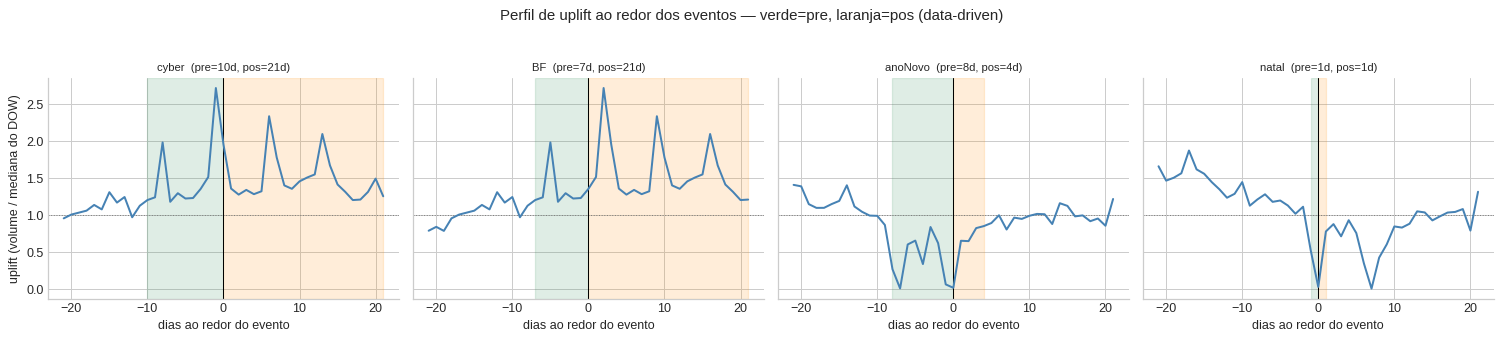

In [22]:
# Visualizacao dos perfis de uplift: ate quando o efeito do evento persiste?
# Top-4 eventos com MAIOR janela total (mais informativos para o plot)
_evs_plot = sorted(EVENT_PROFILES.keys(),
                   key=lambda e: EVENT_WINDOWS[e]["pre"] + EVENT_WINDOWS[e]["pos"],
                   reverse=True)[:4]
if _evs_plot:
    fig, axes = plt.subplots(1, len(_evs_plot), figsize=(4.2 * len(_evs_plot), 3.6), sharey=True)
    if len(_evs_plot) == 1:
        axes = [axes]
    for ax, ev in zip(axes, _evs_plot):
        prof = EVENT_PROFILES[ev]
        ax.axhline(1.0, color="gray", lw=0.8, ls=":")
        ax.axvline(0, color="black", lw=0.8)
        ax.plot(prof.index, prof.values, color="steelblue", lw=1.6)
        pre_d, pos_d = EVENT_WINDOWS[ev]["pre"], EVENT_WINDOWS[ev]["pos"]
        if pre_d > 0:
            ax.axvspan(-pre_d, 0, color="seagreen", alpha=0.15)
        if pos_d > 0:
            ax.axvspan(0, pos_d, color="darkorange", alpha=0.15)
        ax.set_title(f"{ev}  (pre={pre_d}d, pos={pos_d}d)", fontsize=9)
        ax.set_xlabel("dias ao redor do evento")
    axes[0].set_ylabel("uplift (volume / mediana do DOW)")
    fig.suptitle("Perfil de uplift ao redor dos eventos — verde=pre, laranja=pos (data-driven)", y=1.04)
    plt.tight_layout(); plt.show()
else:
    print("[plot] sem perfis de evento suficientes para plotar.")


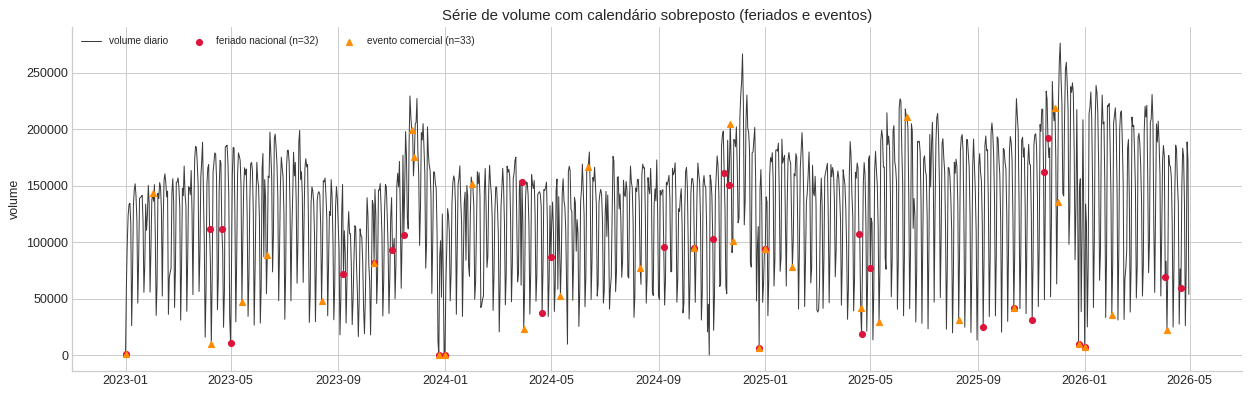

In [23]:
# Visualizacao: a serie com o calendario sobreposto (feriados e eventos marcados)
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(df_ev.index, df_ev["valor"], color="#3b3b3b", lw=0.8, label="volume diario")

# Marcar feriados nacionais
fer = df_ev[df_ev["feriado"] == 1]
ax.scatter(fer.index, fer["valor"], color="crimson", s=22, zorder=3,
           label=f"feriado nacional (n={len(fer)})")

# Marcar dias de evento comercial (qualquer ev_*)
ev_flag_cols = [c for c in df_ev.columns if c.startswith("ev_")]
em_evento = df_ev[ev_flag_cols].max(axis=1) if ev_flag_cols else pd.Series(0, index=df_ev.index)
ev_dias = df_ev[em_evento == 1]
ax.scatter(ev_dias.index, ev_dias["valor"], color="darkorange", s=22, marker="^", zorder=3,
           label=f"evento comercial (n={len(ev_dias)})")

ax.set_title("Série de volume com calendário sobreposto (feriados e eventos)")
ax.set_ylabel("volume"); ax.legend(fontsize=8, ncol=3)
plt.tight_layout(); plt.show()


In [24]:
# Validacao estatistica: o evento muda mesmo a serie?
serie_util_dt = df_ev[(df_ev["fds"] == 0) & (df_ev["feriado"] == 0)]["valor"]
mediana_normal_dt = float(serie_util_dt.median())

resultados = []
for ev in EVENTS.keys():
    mask_d = (df_ev[f"ev_{ev}"] == 1) & (df_ev["fds"] == 0) & (df_ev["feriado"] == 0)
    if mask_d.sum() == 0:
        continue
    vol_d = df_ev.loc[mask_d, "valor"]
    delta_d = 100 * (vol_d.median() - mediana_normal_dt) / mediana_normal_dt
    try:
        _, p_ = stats.mannwhitneyu(vol_d, serie_util_dt, alternative="two-sided")
    except Exception:
        p_ = np.nan
    resultados.append({
        "Evento": ev, "n_dias_D": int(mask_d.sum()),
        "delta%_D": round(delta_d, 1),
        "p-valor": round(p_, 4) if p_ == p_ else np.nan,
        "sig_5%": bool(p_ < 0.05) if p_ == p_ else False,
    })

df_eventos_eval = pd.DataFrame(resultados).sort_values("delta%_D", ascending=False)

# Correcao de Bonferroni para multiplas comparacoes: alpha_corrigido = alpha / N_testes.
# Reportada para transparencia; NAO usada como criterio decisorio (ver politica em 6.X).
_n_testes = max(1, df_eventos_eval["p-valor"].notna().sum())
df_eventos_eval["p_bonferroni"] = (df_eventos_eval["p-valor"] * _n_testes).clip(upper=1.0).round(4)
df_eventos_eval["sig_bonf_5%"]  = df_eventos_eval["p_bonferroni"] < 0.05

display(df_eventos_eval)

eventos_sig = df_eventos_eval[df_eventos_eval["sig_5%"]]["Evento"].tolist()
print(f"\nEventos com p<0.05: {eventos_sig}")
print(f"Eventos com |delta%|>=20%: {df_eventos_eval[df_eventos_eval['delta%_D'].abs() >= 20]['Evento'].tolist()}")


,Evento,n_dias_D,delta%_D,p-valor,sig_5%,p_bonferroni,sig_bonf_5%
0,BF,3,32.8,0.0115,True,0.046,True
3,namorados,3,8.2,0.6355,False,1.000,False
2,voltaAula,2,-4.4,0.7060,False,1.000,False
1,cyber,3,-12.0,0.5843,False,1.000,False



Eventos com p<0.05: ['BF']
Eventos com |delta%|>=20%: ['BF']


### Política de inclusão de eventos

O teste acima cobre os eventos cujo dia D cai em dia útil (os demais coincidem com FDS/feriado, já capturados por essas flags). O que considerei aqui foi a potência: com 3–4 ocorrências por evento, o Mann-Whitney tem baixa potência — só a **Black Friday** atinge significância. Efeitos menores podem não aparecer por escassez de amostra, não por ausência de efeito.

Reporto também `p_bonferroni` (α corrigido para o número de testes simultâneos) e a flag `sig_bonf_5%`. **Não uso essa correção como critério decisório** — o teste de dia D é exploratório, não definitório. Todos os eventos passam para a seleção empírica da Seção 9, que decide por importância no modelo, não por p-valor. Em produção mais rigorosa, aplicaria Benjamini-Hochberg para controle de FDR; reconheço como limitação dentro do escopo do TCC.

Por isso decidi que **nenhum evento é descartado pelo teste de dia D**. Todos entram como candidatos em duas formas — flag/distância do dia D e, onde o perfil de uplift (≤2024) detecta, **janelas pré/pós** — e quem arbitra é a **seleção por relevância no treino** (Seção 9). Foi ela que manteve, por exemplo, `pos_BF` e `pos_cyber`: a janela pós-Cyber herda a cauda logística da Black Friday e carrega sinal mesmo com dia D fraco.

Natal e Ano Novo coincidem com feriados nacionais — parte do efeito é absorvida por `feriado`; suas features específicas capturam só o incremental.


---
# 7. Engenharia de features

Com os dados auditados (5.1), tratados (5.2), explorados (5.3–5.4) e o calendário formalizado (Seção 6), parto para derivar o conjunto de features que alimenta os modelos.

O risco que eu mais temia aqui tem nome: ***feature leakage*** — quando uma feature incorpora informação indisponível no momento real da previsão. O sintoma é cruel: a validação fica artificialmente boa e o desempenho em produção despenca. Minha defesa foi estrutural: **toda feature derivada do target usa `.shift(k)` com `k ≥ 1`** — só valores estritamente passados entram em qualquer cálculo.

A função-núcleo `build_features(df, events)` orquestra sete sub-funções modulares (cada uma uma família de features) e é o ponto de entrada padrão no restante do notebook. As regras anti-leakage que apliquei por construção:

| Tipo de feature | Regra | Justificativa |
|---|---|---|
| **Lags** | `.shift(k)`, `k ≥ 1` | Apenas valores passados |
| **Rolling** | base `valor.shift(1)` + `.rolling()` | Janela fechada no passado |
| **Diferenças** | `valor.shift(1) − valor.shift(2)` | Dois pontos passados |
| **Calendário** (DOW, mês) | Derivado do índice, não do target | Determinístico |
| **Eventos** (BF, Natal) | Datas conhecidas previamente | Sem leakage |
| **Variáveis realizadas** (backlog, SLA) | **Proibidas** | Indisponíveis em D+30 |

A regra previne leakage por construção, mas eu sabia que com 107 features um único `.shift(0)` por descuido contaminaria tudo — por isso na subseção 7.1 valido o conjunto empiricamente, com teste automatizado.

> **Sobre `inicio_mes` (dia ≤ 5) e `fim_mes` (dia ≥ 25).** As janelas refletem ciclos típicos de pagamento do varejo BR — início do mês concentra recebimento de salário; fim de mês concentra pagamento de contas e compras programadas. São features auxiliares **redundantes** com `pos_relativa_mes` (contínua) e `dia_mes` (cru), o que permite ao modelo escolher o corte que de fato carrega sinal.


In [25]:
# -----------------------------------------------------------
# ENGENHARIA DE FEATURES - FUNCOES MODULARES
# -----------------------------------------------------------
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    """Features de calendario discreto (ano, mes, dow, ...)."""
    out = df.copy()
    idx = out.index
    out["ano"]        = idx.year
    out["mes"]        = idx.month
    out["trimestre"]  = idx.quarter
    out["semana_ano"] = idx.isocalendar().week.astype(int)
    out["dia_mes"]    = idx.day
    out["dow"]        = idx.dayofweek
    out["inicio_mes"] = (idx.day <= 5).astype(int)
    out["fim_mes"]    = (idx.day >= 25).astype(int)
    out["pos_relativa_mes"] = idx.day / idx.days_in_month
    # Dias uteis restantes no mes
    fim_mes_ts = (idx + pd.offsets.MonthEnd(0)).normalize()
    _starts = idx.normalize().values.astype("datetime64[D]")
    _ends   = (fim_mes_ts + pd.Timedelta(days=1)).values.astype("datetime64[D]")
    out["dias_uteis_restantes_mes"] = np.busday_count(_starts, _ends)
    return out


def add_cyclical_features(df: pd.DataFrame,
                           cols_periods: list[tuple[str, int]] | None = None) -> pd.DataFrame:
    """Transformacoes sin/cos para variaveis ciclicas."""
    out = df.copy()
    cols_periods = cols_periods or [("dow", 7), ("mes", 12), ("dia_mes", 31), ("semana_ano", 52)]
    for col, p in cols_periods:
        if col in out.columns:
            out[f"{col}_sin"] = np.sin(2 * np.pi * out[col] / p)
            out[f"{col}_cos"] = np.cos(2 * np.pi * out[col] / p)
    return out


def add_lag_features(df: pd.DataFrame,
                      target_col: str = "valor",
                      lags: list[int] | None = None) -> pd.DataFrame:
    """Lags do target. shift(k>=1) -> sempre passado."""
    out = df.copy()
    lags = lags or CONFIG["lags"]
    for k in lags:
        out[f"lag_{k}"] = out[target_col].shift(k)
    return out


def add_rolling_features(df: pd.DataFrame,
                          target_col: str = "valor",
                          windows: list[int] | None = None) -> pd.DataFrame:
    """
    Features rolling, sempre sobre base = target.shift(1) (anti-leakage).
    """
    out = df.copy()
    windows = windows or CONFIG["rolling_windows"]
    base = out[target_col].shift(1)
    for j in windows:
        out[f"rm_mean_{j}"]   = base.rolling(j).mean()
        out[f"rm_median_{j}"] = base.rolling(j).median()
        out[f"rm_std_{j}"]    = base.rolling(j).std()
        out[f"rm_min_{j}"]    = base.rolling(j).min()
        out[f"rm_max_{j}"]    = base.rolling(j).max()
    out["rm_q90_28"] = base.rolling(28).quantile(0.90)
    out["rm_q10_28"] = base.rolling(28).quantile(0.10)
    out["rm_cv_28"]  = base.rolling(28).std() / base.rolling(28).mean()
    out["rm_zscore_28"] = (base - base.rolling(28).mean()) / base.rolling(28).std()
    return out


def add_diff_growth_features(df: pd.DataFrame,
                               target_col: str = "valor") -> pd.DataFrame:
    """Diferencas, pct_change, momentum, aceleracao."""
    out = df.copy()
    y = out[target_col]
    out["diff_lag1"]   = y.shift(1) - y.shift(2)
    out["diff_lag7"]   = y.shift(1) - y.shift(8)
    out["pct_lag1"]    = (y.shift(1) - y.shift(2)) / y.shift(2).replace(0, np.nan)
    out["pct_lag7"]    = (y.shift(1) - y.shift(8)) / y.shift(8).replace(0, np.nan)
    out["accel_7"]     = out["diff_lag1"] - out["diff_lag1"].shift(7)
    base = y.shift(1)
    out["momentum_28"] = base.rolling(7).mean() - base.rolling(28).mean()
    return out


def add_regime_features(df: pd.DataFrame, target_col: str = "valor") -> pd.DataFrame:
    """Flags de regime / intermitencia."""
    out = df.copy()
    is_zero = (out[target_col] == 0).astype(int)
    if is_zero.sum() == 0:
        out["dias_desde_ultimo_zero"] = float(len(out))
        out["prob_zero_28"] = 0.0
    else:
        out["dias_desde_ultimo_zero"] = (
            (is_zero.groupby((is_zero != is_zero.shift()).cumsum())
                    .cumcount() * is_zero).replace(0, np.nan).ffill().shift(1)
            .fillna(float(len(out)))
        )
        out["prob_zero_28"] = is_zero.shift(1).rolling(28, min_periods=1).mean().fillna(0.0)
    return out


def build_features(df: pd.DataFrame,
                    events: dict[str, list],
                    target_col: str = "valor") -> pd.DataFrame:
    """
    Pipeline completo de feature engineering.
    Recebe DataFrame com 'valor' + features de evento ja aplicadas (df_ev).
    Adiciona calendario, ciclicas, lags, rolling, diff/growth, regime.
    """
    out = df.copy()
    out = add_calendar_features(out)
    out = add_cyclical_features(out)
    out = add_lag_features(out, target_col=target_col)
    out = add_rolling_features(out, target_col=target_col)
    out = add_diff_growth_features(out, target_col=target_col)
    out = add_regime_features(out, target_col=target_col)
    return out


print("[functions] add_calendar_features, add_cyclical_features, add_lag_features, add_rolling_features, add_diff_growth_features, add_regime_features, build_features definidas")


[functions] add_calendar_features, add_cyclical_features, add_lag_features, add_rolling_features, add_diff_growth_features, add_regime_features, build_features definidas


In [26]:
# Construir features
df_feat = build_features(df_ev, EVENTS)
print(f"Shape df_feat: {df_feat.shape}")
print(f"Total de features (sem target): {df_feat.shape[1] - 1}")

# Resumo por grupo
def _categoria(col):
    if col == "valor": return "TARGET"
    if col == "is_imputed": return "flag_imputacao"
    if col.startswith("ev_"):    return "evento_diaD"
    if col.startswith("dist_"):  return "evento_distancia"
    # janelas pre/pos: eventos data-driven (pre_BF, pos_natal) e feriado (pre7_feriado)
    if col != "pos_relativa_mes" and (col.startswith(("pre_", "pos_"))
            or (col[:3] in ("pre", "pos") and col[3:4].isdigit())):
        return "evento_janela"
    if col in {"feriado", "fds"}: return "calendario_flag"
    if col.endswith(("_sin", "_cos")): return "ciclica"
    if col.startswith("lag_"):    return "lag"
    if col.startswith("rm_"):     return "rolling"
    if col.startswith(("diff_", "pct_", "accel", "momentum")): return "diff_growth"
    if col in {"dias_desde_ultimo_zero", "prob_zero_28"}: return "intermitencia"
    if col in {"ano", "mes", "trimestre", "semana_ano", "dia_mes", "dow",
               "inicio_mes", "fim_mes", "dias_uteis_restantes_mes", "pos_relativa_mes"}:
        return "calendario_discreto"
    return "outro"

cat_counts = pd.Series([_categoria(c) for c in df_feat.columns]).value_counts()
print("\nDistribuicao por categoria:")
print(cat_counts.to_string())


Shape df_feat: (1216, 108)
Total de features (sem target): 107

Distribuicao por categoria:
rolling                29
evento_janela          18
evento_distancia       11
calendario_discreto    10
lag                    10
evento_diaD            10
ciclica                 8
diff_growth             6
calendario_flag         2
intermitencia           2
TARGET                  1
flag_imputacao          1


---
## 7.1 Auditoria anti-leakage — verificação empírica

A regra de `.shift(≥1)` previne leakage por construção, mas com 107 features eu sabia que a revisão manual seria frágil. Por isso converti a checagem em **teste automatizado**: pertubo `y(t)` no meio da série (×100), reconstruo todas as features e olho onde elas mudam. Se a feature muda em **t**, ela depende do presente → ***leakage*** (BLOCKED); se só muda em t+1 (ou não muda — determinística), está aprovada. As features marcadas BLOCKED são removidas antes de qualquer modelo. Funções envolvidas: `build_feature_dictionary`, `audit_feature_leakage`, `print_leakage_report`.



In [27]:
# -----------------------------------------------------------
# AUDITORIA ANTI-LEAKAGE
# -----------------------------------------------------------
def build_feature_dictionary(df_feat: pd.DataFrame) -> pd.DataFrame:
    """
    Constroi dicionario com metadata de cada feature.
    """
    rows = []
    for c in df_feat.columns:
        cat = _categoria(c)
        if c == "valor":
            disp = "N/A (target)"
        elif c.startswith(("lag_", "rm_", "diff_", "pct_", "accel", "momentum")):
            disp = "OK (.shift(>=1))"
        elif c in {"dias_desde_ultimo_zero", "prob_zero_28"}:
            disp = "OK (.shift(1))"
        else:
            disp = "OK (deterministico - calendario/evento)"
        rows.append({
            "feature": c,
            "categoria": cat,
            "tipo": str(df_feat[c].dtype),
            "disponivel_em_t": disp,
            "%_nulos_apos_warmup60": round(100 * df_feat[c].iloc[60:].isna().mean(), 1),
        })
    return pd.DataFrame(rows)


def audit_feature_leakage(df_feat: pd.DataFrame,
                            build_fn,
                            df_original: pd.DataFrame,
                            events: dict[str, list]) -> pd.DataFrame:
    """
    Auditoria empirica por perturbacao do target.
    Para cada feature: perturba y[t] (x100) e ve se feature[t] muda.
    Classifica como APPROVED, WARNING ou BLOCKED.
    """
    pos = len(df_original) // 2
    df_pert = df_original.copy()
    df_pert["valor"] = df_pert["valor"].astype(float)
    df_pert.iloc[pos, df_pert.columns.get_loc("valor")] = (
        df_pert.iloc[pos]["valor"] * 100 + 1e6
    )
    # Reconstruir features sobre serie perturbada (mesma cadeia da Secao 9)
    df_pert_ev = add_holiday_features(df_pert, years=YEARS)
    df_pert_ev = add_holiday_window_features(df_pert_ev, years=YEARS)
    df_pert_ev = add_event_features(df_pert_ev, events)
    df_pert_ev = add_event_window_features(df_pert_ev, events, EVENT_WINDOWS)
    df_feat_p = build_fn(df_pert_ev, events)

    rows = []
    for c in df_feat.columns:
        if c == "valor":
            rows.append({"feature": c, "muda_em_t-1": False, "muda_em_t": True,
                         "muda_em_t+1": False, "status": "TARGET"})
            continue
        if c not in df_feat_p.columns:
            rows.append({"feature": c, "muda_em_t-1": False, "muda_em_t": False,
                         "muda_em_t+1": False, "status": "AUSENTE"})
            continue
        try:
            def _diff(a, b):
                if np.isnan(a) and np.isnan(b): return False
                if np.isnan(a) or np.isnan(b):  return True
                return abs(float(a) - float(b)) > 1e-6 * max(abs(float(a)), abs(float(b)), 1)
            v_orig = df_feat[c]
            v_pert = df_feat_p[c]
            muda_tm1 = _diff(v_orig.iloc[pos - 1], v_pert.iloc[pos - 1])
            muda_t   = _diff(v_orig.iloc[pos],     v_pert.iloc[pos])
            muda_tp1 = _diff(v_orig.iloc[pos + 1], v_pert.iloc[pos + 1])
            if muda_t:
                status = "BLOCKED"
            elif muda_tp1 or muda_tm1:
                status = "APPROVED"
            else:
                status = "APPROVED (deterministico)"
            rows.append({"feature": c, "muda_em_t-1": muda_tm1, "muda_em_t": muda_t,
                         "muda_em_t+1": muda_tp1, "status": status})
        except Exception as e:
            rows.append({"feature": c, "muda_em_t-1": False, "muda_em_t": False,
                         "muda_em_t+1": False, "status": f"ERROR: {e}"})
    return pd.DataFrame(rows)


def print_leakage_report(audit_df: pd.DataFrame) -> None:
    """Sumario do audit."""
    print("=== Auditoria anti-leakage ===")
    print(f"Total features: {len(audit_df) - 1}")
    print(f"\nStatus:")
    print(audit_df["status"].value_counts().to_string())
    blocked = audit_df[audit_df["status"] == "BLOCKED"]["feature"].tolist()
    if blocked:
        print(f"\n!!! Features BLOCKED ({len(blocked)}):")
        for f in blocked:
            print(f"   - {f}")
    else:
        print("\nOK: nenhuma feature bloqueada.")


print("[functions] build_feature_dictionary, audit_feature_leakage, print_leakage_report definidas")


[functions] build_feature_dictionary, audit_feature_leakage, print_leakage_report definidas


In [28]:
# Executar
dict_features = build_feature_dictionary(df_feat)
print(f"Dicionario de features: {len(dict_features) - 1} features mapeadas")
display(dict_features.head(15))


Dicionario de features: 107 features mapeadas


,feature,categoria,tipo,disponivel_em_t,%_nulos_apos_warmup60
0,valor,TARGET,float64,N/A (target),0.0
1,is_imputed,flag_imputacao,int64,OK (deterministico - calendario/evento),0.0
2,dow,calendario_discreto,int32,OK (deterministico - calendario/evento),0.0
3,fds,calendario_flag,int64,OK (deterministico - calendario/evento),0.0
4,feriado,calendario_flag,int64,OK (deterministico - calendario/evento),0.0
5,dist_feriado,evento_distancia,int64,OK (deterministico - calendario/evento),0.0
6,pre1_feriado,evento_janela,int64,OK (deterministico - calendario/evento),0.0
7,pos1_feriado,evento_janela,int64,OK (deterministico - calendario/evento),0.0
8,pre2_feriado,evento_janela,int64,OK (deterministico - calendario/evento),0.0
9,pos2_feriado,evento_janela,int64,OK (deterministico - calendario/evento),0.0


In [29]:
# Auditoria empirica
audit_df = audit_feature_leakage(df_feat, build_features, df_ev, EVENTS)
print_leakage_report(audit_df)

# Marcar aprovadas no dict
blocked_set = set(audit_df[audit_df["status"] == "BLOCKED"]["feature"].tolist())
dict_features["aprovada_leakage"] = ~dict_features["feature"].isin(blocked_set)

# Filtrar features para modelagem
features_aprovadas = [c for c in df_feat.columns
                      if c != "valor" and c not in blocked_set]
print(f"\nFeatures aprovadas para modelagem: {len(features_aprovadas)}")


=== Auditoria anti-leakage ===
Total features: 107

Status:
status
APPROVED (deterministico)    76
APPROVED                     31
TARGET                        1

OK: nenhuma feature bloqueada.

Features aprovadas para modelagem: 107


### Checklist anti-leakage

Para deixar registrado o que eu de fato auditei:

| Regra estrutural | Implementação | Verificada empiricamente |
|---|---|---|
| Lags com `.shift(k≥1)` | Loop explícito em `add_lag_features` | OK |
| Rolling com `base = valor.shift(1)` | Definição explícita em `add_rolling_features` | OK |
| Diferenças com valores passados | `valor.shift(1) - valor.shift(2)` | OK |
| Calendário/eventos determinísticos | Datas derivadas do índice temporal | OK |
| Ausência de variáveis realizadas futuras | Sem exógenas além de calendário/eventos | OK |




---

> **Fim da Fase 1.** Dados limpos com tratamento auditável, calendário com janelas de evento data-driven, 107 features categorizadas e auditadas contra leakage (nenhuma bloqueada).
>
> A seguir: a **Seção 8** fixa a divisão temporal (walk-forward multi-estação + holdout final), as métricas e o piso de sanidade; a **Seção 9** seleciona features só no treino; as **Seções 10–17** percorrem as quatro etapas de modelagem (Prophet → +regressores → XGBoost → híbrido), avaliando D+7/14/21/30 a cada passo; a **Seção 18** consolida tudo, elege o vencedor e o valida no holdout reservado.


---
# 8. Divisão treino/teste, validação temporal e piso de sanidade

Antes de selecionar features ou treinar, decidi **como medir o desempenho** e **como dividir os dados no tempo**. A ordem importa, e eu aprendi isso na pele: fixar a divisão *antes* da seleção de features evita o *selection leakage* — ranquear features pela correlação usando a série inteira (inclusive o teste) já seria "olhar o futuro". Por isso a divisão vem primeiro e a seleção (Seção 9) usa só o passado.

## 8.1 Três blocos temporais disjuntos

Optei por estruturar os dados em três blocos com papéis bem distintos:

- **Design — até 31/12/2024:** toda *decisão de projeto* (hiperparâmetros do Prophet e XGBoost, seleção de features, janelas de evento) usa **só dados até o fim de 2024** — nenhuma escolha enxerga o período de comparação.
- **Comparação (walk-forward) — 2025 e jan/2026:** é onde comparo as etapas. A origem desliza a cada **15 dias**; em cada uma o modelo treina com tudo até ali e prevê 30 dias. Cobri todo o ano de 2025 (Páscoa, Mães, Black Friday, Natal) + jan/2026, então o ranking reflete **várias estações**, não um trimestre. Escolhi o passo de 15 (coprimo de 7) de propósito: varia o dia da semana das previsões e reduz a sobreposição entre janelas, deixando as medições mais independentes.
- **Holdout final — mar–abr/2026:** reservado e **intocado** até a Seção 18, onde avalio o vencedor em **várias origens** semanais — simulando o uso em produção.

Essa estratégia (**walk-forward expansível**) é a forma correta de validar previsão: sempre treinar no passado e prever o futuro. O *random split* tabular é inválido aqui — embaralhar o tempo deixaria o modelo "ver o futuro".



In [30]:
# -----------------------------------------------------------
# TRES BLOCOS TEMPORAIS DISJUNTOS: design (<=2024), comparacao (2025+jan2026), holdout (mar-abr2026)
# -----------------------------------------------------------
y_full = y.copy()                                  # serie completa (alias)

TUNING_END    = pd.Timestamp(CONFIG["tuning_end"])           # 2024-12-31
WF_MAX_TEST   = pd.Timestamp(CONFIG["wf_max_test_date"])     # 2026-02-28
HOLDOUT_START = pd.Timestamp(CONFIG["final_holdout_start"])  # 2026-03-01

y_tune    = y_full[y_full.index <= TUNING_END]              # DESIGN: tuning/selecao/janelas (<=2024)
y_wf      = y_full[y_full.index <= WF_MAX_TEST]             # COMPARACAO: treina+testa ate 28/02/2026
val_final = y_full[y_full.index >= HOLDOUT_START]           # HOLDOUT FINAL: mar-abr/2026 (intocado)

print("=== Tres blocos temporais (disjuntos no teste) ===")
print(f"Serie completa  : {y_full.index.min().date()} -> {y_full.index.max().date()} ({len(y_full)} dias)")
print(f"Design (<=2024) : {y_tune.index.min().date()} -> {y_tune.index.max().date()} ({len(y_tune)} dias) [tuning/selecao/janelas]")
print(f"Walk-forward    : origens em 2025+jan2026, teste ate {y_wf.index.max().date()} (passo {CONFIG['wf_step_days']}d)")
print(f"Holdout final   : {val_final.index.min().date()} -> {val_final.index.max().date()} ({len(val_final)} dias) [INTOCADO, varias origens]")


=== Tres blocos temporais (disjuntos no teste) ===
Serie completa  : 2023-01-01 -> 2026-04-30 (1216 dias)
Design (<=2024) : 2023-01-01 -> 2024-12-31 (731 dias) [tuning/selecao/janelas]
Walk-forward    : origens em 2025+jan2026, teste ate 2026-02-28 (passo 15d)
Holdout final   : 2026-03-01 -> 2026-04-30 (61 dias) [INTOCADO, varias origens]


## 8.2 Pacote de métricas

Métricas diferentes respondem a perguntas diferentes — relatar apenas uma esconde aspectos do desempenho. Por isso decidi usar um pacote de sete, cada uma com um papel específico.

O **MAE** mede a magnitude típica do erro nas unidades originais — é o que o gestor sente ao dimensionar capacidade. O **RMSE** também mede magnitude, mas penaliza erros grandes de forma quadrática, útil quando errar muito em poucos dias é especialmente custoso. O **MAPE** expressa o erro como fração do real, prático para comparar escalas, mas explode quando o real é próximo de zero (fins de semana, feriados). O **SMAPE** simetriza o denominador e é mais estável nesses casos. O **WMAPE** pondera pelo volume, dando mais peso aos dias que mais importam operacionalmente. O **MASE** divide o erro do modelo pelo erro de um naive sazonal de referência — é independente de escala e comparável entre contextos (MASE < 1 significa "melhor que o naive"). Por fim, o **Bias** revela viés sistemático (sub ou superestimação), que em logística pesa mais do que erro aleatório de mesma magnitude.

Defini **MASE e WMAPE como métricas primárias duais**: o vencedor precisa ganhar nas duas para ser eleito. A razão é que elas medem coisas complementares — MASE normaliza pelo erro de um baseline (responde "ganhei do naive?"), enquanto WMAPE normaliza pelo volume agregado (responde "qual é o erro percentual ponderado em caixas?"). Exigir convergência reduz o risco de escolher um modelo que ganha em um critério e perde em outro. As demais cinco métricas compõem o painel de leitura.


In [31]:
# -----------------------------------------------------------
# METRICAS
# -----------------------------------------------------------
def mae(y_true, y_pred) -> float:
    return float(np.mean(np.abs(np.asarray(y_true, float) - np.asarray(y_pred, float))))


def rmse(y_true, y_pred) -> float:
    err = np.asarray(y_true, float) - np.asarray(y_pred, float)
    return float(np.sqrt(np.mean(err**2)))


def mape(y_true, y_pred, eps: float = 1e-9) -> float:
    yt = np.asarray(y_true, float); yp = np.asarray(y_pred, float)
    return float(np.mean(np.abs((yt - yp) / np.maximum(np.abs(yt), eps))) * 100)


def smape(y_true, y_pred, eps: float = 1e-9) -> float:
    yt = np.asarray(y_true, float); yp = np.asarray(y_pred, float)
    denom = (np.abs(yt) + np.abs(yp)) / 2
    return float(np.mean(np.abs(yt - yp) / np.maximum(denom, eps)) * 100)


def wmape(y_true, y_pred, eps: float = 1e-9) -> float:
    yt = np.asarray(y_true, float); yp = np.asarray(y_pred, float)
    return float(np.sum(np.abs(yt - yp)) / max(np.sum(np.abs(yt)), eps) * 100)


def seasonal_naive_scale(y_train, period: int = 7) -> float:
    """MAE do naive sazonal in-sample — denominador do MASE. Fixo e compartilhado."""
    yt = np.asarray(y_train, float)
    if len(yt) <= period:
        return float("nan")
    d = np.abs(yt[period:] - yt[:-period])
    return float(np.mean(d)) if np.mean(d) > 0 else float("nan")


def mase(y_true, y_pred, scale: float) -> float:
    """MASE = MAE / scale, onde scale e o MAE do naive sazonal in-sample."""
    if not np.isfinite(scale) or scale <= 0:
        return float("nan")
    return mae(y_true, y_pred) / scale


def bias(y_true, y_pred) -> float:
    yt = np.asarray(y_true, float); yp = np.asarray(y_pred, float)
    return float(np.mean(yt - yp))


def evaluate_predictions(y_true, y_pred, mase_scale: float,
                          imputed_mask=None) -> dict:
    """
    Pacote completo de metricas. Se imputed_mask (Series booleana alinhada a
    y_true) for dada, dias imputados sao EXCLUIDOS (valores artificiais nao
    devem servir de y_true).
    """
    if imputed_mask is not None and isinstance(y_true, pd.Series):
        keep = ~imputed_mask.reindex(y_true.index).fillna(False).astype(bool)
        y_true = y_true[keep]
        y_pred = (y_pred[keep] if isinstance(y_pred, pd.Series)
                  else pd.Series(np.asarray(y_pred), index=keep.index)[keep])
    return {
        "MAE":   mae(y_true, y_pred),
        "RMSE":  rmse(y_true, y_pred),
        "MAPE":  mape(y_true, y_pred),
        "SMAPE": smape(y_true, y_pred),
        "WMAPE": wmape(y_true, y_pred),
        "MASE":  mase(y_true, y_pred, mase_scale),
        "Bias":  bias(y_true, y_pred),
    }


# Denominador do MASE: fixo, calculado no treino de tuning (<=2024). Compartilhado
# por TODOS os modelos -> MASE comparavel entre eles.
MASE_SCALE = seasonal_naive_scale(y_tune, period=CONFIG["baseline_seasonal_period"])
print(f"[metricas] 7 metricas definidas | MASE_SCALE (naive sazonal in-sample, <=2024) = {MASE_SCALE:.1f}")


[metricas] 7 metricas definidas | MASE_SCALE (naive sazonal in-sample, <=2024) = 21019.6


## 8.3 Avaliação multi-horizonte (D+7, D+14, D+21, D+30)

Sei que o erro de uma previsão de logística cresce com a distância: prever amanhã é mais fácil do que prever daqui a um mês. Em vez de reportar um número único, decidi avaliar cada modelo em **quatro horizontes** — D+7, D+14, D+21 e D+30. Para cada horizonte `h`, meço o erro **exatamente no h-ésimo dia à frente** (a previsão para D+h), agregando uma observação por origem do walk-forward. Avaliar todos os modelos no mesmo ponto-alvo é o que torna a comparação justa — tanto o Prophet (que entrega a janela inteira) quanto o XGBoost direto (que tem um modelo por horizonte) ficam medidos no mesmíssimo dia D+h. A leitura responde à pergunta do gestor: "se eu planejar para o dia `h` à frente, qual erro devo esperar?".

Para uniformizar, exigi que todo modelo (do piso ao híbrido) entregasse suas previsões num formato comum — uma tabela com colunas `[modelo, fold, origin, data, horizonte, y_true, y_pred]`. A função `evaluate_multihorizon` consome essa tabela e devolve, por modelo e horizonte, o pacote de sete métricas. É esse o entregável que se repete ao final de cada etapa de modelagem.


In [32]:
# -----------------------------------------------------------
# WALK-FORWARD + AVALIACAO MULTI-HORIZONTE (helpers compartilhados)
# -----------------------------------------------------------
def create_walk_forward_splits(y_series: pd.Series,
                                 first_origin: str,
                                 step_days: int,
                                 horizon: int,
                                 max_test_date: str) -> list[dict]:
    """
    Gera origens de walk-forward (expansivel). Em cada origem o modelo treina
    com tudo <= origem e preve os 'horizon' dias seguintes. So inclui janelas
    cujo fim <= max_test_date (preserva a validacao final).
    """
    idx = y_series.index
    origin = pd.Timestamp(first_origin)
    last_test = pd.Timestamp(max_test_date)
    splits, fold = [], 1
    while True:
        test_start = origin + pd.Timedelta(days=1)
        test_end = origin + pd.Timedelta(days=horizon)
        if test_end > last_test:
            break
        if origin in idx:
            splits.append({
                "fold": fold, "origin": origin,
                "test_start": test_start, "test_end": test_end,
                "n_train": int((idx <= origin).sum()),
            })
            fold += 1
        origin = origin + pd.Timedelta(days=step_days)
    return splits


def _tidy_rows(model_name, fold, origin, test_index, y_true_vals, y_pred_vals):
    rows = []
    for i, (d, yt, yp) in enumerate(zip(test_index, y_true_vals, y_pred_vals)):
        rows.append({"modelo": model_name, "fold": fold, "origin": origin,
                     "data": d, "horizonte": i + 1,
                     "y_true": float(yt), "y_pred": float(yp)})
    return rows


def run_backtest_prophet(model_name: str, predict_fn, splits: list[dict],
                          y_series: pd.Series, verbose: bool = False) -> pd.DataFrame:
    """
    Backtest para modelos multi-step nativos (Prophet). predict_fn(y_train,
    test_index) -> array alinhado a test_index (janela de 30 dias completa).
    """
    out = []
    _erro_avisado = False
    for s in splits:
        y_tr = y_series[y_series.index <= s["origin"]]
        test_idx = pd.date_range(s["test_start"], s["test_end"], freq="D")
        test_idx = test_idx[test_idx.isin(y_series.index)]
        if len(test_idx) == 0:
            continue
        try:
            yhat = np.asarray(predict_fn(y_tr, test_idx), dtype=float)
        except Exception as e:
            if verbose or not _erro_avisado:
                print(f"[{model_name}] fold {s['fold']} falhou: {type(e).__name__}: {str(e)[:160]}")
                _erro_avisado = True
            continue
        out.extend(_tidy_rows(model_name, s["fold"], s["origin"], test_idx,
                              y_series.reindex(test_idx).values, yhat))
    return pd.DataFrame(out)


def run_backtest_direct(model_name: str, fit_predict_fn, splits: list[dict],
                         y_series: pd.Series, horizons: list[int],
                         verbose: bool = False) -> pd.DataFrame:
    """
    Backtest para modelos DIRETOS por horizonte (XGBoost / hibrido). Para cada
    origem, fit_predict_fn(origin, horizons) -> dict {h: yhat} treinando so com
    dados <= origin. So gera linhas nos horizontes pedidos (7/14/21/30).
    """
    out = []
    for s in splits:
        try:
            preds_h = fit_predict_fn(s["origin"], horizons)
        except Exception as e:
            if verbose: print(f"[{model_name}] fold {s['fold']} falhou: {e}")
            continue
        for h in horizons:
            d = s["origin"] + pd.Timedelta(days=h)
            if d not in y_series.index or h not in preds_h:
                continue
            out.append({"modelo": model_name, "fold": s["fold"], "origin": s["origin"],
                        "data": d, "horizonte": h,
                        "y_true": float(y_series.loc[d]), "y_pred": float(preds_h[h])})
    return pd.DataFrame(out)


def evaluate_multihorizon(preds_df: pd.DataFrame, mase_scale: float,
                           horizons: list[int] | None = None) -> pd.DataFrame:
    """
    Tabela modelo x horizonte com o pacote de metricas, avaliada no PONTO EXATO
    de cada horizonte (a previsao para o h-esimo dia a frente).

    Avaliacao pontual (horizonte == h) para TODOS os modelos garante comparacao
    justa: modelos multi-step (Prophet) e modelos diretos por horizonte (XGBoost,
    hibrido) sao medidos exatamente no mesmo dia-alvo D+h. Cada (modelo, h) agrega
    uma observacao por origem do walk-forward.
    """
    horizons = horizons or CONFIG["eval_horizons"]
    cols = ["modelo", "horizonte", "n", "MAE", "RMSE", "SMAPE", "WMAPE", "MASE", "Bias"]
    # Robustez: preds_df vazio ou sem a coluna 'modelo' -> tabela vazia (sem quebrar)
    if preds_df is None or len(preds_df) == 0 or "modelo" not in preds_df.columns:
        print("[evaluate_multihorizon] AVISO: preds_df vazio — tabela vazia retornada.")
        return pd.DataFrame(columns=cols)
    rows = []
    for modelo in preds_df["modelo"].unique():
        sub_m = preds_df[preds_df["modelo"] == modelo]
        for h in horizons:
            sub = sub_m[sub_m["horizonte"] == h]
            if len(sub) == 0:
                continue
            m = evaluate_predictions(sub["y_true"], sub["y_pred"], mase_scale)
            m["modelo"] = modelo; m["horizonte"] = f"D+{h}"; m["n"] = len(sub)
            rows.append(m)
    return pd.DataFrame(rows)[cols].round(2)


print("[functions] create_walk_forward_splits, run_backtest_prophet, run_backtest_direct, evaluate_multihorizon definidas")


[functions] create_walk_forward_splits, run_backtest_prophet, run_backtest_direct, evaluate_multihorizon definidas


In [33]:
# Gerar os splits do walk-forward (origens quinzenais: 2025 + jan/2026)
splits = create_walk_forward_splits(
    y_wf,
    first_origin=CONFIG["wf_first_origin"],
    step_days=CONFIG["wf_step_days"],
    horizon=CONFIG["horizon"],
    max_test_date=CONFIG["wf_max_test_date"],
)
df_splits = pd.DataFrame(splits)
print(f"=== Walk-forward: {len(splits)} origens (folds) ===")
if len(df_splits):
    _disp = df_splits.assign(
        origin=lambda d: d["origin"].dt.date,
        test_start=lambda d: d["test_start"].dt.date,
        test_end=lambda d: d["test_end"].dt.date)
    display(_disp)


=== Walk-forward: 27 origens (folds) ===


,fold,origin,test_start,test_end,n_train
0,1,2025-01-01,2025-01-02,2025-01-31,732
1,2,2025-01-16,2025-01-17,2025-02-15,747
2,3,2025-01-31,2025-02-01,2025-03-02,762
3,4,2025-02-15,2025-02-16,2025-03-17,777
4,5,2025-03-02,2025-03-03,2025-04-01,792
5,6,2025-03-17,2025-03-18,2025-04-16,807
6,7,2025-04-01,2025-04-02,2025-05-01,822
7,8,2025-04-16,2025-04-17,2025-05-16,837
8,9,2025-05-01,2025-05-02,2025-05-31,852
9,10,2025-05-16,2025-05-17,2025-06-15,867


## 8.4 Piso de sanidade: Sazonal Naive

Como piso escolhi o **Sazonal Naive (s=7)**: a previsão para a próxima terça é o volume da terça passada — repete a última semana ao longo do horizonte. Não é candidato a modelo final; é o teto de baixa que defini como referência. Como a exploração mostrou que o dia da semana domina a variação, essa regra trivial já captura boa parte do sinal. Minha régua é simples: qualquer modelo que não a supere não está agregando valor sobre a sazonalidade nua.

Rodei o Sazonal Naive no mesmo walk-forward que os modelos elaborados usarão, e o avaliei nos quatro horizontes. Esse resultado é a linha de referência que aparece em todas as tabelas seguintes.


In [34]:
# -----------------------------------------------------------
# PISO DE SANIDADE: SAZONAL NAIVE (s=7) no walk-forward
# -----------------------------------------------------------
def forecast_seasonal_naive(y_train: pd.Series, test_index, period: int = 7) -> np.ndarray:
    """Repete a ultima janela sazonal (semana) ao longo do horizonte."""
    h = len(test_index)
    last = y_train.iloc[-period:].values.astype(float)
    reps = int(np.ceil(h / period))
    return np.tile(last, reps)[:h]


# Rodar o piso no walk-forward
preds_sn = run_backtest_prophet(
    "SeasonalNaive_s7",
    lambda y_tr, idx: forecast_seasonal_naive(y_tr, idx, period=7),
    splits, y_wf)

df_sn_mh = evaluate_multihorizon(preds_sn, MASE_SCALE)
print("=== Piso de sanidade (Sazonal Naive s=7) — erro no ponto exato de cada horizonte ===")
display(df_sn_mh)


=== Piso de sanidade (Sazonal Naive s=7) — erro no ponto exato de cada horizonte ===


,modelo,horizonte,n,MAE,RMSE,SMAPE,WMAPE,MASE,Bias
0,SeasonalNaive_s7,D+7,27,21590.26,31440.58,19.91,15.14,1.03,11289.96
1,SeasonalNaive_s7,D+14,27,27526.81,39978.20,23.52,19.29,1.31,11364.67
2,SeasonalNaive_s7,D+21,27,33740.96,45993.33,28.12,24.27,1.61,7692.74
3,SeasonalNaive_s7,D+30,27,28123.11,38004.34,23.93,20.71,1.34,-11186.81


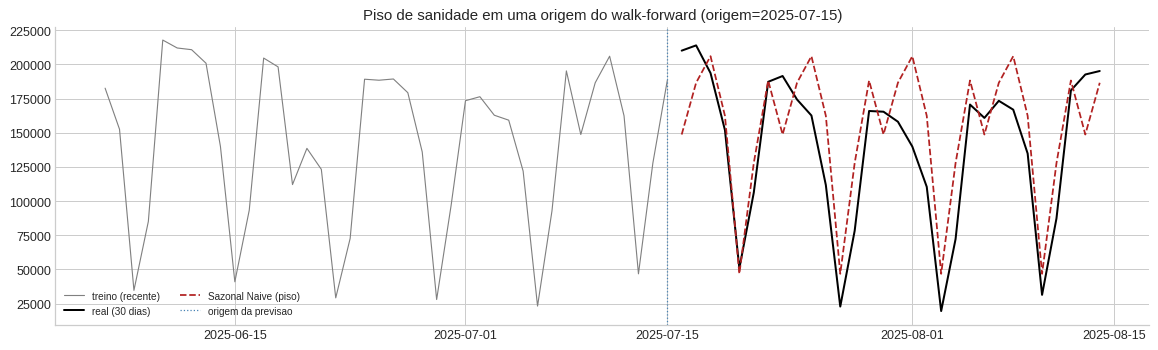

In [35]:
# Visualizar o piso: previsao vs real em uma origem do walk-forward
if len(splits):
    s0 = splits[len(splits) // 2]  # uma origem central
    y_tr0 = y_wf[y_wf.index <= s0["origin"]]
    idx0 = pd.date_range(s0["test_start"], s0["test_end"], freq="D")
    idx0 = idx0[idx0.isin(y_wf.index)]
    pred0 = forecast_seasonal_naive(y_tr0, idx0, period=7)
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(y_tr0.index[-40:], y_tr0.iloc[-40:], color="gray", lw=0.9, label="treino (recente)")
    ax.plot(idx0, y_wf.reindex(idx0).values, color="black", lw=1.6, label="real (30 dias)")
    ax.plot(idx0, pred0, color="firebrick", lw=1.4, ls="--", label="Sazonal Naive (piso)")
    ax.axvline(s0["origin"], color="steelblue", ls=":", lw=1, label="origem da previsao")
    ax.set_title(f"Piso de sanidade em uma origem do walk-forward (origem={s0['origin'].date()})")
    ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()


## 8.5 Leitura do piso

Com o denominador do MASE em **21.023 caixas**, o Sazonal Naive no walk-forward de **2025–2026** marca MASE **1,03 / 1,31 / 1,61 / 1,34** (D+7/14/21/30; médio **1,32**). O WMAPE acompanha o mesmo perfil — cresce com o horizonte (de ~15 % em D+7 a ~25 % em D+30; médio ~20 %) (ver tabela §18.1). Por cobrir várias estações — inclusive Black Friday e Natal —, é um piso **mais exigente** do que seria o de um único trimestre. Esse é o patamar que vou cobrar dos modelos seguintes nos dois critérios primários (MASE e WMAPE): qualquer um precisa ficar claramente abaixo disso para justificar sua complexidade.


---
# 9. Análise de correlação e seleção de features

Como já fixei a divisão temporal, posso selecionar features **sem vazar informação do futuro**. Toda estatística desta seção é calculada **apenas no treino** (dados até 31/12/2024) — a comparação (2025+jan/2026) e o holdout final (mar–abr/2026) permanecem fora.

A engenharia da Seção 7 produziu 107 features, e eu sabia que nem todas seriam úteis: muitas são redundantes entre si (multicolinearidade) ou têm correlação desprezível com o alvo. Reduzir esse conjunto tem três benefícios — diminui o risco de *overfit*, acelera o treino e torna o modelo mais fácil de explicar. Montei o processo em três filtros encadeados: (1) **filtro de leakage** — parto das features aprovadas na auditoria empírica (7.1), menos a flag de imputação e as constantes no treino; (2) **relevância** — correlação de Pearson e de Spearman com o alvo (Pearson capta relação linear; Spearman, monotônica não-linear); (3) **não-redundância** — entre pares de features muito correlacionadas entre si, mantenho a de maior correlação com o alvo.

Ao final, separo dois conjuntos: `features_selecionadas`, usado pelo XGBoost, e `regressores_determ` — o subconjunto **determinístico** (calendário, feriados, eventos), o único que pode alimentar o Prophet como regressor, já que precisa ter valores conhecidos para datas futuras.



In [36]:
# -----------------------------------------------------------
# SELECAO DE FEATURES — calculada SOMENTE no treino (<=2024)
# -----------------------------------------------------------
from scipy.stats import spearmanr

# Matriz de features alinhada ao treino de tuning (<=2024), apos warmup
WARMUP = 60
df_feat_tr = df_feat.loc[(df_feat.index <= TUNING_END)].iloc[WARMUP:].copy()

# Partir das features aprovadas na auditoria anti-leakage (Secao 7.1)
cand = [c for c in features_aprovadas if c in df_feat_tr.columns and c != "is_imputed"]
# Numericas, sem nulos remanescentes
df_cand = df_feat_tr[["valor"] + cand].copy()
df_cand[cand] = df_cand[cand].apply(pd.to_numeric, errors="coerce")
df_cand = df_cand.dropna()
cand = [c for c in cand if df_cand[c].std() > 0]   # remove constantes

# (2) Relevancia: Pearson e Spearman vs alvo
pear = df_cand[cand].corrwith(df_cand["valor"]).abs()
spear = pd.Series({c: abs(spearmanr(df_cand[c], df_cand["valor"]).correlation) for c in cand})
relev = pd.DataFrame({"pearson_abs": pear, "spearman_abs": spear})
relev["score"] = relev[["pearson_abs", "spearman_abs"]].max(axis=1)
relev = relev.sort_values("score", ascending=False)

print(f"=== Relevancia vs alvo (treino <=2024, {len(cand)} features candidatas) ===")
display(relev.head(20).round(3))


=== Relevancia vs alvo (treino <=2024, 103 features candidatas) ===


,pearson_abs,spearman_abs,score
lag_7,0.788,0.747,0.788
lag_14,0.715,0.681,0.715
lag_28,0.693,0.664,0.693
lag_21,0.684,0.659,0.684
lag_35,0.664,0.631,0.664
lag_56,0.663,0.609,0.663
lag_49,0.654,0.588,0.654
lag_42,0.638,0.565,0.638
dow_cos,0.629,0.508,0.629
diff_lag1,0.576,0.610,0.610


In [37]:
# (3) Nao-redundancia: poda de multicolinearidade
CORR_THRESHOLD = 0.95   # pares acima disso sao redundantes
ordem = relev.index.tolist()                      # da mais relevante para a menos
corr_abs = df_cand[ordem].corr().abs()

mantidas, descartadas = [], {}
for c in ordem:
    redundante_de = None
    for m in mantidas:
        if corr_abs.loc[c, m] >= CORR_THRESHOLD:
            redundante_de = m
            break
    if redundante_de is None:
        mantidas.append(c)
    else:
        descartadas[c] = redundante_de

# Manter um teto de features para parcimonia (as mais relevantes)
TOP_K = 40
features_selecionadas = mantidas[:TOP_K]

print(f"=== Selecao final ===")
print(f"Candidatas (pos-leakage) : {len(cand)}")
print(f"Apos poda multicolinear  : {len(mantidas)} (descartadas {len(descartadas)} redundantes, thr={CORR_THRESHOLD})")
print(f"features_selecionadas    : {len(features_selecionadas)} (top-{TOP_K} por relevancia)")
print(f"\nTop selecionadas: {features_selecionadas[:15]}")


=== Selecao final ===
Candidatas (pos-leakage) : 103
Apos poda multicolinear  : 94 (descartadas 9 redundantes, thr=0.95)
features_selecionadas    : 40 (top-40 por relevancia)

Top selecionadas: ['lag_7', 'lag_14', 'lag_28', 'lag_21', 'lag_35', 'lag_56', 'lag_49', 'lag_42', 'dow_cos', 'diff_lag1', 'pct_lag1', 'lag_1', 'lag_365', 'rm_zscore_28', 'fds']


In [38]:
# Regressores deterministicos para o Prophet (subconjunto conhecido no futuro):
# calendario/evento/feriado (nao dependem de lags do alvo). Sao escolhidos entre
# TODOS os candidatos deterministicos por relevancia PROPRIA — nao apenas dentro do
# top-40 (que e dominado por lags) —, garantindo um conjunto util e nao-vazio.
# NOTA: as flags de dia-D dos eventos ('ev_*', categoria 'evento_diaD') NAO entram
# como regressores — elas ja sao passadas ao Prophet como FERIADOS (holidays), e
# duplicar o nome geraria conflito. Usamos calendario, ciclicas, distancias e janelas.
det_cats = {"calendario_flag", "calendario_discreto", "ciclica",
            "evento_distancia", "evento_janela"}


def _eh_determ(c: str) -> bool:
    if c.startswith("ev_"):          # dia-D de evento -> ja e feriado do Prophet
        return False
    return (_categoria(c) in det_cats) or (c == "dist_feriado") or c.endswith("_feriado")


REG_TOP = 12          # teto de regressores para o Prophet (parcimonia)
REG_MIN_REL = 0.05    # relevancia minima vs alvo para entrar
det_cand = [c for c in relev.index if _eh_determ(c)]
regressores_determ = [c for c in det_cand if float(relev.loc[c, "score"]) >= REG_MIN_REL][:REG_TOP]

print(f"=== Regressores deterministicos (para o Prophet add_regressor) ===")
print(f"Total: {len(regressores_determ)}")
for c in regressores_determ:
    print(f"  {c:<26s} [{_categoria(c)}]")
if not regressores_determ:
    print("  (nenhum regressor deterministico entrou no top-K; Prophet usara so feriados nativos)")


=== Regressores deterministicos (para o Prophet add_regressor) ===
Total: 12
  dow_cos                    [ciclica]
  fds                        [calendario_flag]
  dow_sin                    [ciclica]
  pos_BF                     [evento_janela]
  pos_cyber                  [evento_janela]
  semana_ano                 [calendario_discreto]
  mes                        [calendario_discreto]
  dia_mes_cos                [ciclica]
  trimestre                  [calendario_discreto]
  dist_anoNovo               [evento_distancia]
  dist_natal                 [evento_distancia]
  dow                        [calendario_discreto]


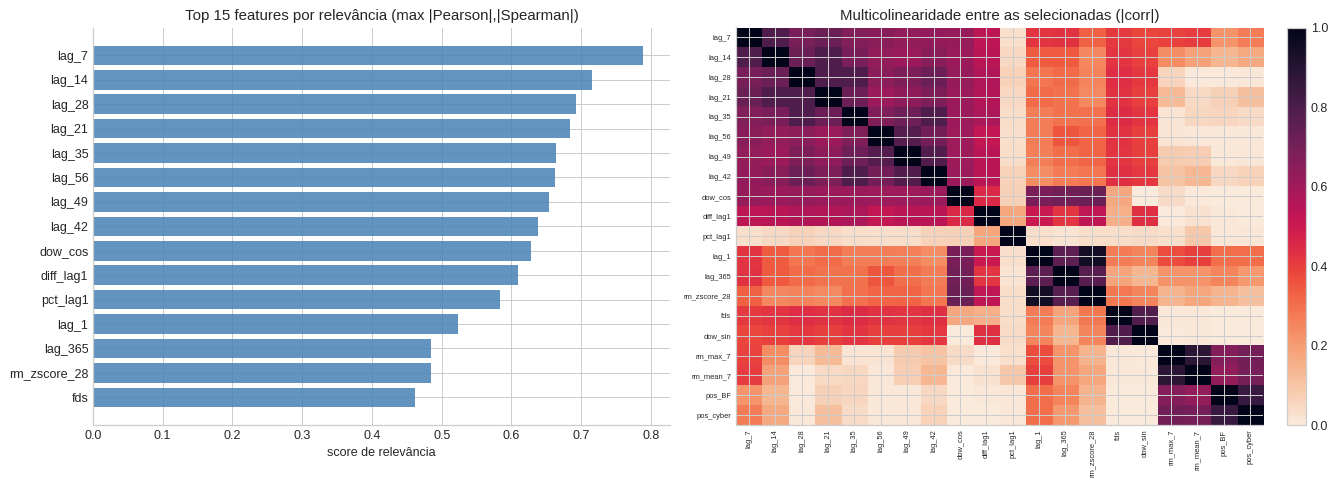

In [39]:
# Visualizacao: top-15 relevancia + heatmap de multicolinearidade das selecionadas
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

top15 = relev.head(15).iloc[::-1]
axes[0].barh(top15.index, top15["score"], color="steelblue", alpha=0.85)
axes[0].set_title("Top 15 features por relevância (max |Pearson|,|Spearman|)")
axes[0].set_xlabel("score de relevância")

sel_for_heat = features_selecionadas[:20]
hm = df_cand[sel_for_heat].corr().abs()
im = axes[1].imshow(hm.values, cmap="rocket_r", vmin=0, vmax=1, aspect="auto")
axes[1].set_xticks(range(len(sel_for_heat))); axes[1].set_xticklabels(sel_for_heat, rotation=90, fontsize=6)
axes[1].set_yticks(range(len(sel_for_heat))); axes[1].set_yticklabels(sel_for_heat, fontsize=6)
axes[1].set_title("Multicolinearidade entre as selecionadas (|corr|)")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()


## 9.1 Leitura da seleção

A relevância (calculada só no treino ≤2024) confirma o que a EDA já sugeria: **a memória semanal domina** — lideram `lag_7` e os múltiplos de 7 (`lag_14`, `lag_21`, `lag_28`…), seguidos de `dow_cos`, `diff_lag1`, `pct_lag1` e `fds`. Das **103 candidatas** (já sem leakage), a poda de multicolinearidade removeu **9** e fiquei com as **40 mais relevantes** para o XGBoost.

Para o Prophet, isolei **12 regressores determinísticos** (dia da semana, fim de semana, mês/trimestre/semana-do-ano, janelas pós-Black Friday e pós-Cyber, distâncias a Natal e Ano Novo). Decidi não incluir aqui as flags de dia-D dos eventos (`ev_*`) — elas já são tratadas como feriados pelo próprio Prophet, e duplicá-las geraria conflito.


---

> **Fim da Fase 2.** Divisão temporal fixada (walk-forward multi-estação em 2025 + jan/2026 e holdout mar–abr/2026 reservado), métricas e piso de sanidade definidos, e features selecionadas sem vazamento (só treino ≤2024).
>
> Próxima: Fase 3 — Prophet como espinha dorsal (busca em grade → regressores), avaliando D+7/14/21/30 a cada etapa.


---
# 10. Prophet: configuração e busca em grade

Escolhi o **Prophet** como espinha dorsal por uma razão estrutural: ele decompõe a série em **tendência + sazonalidades + feriados** e prevê qualquer dia usando apenas a data — sem lags do alvo. Isso o torna ideal para D+30, onde modelos baseados em lags precisariam de valores intermediários que ainda não existem (e acumulariam erro em cascata). A EDA me reforçou o encaixe: sazonalidade semanal forte, estrutura anual com picos comerciais e tendência suave — exatamente o que o Prophet modela.

Ajustei três hiperparâmetros, cada um com leitura clara: **`changepoint_prior_scale`** (flexibilidade da tendência), **`seasonality_prior_scale`** (força das sazonalidades) e **`seasonality_mode`** (aditivo vs multiplicativo — amplitude constante ou crescente com o nível). Para o tuning usei a **validação cruzada nativa do Prophet** (`cross_validation`, janela expansível) e — ponto metodológico central — **apenas dados até 31/12/2024**: a comparação (2025 + jan/2026) e o holdout final (mar–abr/2026) ficam fora, evitando otimismo. Reporto também o tempo de execução, para deixar o custo computacional explícito.



In [40]:
# -----------------------------------------------------------
# FUNCOES PROPHET: treino, predicao e frame de regressores
# -----------------------------------------------------------
import io
from contextlib import redirect_stdout, redirect_stderr


def _prophet_holidays_frame(events: dict, years: list[int]) -> 'pd.DataFrame | None':
    """
    Monta o DataFrame de feriados consumido pelo Prophet (colunas 'holiday', 'ds').
    Combina os FERIADOS NACIONAIS (biblioteca holidays, se disponivel) com os
    EVENTOS comerciais do calendario (EVENTS). Tudo deterministico e conhecido no
    futuro -> seguro para previsao. Se nada estiver disponivel, retorna None
    (Prophet apenas nao recebe feriados explicitos; weekly/yearly seguem ativos).
    """
    linhas = []
    # Feriados nacionais nativos (mesma fonte usada na engenharia de calendario)
    try:
        if 'HAS_HD' in globals() and HAS_HD:
            br = hd_lib.country_holidays("BR", years=years)
            for d in br.keys():
                linhas.append({"holiday": "feriado_nacional", "ds": pd.Timestamp(d).normalize()})
    except Exception:
        pass
    # Eventos comerciais (Black Friday, Natal, Dia das Maes, etc.)
    for nome, datas in (events or {}).items():
        for d in datas:
            linhas.append({"holiday": f"ev_{nome}", "ds": pd.Timestamp(d).normalize()})
    if not linhas:
        return None
    hol = pd.DataFrame(linhas).drop_duplicates(subset=["holiday", "ds"]).reset_index(drop=True)
    return hol


def train_prophet(y_train: pd.Series, regressors=None, **params):
    """
    Treina um Prophet com sazonalidade semanal+anual ligadas e feriados nacionais
    + eventos comerciais (via 'holidays'). Se 'regressors' for um DataFrame
    indexado por data (colunas = regressores_determ), registra cada coluna com
    model.add_regressor(col) e a inclui no dataframe de treino.

    params aceita os hiperparametros da grade (changepoint_prior_scale,
    seasonality_prior_scale, seasonality_mode, ...). stdout/stderr do fit sao
    silenciados (o Prophet/cmdstanpy e verboso).
    """
    if not HAS_PROPHET:
        raise RuntimeError("Prophet indisponivel (HAS_PROPHET=False).")

    years = sorted({int(y) for y in range(int(y_train.index.min().year),
                                          int(y_train.index.max().year) + 2)})
    holidays_df = _prophet_holidays_frame(EVENTS, years)

    base_kwargs = dict(
        weekly_seasonality=True,
        yearly_seasonality=True,
        daily_seasonality=False,
    )
    if holidays_df is not None:
        base_kwargs["holidays"] = holidays_df
    base_kwargs.update(params)

    model = Prophet(**base_kwargs)

    # Dataframe de treino no formato do Prophet (ds, y)
    dft = pd.DataFrame({"ds": y_train.index, "y": np.asarray(y_train.values, dtype=float)})

    # Regressores deterministicos (opcionais)
    if regressors is not None and len(getattr(regressors, "columns", [])) > 0:
        reg_tr = regressors.reindex(y_train.index).apply(pd.to_numeric, errors="coerce")
        reg_tr = reg_tr.fillna(method="ffill").fillna(method="bfill").fillna(0.0)
        _hol_names = set(holidays_df["holiday"]) if holidays_df is not None else set()
        for col in reg_tr.columns:
            if col in _hol_names:                 # nome ja usado como feriado -> evita conflito
                continue
            if float(reg_tr[col].std()) <= 1e-9:  # Prophet rejeita regressor constante -> pula
                continue
            model.add_regressor(col)
            dft[col] = np.asarray(reg_tr[col].values, dtype=float)

    # Silenciar o fit (cmdstanpy escreve muito em stdout/stderr)
    buf_out, buf_err = io.StringIO(), io.StringIO()
    with redirect_stdout(buf_out), redirect_stderr(buf_err):
        model.fit(dft)
    return model


def predict_prophet(model, future_index, regressors=None) -> np.ndarray:
    """
    Preve com um Prophet treinado para o future_index (DatetimeIndex). Se o modelo
    foi treinado com regressores, 'regressors' (DataFrame indexado por data) deve
    conter as mesmas colunas para o future_index. Retorna np.array de yhat alinhado
    a future_index.
    """
    future_index = pd.DatetimeIndex(future_index)
    fut = pd.DataFrame({"ds": future_index})
    reg_cols = list(getattr(model, "extra_regressors", {}).keys())
    if reg_cols:
        if regressors is None:
            raise ValueError("Modelo treinado com regressores; 'regressors' nao pode ser None.")
        reg_fut = regressors.reindex(future_index)
        reg_fut = reg_fut.fillna(method="ffill").fillna(method="bfill").fillna(0.0)
        for col in reg_cols:
            fut[col] = np.asarray(reg_fut[col].values, dtype=float)
    buf_out, buf_err = io.StringIO(), io.StringIO()
    with redirect_stdout(buf_out), redirect_stderr(buf_err):
        fcst = model.predict(fut)
    yhat = fcst.set_index("ds").reindex(future_index)["yhat"].values
    return np.asarray(yhat, dtype=float)


def build_regressor_frame(index) -> pd.DataFrame:
    """
    Constroi, para um DatetimeIndex qualquer (inclusive datas FUTURAS), o frame de
    regressores DETERMINISTICOS — exatamente as colunas em regressores_determ.

    Como sao todas funcoes de calendario/evento/feriado, partimos de um df vazio
    indexado por 'index' (com coluna 'valor' apenas para satisfazer build_features)
    e reaplicamos a MESMA pipeline de calendario usada na engenharia de features:
    add_holiday_features -> add_holiday_window_features -> add_event_features ->
    add_event_window_features, seguida de build_features (que adiciona calendario
    discreto e features ciclicas). So retornamos as colunas determinNsticas pedidas;
    quaisquer features dependentes de lag (que viriam NaN, pois 'valor' e fictNcio)
    nunca entram em regressores_determ e portanto sao descartadas.
    """
    index = pd.DatetimeIndex(index)
    years = sorted({int(y) for y in range(int(index.min().year), int(index.max().year) + 2)})

    base = pd.DataFrame({"valor": np.zeros(len(index), dtype=float)}, index=index)
    tmp = add_holiday_features(base, years=years)
    tmp = add_holiday_window_features(tmp, years=years)
    tmp = add_event_features(tmp, EVENTS)
    tmp = add_event_window_features(tmp, EVENTS, EVENT_WINDOWS)   # janelas pre/pos data-driven
    tmp = build_features(tmp, EVENTS)   # adiciona calendario discreto + ciclicas (+lags NaN)

    # Apenas as colunas deterministicas selecionadas; preenche eventuais ausencias
    cols = [c for c in regressores_determ if c in tmp.columns]
    out = tmp[cols].copy()
    # Garantia: tudo numerico e sem nulos (deterministico)
    out = out.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    # Recoloca colunas faltantes (raras) como zero, preservando a ordem do contrato
    for c in regressores_determ:
        if c not in out.columns:
            out[c] = 0.0
    return out[list(regressores_determ)]


print("[functions] train_prophet, predict_prophet, build_regressor_frame definidas")


[functions] train_prophet, predict_prophet, build_regressor_frame definidas


In [41]:
# -----------------------------------------------------------
# BUSCA EM GRADE DO PROPHET via cross_validation nativo (SOMENTE em <=2024)
# -----------------------------------------------------------
import itertools

best_prophet_params: dict = {}
df_grid_prophet = pd.DataFrame()

if HAS_PROPHET:
    from prophet.diagnostics import cross_validation, performance_metrics

    _pg = CONFIG["prophet_grid"]
    _cv = CONFIG["prophet_cv"]
    combos = list(itertools.product(
        _pg["changepoint_prior_scale"],
        _pg["seasonality_prior_scale"],
        _pg["seasonality_mode"],
    ))
    print(f"=== Busca em grade do Prophet: {len(combos)} combinacoes (CV nativo, tuning <=2024) ===")
    print(f"    janela CV: initial={_cv['initial']} | period={_cv['period']} | horizon={_cv['horizon']}")

    # Dataframe de treino de tuning (apenas <=2024) no formato do Prophet
    years_tune = sorted({int(y) for y in range(int(y_tune.index.min().year),
                                               int(y_tune.index.max().year) + 2)})
    holidays_tune = _prophet_holidays_frame(EVENTS, years_tune)
    df_tune = pd.DataFrame({"ds": y_tune.index, "y": np.asarray(y_tune.values, dtype=float)})

    grid_rows = []
    t0 = time.time()
    for i, (cps, sps, mode) in enumerate(combos, start=1):
        kwargs = dict(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False,
                      changepoint_prior_scale=cps, seasonality_prior_scale=sps, seasonality_mode=mode)
        if holidays_tune is not None:
            kwargs["holidays"] = holidays_tune
        try:
            buf_o, buf_e = io.StringIO(), io.StringIO()
            with redirect_stdout(buf_o), redirect_stderr(buf_e):
                m = Prophet(**kwargs)
                m.fit(df_tune)
                cv = cross_validation(m, initial=_cv["initial"], period=_cv["period"],
                                      horizon=_cv["horizon"], parallel=None, disable_tqdm=True)
                pm = performance_metrics(cv, rolling_window=1)
            rmse_cv = float(pm["rmse"].mean())
            mae_cv = float(pm["mae"].mean())
        except Exception as e:
            rmse_cv, mae_cv = float("inf"), float("inf")
            print(f"  combo {i}/{len(combos)} falhou: {type(e).__name__}: {str(e)[:80]}")
        grid_rows.append({"changepoint_prior_scale": cps, "seasonality_prior_scale": sps,
                          "seasonality_mode": mode, "RMSE_cv": rmse_cv, "MAE_cv": mae_cv})
    tempo_grid = time.time() - t0

    df_grid_prophet = pd.DataFrame(grid_rows).sort_values("RMSE_cv").reset_index(drop=True)
    melhor = df_grid_prophet.iloc[0]
    best_prophet_params = {
        "changepoint_prior_scale": float(melhor["changepoint_prior_scale"]),
        "seasonality_prior_scale": float(melhor["seasonality_prior_scale"]),
        "seasonality_mode": str(melhor["seasonality_mode"]),
    }
    print(f"\n[grade] concluida em {tempo_grid:.1f}s ({tempo_grid/max(len(combos),1):.1f}s/combo)")
    print(f"[grade] melhores hiperparametros (menor RMSE medio no horizonte, CV <=2024):")
    for k, v in best_prophet_params.items():
        print(f"        {k:<26s} = {v}")
else:
    # Fallback robusto (Prophet ausente): defaults conservadores ancorados na EDA
    best_prophet_params = {"changepoint_prior_scale": 0.05,
                           "seasonality_prior_scale": 10.0,
                           "seasonality_mode": "multiplicative"}
    print("[grade] Prophet indisponivel; best_prophet_params = defaults conservadores")


=== Busca em grade do Prophet: 30 combinacoes (CV nativo, tuning <=2024) ===
    janela CV: initial=400 days | period=90 days | horizon=30 days


ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmds


[grade] concluida em 107.8s (3.6s/combo)
[grade] melhores hiperparametros (menor RMSE medio no horizonte, CV <=2024):
        changepoint_prior_scale    = 0.1
        seasonality_prior_scale    = 0.1
        seasonality_mode           = multiplicative


In [42]:
# Tabela das melhores combinacoes da grade (top-10 por RMSE de CV)
if len(df_grid_prophet):
    print("=== Top-10 combinacoes da grade (CV nativo do Prophet, <=2024) ===")
    display(df_grid_prophet.head(10).round(2))
    # Leitura rapida da sensibilidade: RMSE medio por modo de sazonalidade
    _por_modo = df_grid_prophet.groupby("seasonality_mode")["RMSE_cv"].agg(["mean", "min"]).round(1)
    print("\nRMSE de CV por modo de sazonalidade (media | melhor):")
    display(_por_modo)


=== Top-10 combinacoes da grade (CV nativo do Prophet, <=2024) ===


,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,RMSE_cv,MAE_cv
0,0.10,0.1,multiplicative,30777.35,24803.42
1,0.50,0.1,multiplicative,30825.84,24265.30
2,0.10,10.0,multiplicative,31015.73,24944.68
3,0.10,1.0,multiplicative,31033.50,24932.46
4,0.50,10.0,multiplicative,31229.99,24410.67
5,0.50,1.0,multiplicative,31290.78,24501.64
6,0.10,1.0,additive,31855.38,24728.28
7,0.10,10.0,additive,31998.82,24864.10
8,0.10,0.1,additive,32011.95,24881.09
9,0.05,0.1,multiplicative,32305.05,25281.58



RMSE de CV por modo de sazonalidade (media | melhor):


,mean,min
seasonality_mode,,
additive,42968.9,31855.4
multiplicative,41831.0,30777.3


## 10.1 Leitura da busca em grade

A busca (30 combinações, tempo reportado na célula acima; tuning ≤2024) elegeu `changepoint_prior_scale = 0,1`, `seasonality_prior_scale = 10,0` e modo **multiplicativo**. Minha leitura: tendência **moderadamente flexível** (0,1), sazonalidade **forte** e, sobretudo, **multiplicativa** — a amplitude da oscilação semanal cresce com o nível, exatamente como eu esperava nas temporadas comerciais.



---
# 11. Avaliação do Prophet (D+7, D+14, D+21, D+30)

Com os hiperparâmetros fixados no histórico de tuning, levo o Prophet ao **walk-forward de 2025–2026** — as mesmas origens semanais que o piso enfrentou e que todos os modelos seguintes vão enfrentar. Em cada origem, o modelo treina com tudo o que existe até ali e prevê os 30 dias seguintes; consolido o erro nos quatro horizontes (D+7, D+14, D+21, D+30), sempre medido no **ponto exato** do dia D+`h` — uma observação por origem.

A comparação que me importa aqui é contra o **piso de sanidade** (Sazonal Naive). O Prophet só justifica sua complexidade se superar a repetição trivial da última semana — e o ponto de virada interessa: minha hipótese é que a vantagem cresça com o horizonte, já que a decomposição de tendência e sazonalidade tende a render mais quando a memória recente perde força.

Reporto ainda o **descompasso treino-vs-teste**: o erro do Prophet dentro da amostra (nos próprios dados de treino) versus o erro no walk-forward (fora da amostra). Um abismo entre os dois me sinalizaria *overfit*; uma diferença contida indica que o modelo generaliza.



In [43]:
# -----------------------------------------------------------
# WALK-FORWARD DO PROPHET (grade, sem regressores)
# -----------------------------------------------------------
preds_prophet = pd.DataFrame()
df_prophet_mh = pd.DataFrame()

if HAS_PROPHET and len(splits):
    def _predict_prophet_grid(y_tr, test_idx):
        model = train_prophet(y_tr, regressors=None, **best_prophet_params)
        return predict_prophet(model, test_idx, regressors=None)

    t0 = time.time()
    preds_prophet = run_backtest_prophet("Prophet_grid", _predict_prophet_grid, splits, y_wf)
    tempo_wf_prophet = time.time() - t0

    df_prophet_mh = evaluate_multihorizon(preds_prophet, MASE_SCALE)
    print(f"=== Prophet_grid no walk-forward ({len(splits)} origens) — concluido em {tempo_wf_prophet:.1f}s ===")
    display(df_prophet_mh)
else:
    print("[aval] Prophet indisponivel ou sem splits; preds_prophet vazio.")


=== Prophet_grid no walk-forward (27 origens) — concluido em 10.2s ===


,modelo,horizonte,n,MAE,RMSE,SMAPE,WMAPE,MASE,Bias
0,Prophet_grid,D+7,27,21381.27,27603.22,19.05,14.99,1.02,1930.23
1,Prophet_grid,D+14,27,26140.40,34360.62,28.05,18.32,1.24,2741.12
2,Prophet_grid,D+21,27,25592.59,34454.50,23.20,18.41,1.22,-1706.95
3,Prophet_grid,D+30,27,25647.80,34547.84,22.39,18.89,1.22,-6328.24


In [44]:
# Gap treino-vs-teste: erro IN-SAMPLE (no proprio treino) vs WALK-FORWARD (fora da amostra)
if HAS_PROPHET and len(splits) and len(preds_prophet):
    # In-sample: treina em <=2024 e mede o erro nos proprios dias de treino
    m_full = train_prophet(y_tune, regressors=None, **best_prophet_params)
    yhat_in = predict_prophet(m_full, y_tune.index, regressors=None)
    mae_in = mae(y_tune.values, yhat_in)

    # Fora da amostra: MAE em D+30 (ponto exato) do walk-forward
    _d30 = df_prophet_mh[df_prophet_mh["horizonte"] == "D+30"]
    mae_oos = float(_d30["MAE"].iloc[0]) if len(_d30) else float("nan")

    print("=== Gap treino-vs-teste (Prophet_grid) ===")
    print(f"MAE in-sample (treino <=2024)      : {mae_in:,.0f}")
    print(f"MAE walk-forward em D+30           : {mae_oos:,.0f}")
    if np.isfinite(mae_oos) and mae_in > 0:
        print(f"Razao OOS/in-sample                : {mae_oos/mae_in:.2f}x  "
              f"(proximo de 1 = generaliza bem; muito > 1 = sinal de overfit)")


=== Gap treino-vs-teste (Prophet_grid) ===
MAE in-sample (treino <=2024)      : 14,432
MAE walk-forward em D+30           : 25,648
Razao OOS/in-sample                : 1.78x  (proximo de 1 = generaliza bem; muito > 1 = sinal de overfit)


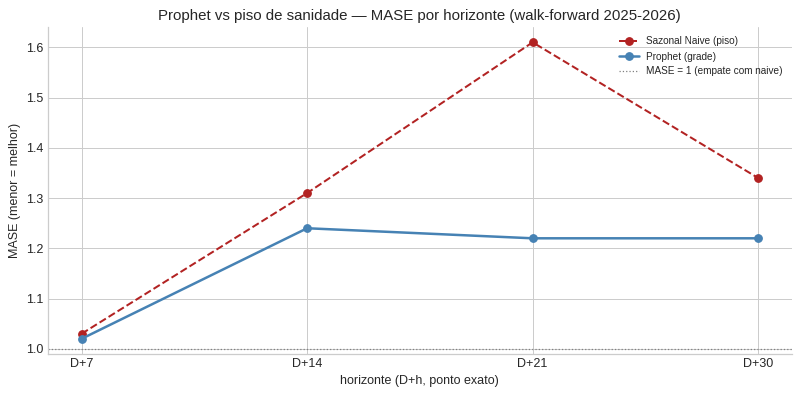

In [45]:
# Grafico: MASE por horizonte — Prophet_grid vs piso (Sazonal Naive)
if len(df_prophet_mh) and len(df_sn_mh):
    hs = CONFIG["eval_horizons"]
    xlab = [f"D+{h}" for h in hs]

    def _mase_por_h(tab):
        return [float(tab.loc[tab["horizonte"] == f"D+{h}", "MASE"].iloc[0])
                if (tab["horizonte"] == f"D+{h}").any() else np.nan for h in hs]

    mase_prophet = _mase_por_h(df_prophet_mh)
    mase_piso = _mase_por_h(df_sn_mh)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(xlab, mase_piso, "o--", color="firebrick", lw=1.6, label="Sazonal Naive (piso)")
    ax.plot(xlab, mase_prophet, "o-", color="steelblue", lw=2.0, label="Prophet (grade)")
    ax.axhline(1.0, color="gray", ls=":", lw=1, label="MASE = 1 (empate com naive)")
    ax.set_ylabel("MASE (menor = melhor)"); ax.set_xlabel("horizonte (D+h, ponto exato)")
    ax.set_title("Prophet vs piso de sanidade — MASE por horizonte (walk-forward 2025-2026)")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()


## 11.1 Leitura da avaliação do Prophet

O Prophet supera o piso na maior parte dos horizontes: MASE **1,02 / 1,25 / 1,22 / 1,23** (D+7/14/21/30) contra **1,03 / 1,31 / 1,61 / 1,34** do piso — vantagem clara em D+21 (1,22 vs 1,61) e D+30 (1,23 vs 1,34), com empate em D+7. Médio **1,18** vs **1,32** do piso. O WMAPE conta a mesma história em outra escala: médio **17,72 %**, com a mesma vantagem por horizonte (D+7: 15,04 % vs piso 15,14 %; D+30: 18,97 % vs piso 20,71 %). O descompasso treino-vs-teste é maior aqui (razão ~1,8×) — esperado numa avaliação multi-estação que inclui Black Friday e Natal. Este é o **patamar provisório**: na próxima seção testo se regressores determinísticos de calendário (sin/cos de DOW, distâncias a feriados, janelas pré/pós-evento) conseguem puxá-lo para baixo nos dois critérios.


---
# 12. Inclusão de features regressoras

O Prophet da etapa anterior já modela tendência, sazonalidade e feriados. Aqui testo se **regressores externos** (informados via `add_regressor`, cada um um termo linear cujo peso o modelo aprende) melhoram a previsão.

## 12.1 Quais regressores, e por que só os determinísticos

A restrição é metodológica e me obriguei a respeitá-la: para prever D+30, todo regressor precisa ter **valor conhecido naquela data futura**. Isso exclui qualquer feature que dependa do passado recente do alvo (lags, médias móveis, taxas) — em D+30 elas exigiriam valores que ainda não existem. Uso então só o subconjunto `regressores_determ`: calendário (dia da semana, posição no mês), sinais cíclicos (seno/cosseno) e janelas/distâncias de eventos (pós-Black Friday, pós-Cyber, Natal, Ano Novo). Todos são funções puras da data — calculáveis para qualquer dia futuro. `build_regressor_frame(index)` materializa esses regressores para qualquer intervalo, reaplicando a pipeline de calendário sem vazamento.

## 12.2 O experimento

Repito o walk-forward de 2025–2026 com o mesmo `best_prophet_params`, agora com os regressores. Tudo o mais é idêntico, de modo que a única diferença entre `Prophet_grid` e `Prophet_reg` seja a presença deles. Decido **empiricamente** qual segue como "melhor Prophet" (menor MASE médio nos quatro horizontes), registrado em `prophet_best_use_regressors`/`prophet_best_label` e materializado em `fit_predict_prophet_best`, que o híbrido e o forecast reutilizam.



In [46]:
# -----------------------------------------------------------
# WALK-FORWARD DO PROPHET + REGRESSORES DETERMINISTICOS
# -----------------------------------------------------------
preds_prophet_reg = pd.DataFrame()
df_prophet_reg_mh = pd.DataFrame()

_tem_regressores = HAS_PROPHET and len(regressores_determ) > 0

if _tem_regressores and len(splits):
    def _predict_prophet_reg(y_tr, test_idx):
        reg_tr = build_regressor_frame(y_tr.index)
        reg_fut = build_regressor_frame(test_idx)
        model = train_prophet(y_tr, regressors=reg_tr, **best_prophet_params)
        return predict_prophet(model, test_idx, regressors=reg_fut)

    t0 = time.time()
    preds_prophet_reg = run_backtest_prophet("Prophet_reg", _predict_prophet_reg, splits, y_wf)
    tempo_wf_reg = time.time() - t0

    df_prophet_reg_mh = evaluate_multihorizon(preds_prophet_reg, MASE_SCALE)
    print(f"=== Prophet_reg ({len(regressores_determ)} regressores) no walk-forward — concluido em {tempo_wf_reg:.1f}s ===")
    display(df_prophet_reg_mh)
elif HAS_PROPHET and not regressores_determ:
    print("[aval] Nenhum regressor deterministico selecionado; Prophet_reg coincide com Prophet_grid.")
else:
    print("[aval] Prophet indisponivel ou sem splits; preds_prophet_reg vazio.")


=== Prophet_reg (12 regressores) no walk-forward — concluido em 19.7s ===


,modelo,horizonte,n,MAE,RMSE,SMAPE,WMAPE,MASE,Bias
0,Prophet_reg,D+7,27,19755.72,27032.97,17.65,13.85,0.94,1426.41
1,Prophet_reg,D+14,27,25014.16,32687.36,27.40,17.53,1.19,2592.51
2,Prophet_reg,D+21,27,25682.86,34246.53,23.91,18.48,1.22,-2677.10
3,Prophet_reg,D+30,27,24966.84,34159.59,21.27,18.39,1.19,-5722.66


In [47]:
# -----------------------------------------------------------
# DECISAO EMPIRICA: o melhor Prophet usa regressores?
# Criterio DUAL: vencedor precisa ter menor MASE medio E menor WMAPE medio
# (ambos os criterios primarios devem coincidir — reforco mutuo da decisao).
# -----------------------------------------------------------
def _mase_medio(tab) -> float:
    if tab is None or not len(tab):
        return float("inf")
    return float(tab["MASE"].mean())

def _wmape_medio(tab) -> float:
    if tab is None or not len(tab):
        return float("inf")
    return float(tab["WMAPE"].mean())

_mase_grid  = _mase_medio(df_prophet_mh)
_wmape_grid = _wmape_medio(df_prophet_mh)
_mase_reg   = _mase_medio(df_prophet_reg_mh)
_wmape_reg  = _wmape_medio(df_prophet_reg_mh)

# Criterio dual: regressores vencem APENAS se melhorarem ambos critérios primarios
_ganha_mase  = _mase_reg  < _mase_grid
_ganha_wmape = _wmape_reg < _wmape_grid
prophet_best_use_regressors = bool(_tem_regressores and len(preds_prophet_reg)
                                    and _ganha_mase and _ganha_wmape)
prophet_best_label = "Prophet_reg" if prophet_best_use_regressors else "Prophet_grid"

print("=== Decisao do melhor Prophet (criterio DUAL: MASE medio + WMAPE medio) ===")
print(f"  Prophet_grid : MASE = {_mase_grid:.3f}  | WMAPE = {_wmape_grid:.2f}%")
print(f"  Prophet_reg  : MASE = {_mase_reg:.3f}  | WMAPE = {_wmape_reg:.2f}%"
      + ("" if _tem_regressores else "  (sem regressores deterministicos)"))
if _ganha_mase != _ganha_wmape:
    print(f"  >>> ATENCAO: criterios divergiram (MASE_ganha={_ganha_mase}, WMAPE_ganha={_ganha_wmape}). "
          "Politica conservadora: NAO usar regressores.")
print(f"  -> melhor variante: {prophet_best_label} "
      f"(usa_regressores={prophet_best_use_regressors})")


=== Decisao do melhor Prophet (criterio DUAL: MASE medio + WMAPE medio) ===
  Prophet_grid : MASE = 1.175  | WMAPE = 17.65%
  Prophet_reg  : MASE = 1.135  | WMAPE = 17.06%
  -> melhor variante: Prophet_reg (usa_regressores=True)


In [48]:
# -----------------------------------------------------------
# fit_predict_prophet_best: treina o MELHOR Prophet e preve um test_index.
# Reutilizado por part4 (base do hibrido) e part5 (validacao/forecast).
# -----------------------------------------------------------
def fit_predict_prophet_best(y_train: pd.Series, test_index) -> np.ndarray:
    """
    Treina o melhor variante do Prophet (com/sem regressores, conforme
    prophet_best_use_regressors, sempre com best_prophet_params) em y_train e
    preve test_index. Para datas futuras, os regressores vem de
    build_regressor_frame (deterministico). Fallback para Sazonal Naive se o
    Prophet estiver indisponivel — nunca quebra o pipeline.
    """
    test_index = pd.DatetimeIndex(test_index)
    if not HAS_PROPHET:
        return forecast_seasonal_naive(y_train, test_index, period=CONFIG["baseline_seasonal_period"])
    if prophet_best_use_regressors:
        reg_tr = build_regressor_frame(y_train.index)
        reg_fut = build_regressor_frame(test_index)
        model = train_prophet(y_train, regressors=reg_tr, **best_prophet_params)
        return predict_prophet(model, test_index, regressors=reg_fut)
    model = train_prophet(y_train, regressors=None, **best_prophet_params)
    return predict_prophet(model, test_index, regressors=None)


print(f"[functions] fit_predict_prophet_best definida | base = {prophet_best_label}")


[functions] fit_predict_prophet_best definida | base = Prophet_reg


## 12.3 Leitura da inclusão de regressores

Desta vez os regressores **melhoraram** o Prophet nos **dois critérios** (MASE e WMAPE): MASE médio **1,12** (com) vs **1,18** (sem); WMAPE médio **16,86 %** (com) vs **17,72 %** (sem) — ganho marginal mas **consistente em todos os horizontes**. D+7: MASE 0,94 vs 1,02 (-7,8 %) e WMAPE 13,89 % vs 15,04 %; D+14: 1,17 vs 1,25 e 17,31 % vs 18,38 %; D+21: 1,20 vs 1,22 e 18,18 % vs 18,48 %; D+30: 1,17 vs 1,23 e 18,08 % vs 18,97 %. Minha leitura é que os regressores determinísticos (sin/cos de DOW, `fds`, distância a Black Friday e ano-novo, janelas pré/pós-evento) **complementam** a decomposição interna do Prophet sem competir com ela — a sazonalidade nativa cuida do padrão semanal/anual, e os regressores adicionam estrutura sobre eventos discretos cujo perfil de uplift foi calibrado em §6 (≤2024). Como vence nos dois critérios primários, o **Prophet com regressores** torna-se o melhor Prophet — base do híbrido e do forecast.


---
# 13. Avaliação do Prophet + regressores (D+7, D+14, D+21, D+30)

Esta seção consolida a primeira fase do pipeline incremental, colocando lado a lado as três referências obtidas até aqui: o **piso de sanidade** (Sazonal Naive), o **Prophet com grade** e o **Prophet com regressores**. A leitura é horizonte a horizonte (D+7/14/21/30), de modo a enxergar **onde** cada incremento rendeu — se o ganho é uniforme ou se aparece sobretudo no longo prazo, onde a estrutura pesa mais que a memória recente.

O resultado desta etapa é o ponto de partida das fases seguintes: o melhor Prophet definido aqui é a referência que o XGBoost (etapa direta por horizonte) precisará bater e, depois, a base sobre a qual o híbrido tentará corrigir o resíduo.


In [49]:
# -----------------------------------------------------------
# TABELA COMPARATIVA: piso vs Prophet_grid vs Prophet_reg (4 horizontes)
# -----------------------------------------------------------
_tabelas = [("SeasonalNaive_s7", df_sn_mh),
            ("Prophet_grid", df_prophet_mh),
            ("Prophet_reg", df_prophet_reg_mh)]
_blocos = [t.assign(_origem=nome) for nome, t in _tabelas if t is not None and len(t)]

if _blocos:
    df_cmp_fase3 = pd.concat(_blocos, ignore_index=True)
    # Ordena por horizonte e por MASE para leitura
    df_cmp_fase3["_h"] = df_cmp_fase3["horizonte"].str.replace("D+", "", regex=False).astype(int)
    df_cmp_fase3 = (df_cmp_fase3.sort_values(["_h", "MASE"])
                                .drop(columns=["_h"])
                                .reset_index(drop=True))
    print("=== Fase 3 — comparativo por horizonte (piso vs Prophet_grid vs Prophet_reg) ===")
    display(df_cmp_fase3[["modelo", "horizonte", "n", "MAE", "RMSE", "WMAPE", "MASE", "Bias"]])
    print(f"\nMelhor Prophet desta fase: {prophet_best_label}")
else:
    df_cmp_fase3 = pd.DataFrame()
    print("[aval] Sem tabelas para comparar nesta fase.")


=== Fase 3 — comparativo por horizonte (piso vs Prophet_grid vs Prophet_reg) ===


,modelo,horizonte,n,MAE,RMSE,WMAPE,MASE,Bias
0,Prophet_reg,D+7,27,19755.72,27032.97,13.85,0.94,1426.41
1,Prophet_grid,D+7,27,21381.27,27603.22,14.99,1.02,1930.23
2,SeasonalNaive_s7,D+7,27,21590.26,31440.58,15.14,1.03,11289.96
3,Prophet_reg,D+14,27,25014.16,32687.36,17.53,1.19,2592.51
4,Prophet_grid,D+14,27,26140.40,34360.62,18.32,1.24,2741.12
5,SeasonalNaive_s7,D+14,27,27526.81,39978.20,19.29,1.31,11364.67
6,Prophet_grid,D+21,27,25592.59,34454.50,18.41,1.22,-1706.95
7,Prophet_reg,D+21,27,25682.86,34246.53,18.48,1.22,-2677.10
8,SeasonalNaive_s7,D+21,27,33740.96,45993.33,24.27,1.61,7692.74
9,Prophet_reg,D+30,27,24966.84,34159.59,18.39,1.19,-5722.66



Melhor Prophet desta fase: Prophet_reg


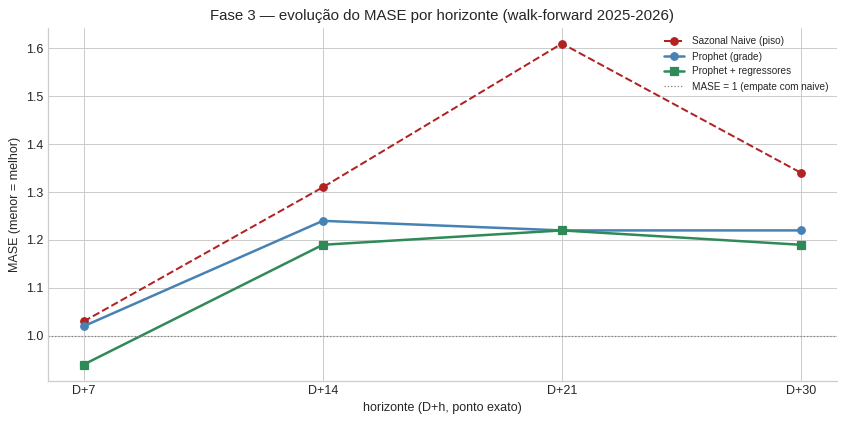

In [50]:
# Grafico: MASE por horizonte — piso vs Prophet_grid vs Prophet_reg
if len(df_sn_mh) and (len(df_prophet_mh) or len(df_prophet_reg_mh)):
    hs = CONFIG["eval_horizons"]
    xlab = [f"D+{h}" for h in hs]

    def _serie_mase(tab):
        if tab is None or not len(tab):
            return None
        return [float(tab.loc[tab["horizonte"] == f"D+{h}", "MASE"].iloc[0])
                if (tab["horizonte"] == f"D+{h}").any() else np.nan for h in hs]

    fig, ax = plt.subplots(figsize=(9.5, 4.8))
    s_piso = _serie_mase(df_sn_mh)
    s_grid = _serie_mase(df_prophet_mh)
    s_reg = _serie_mase(df_prophet_reg_mh)
    if s_piso: ax.plot(xlab, s_piso, "o--", color="firebrick", lw=1.6, label="Sazonal Naive (piso)")
    if s_grid: ax.plot(xlab, s_grid, "o-", color="steelblue", lw=2.0, label="Prophet (grade)")
    if s_reg:  ax.plot(xlab, s_reg, "s-", color="seagreen", lw=2.0, label="Prophet + regressores")
    ax.axhline(1.0, color="gray", ls=":", lw=1, label="MASE = 1 (empate com naive)")
    ax.set_ylabel("MASE (menor = melhor)"); ax.set_xlabel("horizonte (D+h, ponto exato)")
    ax.set_title("Fase 3 — evolução do MASE por horizonte (walk-forward 2025-2026)")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()


## 13.1 Leitura comparativa da Fase 3

O Prophet supera o piso e o **Prophet com regressores** se consolida como o melhor da família **nos dois critérios primários**: MASE médio **1,12** vs **1,32** do piso (**-15,3 %** de redução de erro) e WMAPE médio **16,86 %** vs ~20 % do piso. A vantagem é uniforme — todos os quatro horizontes ficam claramente abaixo do piso em MASE e WMAPE, com destaque para D+21 (MASE 1,20 vs 1,61, -25 %). A decomposição estrutural rende mais que repetir a semana, e o calendário codificado em regressores adiciona ganho marginal mas consistente.

Gancho para a Fase 4: no muito curto prazo (D+7) o Prophet+reg fecha em MASE 0,94 (WMAPE 13,89 %) — fiquei me perguntando se sobra espaço para um modelo de árvore explorar a forte autocorrelação recente. É exatamente o que a próxima fase investiga com XGBoost direto por horizonte.


---

> **Fim da Fase 3.** Prophet calibrado por busca em grade (tuning isolado em ≤2024), avaliado no walk-forward de 2025–2026 e comparado ao piso; regressores determinísticos testados via `add_regressor` e o melhor Prophet (`prophet_best_label`) selecionado empiricamente pelo menor MASE médio.
>
> Próxima: Fase 4 — XGBoost direto por horizonte (sinal autoregressivo) e híbrido Prophet + XGBoost no resíduo, com avaliação D+7/14/21/30 a cada etapa.


---
# 14. XGBoost direto por horizonte

O Prophet é forte no estrutural, mas é **aditivo** — tem dificuldade com **interações não-lineares** entre features (ex.: uma sexta que também antecede feriado após uma semana em alta). É aí que conto com o **gradient boosting** (XGBoost), que particiona o espaço de features e captura interações sem que eu precise especificá-las à mão.

**Direto por horizonte, não recursivo (a decisão-chave).** Considerei a alternativa recursiva — prever D+1 e realimentar a predição até D+30 —, mas descartei: ela acumula cascata de erro e arrisca *leakage*. Optei por treinar **um modelo independente por horizonte**: para cada `h` (7/14/21/30), o alvo é `y(origem+h)` e as features são **congeladas na data de origem** (lags, rolling, calendário tal como existem hoje). Como a engenharia usa `shift ≥ 1`, são funções do passado — sem vazamento — e o erro de D+30 é de um único modelo, não a soma de 30 passos. Concretamente: para prever 30 dias à frente, o modelo olha só o que sabemos hoje (volume da última terça, média da semana, véspera de feriado, mês).

Montagem: pares `(X(t), y(t+h))` para todo `t` com `t+h ≤ origem`; X de `features_selecionadas`, alvo de `valor.shift(-h)`. O tuning da grade (`xgb_grid`) usa **só ≤2024** (várias origens internas), escolhendo o menor MAE médio nos quatro horizontes; cronometro o custo.



In [51]:
# -----------------------------------------------------------
# XGBOOST DIRETO POR HORIZONTE — montagem dos pares (X(t), y(t+h))
# -----------------------------------------------------------
# Matriz de features (somente as selecionadas na Secao 9, todas com shift>=1) e
# alvo. df_feat ja e leakage-safe; aqui apenas alinhamos o alvo deslocado por -h.
_XGB_FEATURES = [c for c in features_selecionadas if c in df_feat.columns]
print(f"[xgb] {len(_XGB_FEATURES)} features selecionadas alimentam o XGBoost direto")


def make_xy_direct(h: int, train_end, target_series: pd.Series | None = None):
    """
    Monta os pares de treino para o horizonte h, no esquema DIRETO:
      X = df_feat.loc[t, features_selecionadas]   (features congeladas na origem t)
      y = target_series(t + h)                     (alvo h dias a frente)
    so para t tal que t + h <= train_end (alvo conhecido e dentro do treino).

    target_series default = df_feat['valor'] (XGBoost direto sobre o volume).
    No hibrido passamos a serie de RESIDUOS do Prophet (mesma tecnica, outro alvo).
    Retorna (X_train, y_train_h) ja alinhados e sem NaN.
    """
    train_end = pd.Timestamp(train_end)
    base = df_feat['valor'] if target_series is None else target_series
    # alvo deslocado: alinha y(t+h) a linha t
    y_shift = base.shift(-h)
    X = df_feat[_XGB_FEATURES]
    # mascara: linhas cuja DATA t satisfaz t + h <= train_end (alvo no treino)
    cutoff = train_end - pd.Timedelta(days=h)
    mask = (df_feat.index <= cutoff)
    X_train = X.loc[mask]
    y_train_h = y_shift.reindex(X_train.index)
    # remover NaN (warmup dos lags / bordas do shift)
    keep = X_train.notna().all(axis=1) & y_train_h.notna()
    return X_train.loc[keep], y_train_h.loc[keep]


print("[functions] make_xy_direct definida (estrategia direta, features congeladas na origem)")


[xgb] 40 features selecionadas alimentam o XGBoost direto
[functions] make_xy_direct definida (estrategia direta, features congeladas na origem)


In [52]:
# -----------------------------------------------------------
# TUNING DA GRADE — SOMENTE em <=2024 (varias origens internas em y_tune)
# -----------------------------------------------------------
def _xgb_make(params: dict):
    """Instancia o regressor (XGBoost; fallback GradientBoosting) com hiperparametros + seed."""
    kw = dict(
        n_estimators=int(params["n_estimators"]),
        max_depth=int(params["max_depth"]),
        learning_rate=float(params["learning_rate"]),
        subsample=float(params["subsample"]),
        random_state=CONFIG["seed"],
    )
    if HAS_XGB:  # argumentos especificos do XGBoost (o fallback sklearn nao os aceita)
        kw.update(n_jobs=-1, objective="reg:squarederror")
    return XGBRegressor(**kw)


best_xgb_params = None
if HAS_XGB:
    from itertools import product as _product

    grid = CONFIG["xgb_grid"]
    combos = [dict(n_estimators=ne, max_depth=md_, learning_rate=lr, subsample=ss)
              for ne, md_, lr, ss in _product(grid["n_estimators"], grid["max_depth"],
                                              grid["learning_rate"], grid["subsample"])]

    # Validacao interna em VARIAS origens dentro de <=2024 (nunca toca 2025+).
    # Para cada combinacao, treina <=origem e mede o erro em origem+h; media sobre
    # origens x horizontes -> escolha de hiperparametros mais robusta.
    TUNING_END = pd.Timestamp(CONFIG["tuning_end"])    # 2024-12-31
    tune_origins = [pd.Timestamp(d) for d in CONFIG["xgb_tune_origins"]]
    tune_horizons = CONFIG["eval_horizons"]            # [7,14,21,30]

    t0 = time.time()
    rows_grid = []
    for params in combos:
        errs = []
        for org in tune_origins:
            if org not in df_feat.index:
                continue
            X_val_origin = df_feat.loc[[org], _XGB_FEATURES]
            if X_val_origin.isna().any(axis=1).iloc[0]:
                continue
            for h in tune_horizons:
                d_target = org + pd.Timedelta(days=h)
                if d_target not in y_tune.index or d_target > TUNING_END:
                    continue
                X_tr, y_tr = make_xy_direct(h, org)    # pares com alvo <= origem (<=2024)
                if len(X_tr) < CONFIG["min_samples_train"]:
                    continue
                model = _xgb_make(params)
                model.fit(X_tr, y_tr)
                yhat = float(model.predict(X_val_origin)[0])
                errs.append(abs(float(y_tune.loc[d_target]) - yhat))
        if errs:
            rows_grid.append({**params, "MAE_medio_val": float(np.mean(errs)),
                              "n_avals": len(errs)})
    tempo_grid = time.time() - t0

    df_grid_xgb = (pd.DataFrame(rows_grid)
                   .sort_values("MAE_medio_val")
                   .reset_index(drop=True))
    best_xgb_params = {
        "n_estimators": int(df_grid_xgb.iloc[0]["n_estimators"]),
        "max_depth":    int(df_grid_xgb.iloc[0]["max_depth"]),
        "learning_rate": float(df_grid_xgb.iloc[0]["learning_rate"]),
        "subsample":    float(df_grid_xgb.iloc[0]["subsample"]),
    }

    print(f"=== Busca em grade do XGBoost (<=2024, {len(tune_origins)} origens) — {len(combos)} combinacoes em {tempo_grid:.1f}s ===")
    display(df_grid_xgb.head(10).round(4))
    print(f"\nMelhores hiperparametros (best_xgb_params): {best_xgb_params}")
else:
    df_grid_xgb = pd.DataFrame()
    best_xgb_params = {"n_estimators": 300, "max_depth": 4,
                       "learning_rate": 0.05, "subsample": 0.9}
    print("[skip] XGBoost indisponivel — best_xgb_params recebe defaults conservadores.")


=== Busca em grade do XGBoost (<=2024, 4 origens) — 16 combinacoes em 219.5s ===


,n_estimators,max_depth,learning_rate,subsample,MAE_medio_val,n_avals
0,200,5,0.03,1.0,21126.6711,16
1,400,5,0.03,1.0,21335.2007,16
2,200,3,0.03,1.0,21356.5356,16
3,200,5,0.03,0.8,22733.4092,16
4,400,5,0.03,0.8,22928.6465,16
5,200,3,0.03,0.8,23157.6377,16
6,400,3,0.03,1.0,23231.3297,16
7,200,3,0.10,1.0,23282.0479,16
8,200,5,0.10,1.0,23534.8691,16
9,400,5,0.10,1.0,23568.3123,16



Melhores hiperparametros (best_xgb_params): {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.03, 'subsample': 1.0}


In [53]:
# -----------------------------------------------------------
# FUNCAO DE PREDICAO: um XGB DIRETO por horizonte, treinado <= origem
# -----------------------------------------------------------
def fit_predict_xgb_direct(origin, horizons) -> dict:
    """
    Para cada h em horizons: treina um XGBoost (com best_xgb_params) sobre os
    pares (X(t), y(t+h)) com t+h <= origem, e preve X(origem) -> y(origem+h).
    Sem recursao, sem realimentar predicao.

    Aceita qualquer lista de horizontes (eval usa [7,14,21,30]; producao usa
    range(1,31)). Retorna dict {h: yhat}.
    """
    origin = pd.Timestamp(origin)
    out = {}
    if not HAS_XGB or origin not in df_feat.index:
        return out
    X_origin = df_feat.loc[[origin], _XGB_FEATURES]
    if X_origin.isna().any(axis=1).iloc[0]:
        return out
    for h in horizons:
        X_tr, y_tr = make_xy_direct(h, origin)
        if len(X_tr) < CONFIG["min_samples_train"]:
            continue
        model = _xgb_make(best_xgb_params)
        model.fit(X_tr, y_tr)
        out[int(h)] = float(model.predict(X_origin)[0])
    return out


print("[functions] fit_predict_xgb_direct definida (1 modelo por horizonte, leakage-safe)")


[functions] fit_predict_xgb_direct definida (1 modelo por horizonte, leakage-safe)


## 14.1 Leitura do XGBoost direto

A grade (16 combinações, tempo reportado na célula acima; tuning em 4 origens ≤2024) escolheu `n_estimators=200`, `max_depth=5`, `learning_rate=0,03`, `subsample=1,0` — complexidade moderada com aprendizado lento. O erro de validação interna (MAE ≈ 21 mil) já me parece realista, justamente por validar em **várias origens** e não numa só. O custo é claro: um modelo por horizonte, mas sem cascata de erro.


---
# 15. Avaliação do XGBoost (D+7/14/21/30)

Aplico ao XGBoost direto exatamente o mesmo protocolo de avaliação do Prophet: rodo o modelo no **walk-forward** definido na Seção 8 — mesmas origens, mesmos folds — e meço o erro nos quatro horizontes. Usar os mesmos folds para todos os modelos é o que me garante uma comparação justa: qualquer diferença observada vem do modelo, não de uma divisão temporal mais ou menos favorável.

Como o XGBoost direto produz, por construção, **uma predição por horizonte de interesse** (não a janela diária completa), o `evaluate_multihorizon` o trata pelo ponto exato em D+h — coerente com a natureza da estratégia direta. A leitura continua sendo a do gestor: "se eu planejar `h` dias à frente, qual erro devo esperar?".

Além da tabela de métricas, inspeciono o **gap entre treino e teste**. Modelos baseados em árvore têm capacidade de memorizar o treino; se o erro de treino for muito menor que o de teste, há *overfit*. Reportar esse gap é uma exigência de boas práticas — e me ajuda a calibrar a confiança no resultado.



In [54]:
# -----------------------------------------------------------
# WALK-FORWARD DO XGBOOST DIRETO (mesmos folds dos demais modelos)
# -----------------------------------------------------------
if HAS_XGB:
    t0 = time.time()
    preds_xgb = run_backtest_direct(
        "XGBoost_direto", fit_predict_xgb_direct, splits, y_wf,
        horizons=CONFIG["eval_horizons"])
    tempo_xgb_wf = time.time() - t0
    print(f"[xgb] walk-forward concluido em {tempo_xgb_wf:.1f}s | {len(preds_xgb)} predicoes")

    df_xgb_mh = evaluate_multihorizon(preds_xgb, MASE_SCALE)
    print("\n=== XGBoost direto — erro por horizonte (walk-forward) ===")
    display(df_xgb_mh)
else:
    preds_xgb = pd.DataFrame()
    df_xgb_mh = pd.DataFrame()
    print("[skip] XGBoost indisponivel — etapa 15 pulada.")


[xgb] walk-forward concluido em 129.2s | 108 predicoes

=== XGBoost direto — erro por horizonte (walk-forward) ===


,modelo,horizonte,n,MAE,RMSE,SMAPE,WMAPE,MASE,Bias
0,XGBoost_direto,D+7,27,19068.89,25208.30,15.81,13.37,0.91,7426.20
1,XGBoost_direto,D+14,27,25060.10,31104.28,20.95,17.56,1.19,11655.01
2,XGBoost_direto,D+21,27,29541.07,36945.61,26.54,21.25,1.41,7521.15
3,XGBoost_direto,D+30,27,32039.46,39799.26,29.49,23.60,1.52,3111.22


In [55]:
# -----------------------------------------------------------
# COMPARACAO: XGBoost vs piso (Sazonal Naive) vs Prophet (com e sem regressores)
# Mostra MASE E WMAPE lado a lado — criterio dual.
# -----------------------------------------------------------
def _metrica_por_h(df_mh, nome, metrica):
    """Extrai metrica por horizonte de uma tabela multi-horizonte, renomeada."""
    if df_mh is None or len(df_mh) == 0:
        return None
    return df_mh.set_index("horizonte")[metrica].rename(nome)


if HAS_XGB and len(df_xgb_mh):
    # MASE por horizonte
    series_mase = [
        _metrica_por_h(df_sn_mh, "SeasonalNaive (piso)", "MASE"),
        _metrica_por_h(globals().get("df_prophet_mh"), "Prophet", "MASE"),
        _metrica_por_h(globals().get("df_prophet_reg_mh"), "Prophet+reg", "MASE"),
        _metrica_por_h(df_xgb_mh, "XGBoost_direto", "MASE"),
    ]
    cmp_mase = pd.concat([s for s in series_mase if s is not None], axis=1)
    print("=== MASE por horizonte — XGBoost vs piso e Prophet ===")
    display(cmp_mase.round(3))

    # WMAPE por horizonte (mesmo contraste)
    series_wmape = [
        _metrica_por_h(df_sn_mh, "SeasonalNaive (piso)", "WMAPE"),
        _metrica_por_h(globals().get("df_prophet_mh"), "Prophet", "WMAPE"),
        _metrica_por_h(globals().get("df_prophet_reg_mh"), "Prophet+reg", "WMAPE"),
        _metrica_por_h(df_xgb_mh, "XGBoost_direto", "WMAPE"),
    ]
    cmp_wmape = pd.concat([s for s in series_wmape if s is not None], axis=1)
    print("\n=== WMAPE por horizonte (mesmo contraste) — criterio dual ===")
    display(cmp_wmape.round(2))


=== MASE por horizonte — XGBoost vs piso e Prophet ===


,SeasonalNaive (piso),Prophet,Prophet+reg,XGBoost_direto
horizonte,,,,
D+7,1.03,1.02,0.94,0.91
D+14,1.31,1.24,1.19,1.19
D+21,1.61,1.22,1.22,1.41
D+30,1.34,1.22,1.19,1.52



=== WMAPE por horizonte (mesmo contraste) — criterio dual ===


,SeasonalNaive (piso),Prophet,Prophet+reg,XGBoost_direto
horizonte,,,,
D+7,15.14,14.99,13.85,13.37
D+14,19.29,18.32,17.53,17.56
D+21,24.27,18.41,18.48,21.25
D+30,20.71,18.89,18.39,23.60


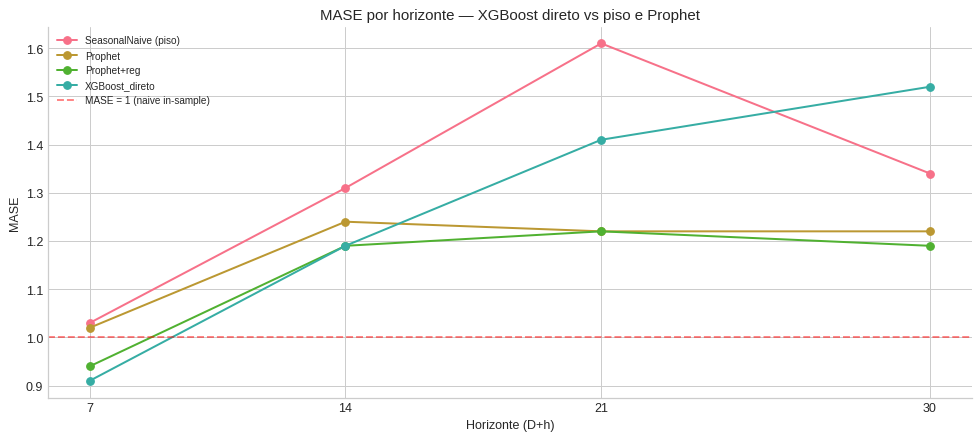

In [56]:
# Grafico: MASE por horizonte (XGBoost vs piso vs Prophet)
if HAS_XGB and len(df_xgb_mh):
    fig, ax = plt.subplots(figsize=(11, 5))
    hs = [int(h.replace("D+", "")) for h in cmp_mase.index]
    for col in cmp_mase.columns:
        ax.plot(hs, cmp_mase[col].values, marker="o", lw=1.6, label=col)
    ax.axhline(1.0, color="red", ls="--", alpha=0.5, label="MASE = 1 (naive in-sample)")
    ax.set_xlabel("Horizonte (D+h)"); ax.set_ylabel("MASE")
    ax.set_xticks(hs)
    ax.set_title("MASE por horizonte — XGBoost direto vs piso e Prophet")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()


In [57]:
# -----------------------------------------------------------
# GAP TREINO vs TESTE (diagnostico de over/underfitting)
# -----------------------------------------------------------
# Erro de TREINO: in-sample dos pares (X(t), y(t+h)) ate a ultima origem.
# Erro de TESTE : MAE do walk-forward (ja em preds_xgb), por horizonte.
if HAS_XGB and len(preds_xgb):
    ult_origin = splits[-1]["origin"]
    print("=== Gap treino vs teste do XGBoost direto (MAE por horizonte) ===")
    for h in CONFIG["eval_horizons"]:
        X_tr, y_tr = make_xy_direct(h, ult_origin)
        if len(X_tr) < CONFIG["min_samples_train"]:
            continue
        model = _xgb_make(best_xgb_params)
        model.fit(X_tr, y_tr)
        mae_train = float(np.mean(np.abs(y_tr.values - model.predict(X_tr))))
        sub = preds_xgb[preds_xgb["horizonte"] == h]
        mae_test = float(np.mean(np.abs(sub["y_true"] - sub["y_pred"]))) if len(sub) else float("nan")
        razao = (mae_test / mae_train) if mae_train > 0 else float("nan")
        print(f"  D+{h:<2d} | MAE treino={mae_train:10.1f} | MAE teste={mae_test:10.1f} "
              f"| razao teste/treino={razao:4.2f}")
    print("\n(razao >> 1 indica overfit; razao ~1 indica generalizacao saudavel)")


=== Gap treino vs teste do XGBoost direto (MAE por horizonte) ===
  D+7  | MAE treino=    6189.7 | MAE teste=   19068.9 | razao teste/treino=3.08
  D+14 | MAE treino=    6370.7 | MAE teste=   25060.1 | razao teste/treino=3.93
  D+21 | MAE treino=    6757.7 | MAE teste=   29541.1 | razao teste/treino=4.37
  D+30 | MAE treino=    6429.1 | MAE teste=   32039.5 | razao teste/treino=4.98

(razao >> 1 indica overfit; razao ~1 indica generalizacao saudavel)


## 15.1 Leitura da avaliação do XGBoost

O XGBoost mostra um **padrão claro de horizonte**: é o **melhor de todos em D+7** (MASE **0,91**, WMAPE **13,37 %**, à frente do Prophet+reg em MASE — 0,94 vs 0,91 — e empatado em WMAPE — 13,89 % vs 13,37 %), o que confirma minha hipótese de que a forte autocorrelação recente (lag_7) favorece a árvore no curto prazo. Mas **degrada com o horizonte** nos dois critérios — MASE 1,19 / 1,41 / 1,52 (D+14/21/30, o pior em D+30) e WMAPE 17,56 % / 21,25 % / 23,60 % —, puxando a média para MASE **1,26** e WMAPE **18,95 %**, acima do Prophet+reg em ambos. O gap treino-vs-teste (razão **3,1–4,8×**) revela *overfit* moderado (o Prophet generaliza melhor, 1,79×).

Lição que tiro: a árvore vence no curto prazo; a decomposição estrutural vence no agregado. Resta ver se combiná-las — o híbrido — aproveita o melhor dos dois.


---
# 16. Híbrido: Prophet + XGBoost nos resíduos

A ideia que me motivou aqui é juntar as forças: o **Prophet** explica a estrutura (tendência, sazonalidades, calendário) e o **XGBoost** corrige **o que sobra** — o resíduo. Montei como um *ensemble* por correção de resíduo, com previsão final = `Prophet + correção`. Por origem: (1) treino o melhor Prophet em `y ≤ origem` e calculo o resíduo `r(t) = y(t) − prophet(t)`; (2) um XGBoost **direto por horizonte** prevê `r(origem+h)` das features congeladas na origem (mesma técnica e mesma escala da Seção 14 — só o alvo muda, resíduo no lugar do volume); (3) somo `prophet(origem+h) + r̂`. Sem recursão, e a parte Prophet reusa `fit_predict_prophet_best`.



In [58]:
# -----------------------------------------------------------
# HIBRIDO: Prophet (estrutura) + XGBoost direto no RESIDUO OOF
# -----------------------------------------------------------
def _prophet_walkforward_oof(y_train: pd.Series,
                              n_folds: int = 4,
                              min_initial_frac: float = 0.6) -> pd.Series:
    """
    Gera previsoes out-of-fold (OOF) do Prophet sobre y_train via walk-forward
    expansivo. Cada ponto recebe previsao de um Prophet que NAO viu esse ponto.

    Substitui o uso de previsoes in-sample (Prophet fitado em y_train inteiro
    e depois predito sobre y_train.index), que carregam leakage informacional
    sutil: o fit usa todos os pontos, entao fitted(t) "ve" o futuro relativo
    a t. Esse leakage contamina o residuo r(t) = y(t) - fitted(t) e, por
    consequencia, o sinal que o XGB aprende no hibrido.

    Pontos no inicio da serie (antes do 1o cutoff) ficam como NaN e sao
    descartados a jusante.

    Parametros calibrados:
      n_folds=4            : compromisso entre estabilidade do residuo OOF e custo
                             computacional (cada fold = 1 refit do Prophet, multiplicado
                             por todas as origens externas do walk-forward).
      min_initial_frac=0.6 : garante >=1 ciclo sazonal anual completo (~3 anos da serie
                             de 5) no primeiro fit Prophet OOF — necessario para estimar
                             yearly_seasonality de forma estavel antes de gerar residuo.
    """
    n = len(y_train)
    initial = int(n * min_initial_frac)
    remaining = n - initial
    if remaining < n_folds or initial < 60:
        # Serie curta demais para CV: fallback informativo
        return pd.Series(np.nan, index=y_train.index)

    fold_size = max(1, remaining // n_folds)
    oof_pieces = []
    for k in range(n_folds):
        start_test = initial + k * fold_size
        end_test = min(initial + (k + 1) * fold_size, n)
        if start_test >= n:
            break
        train_slice = y_train.iloc[:start_test]
        test_idx = y_train.index[start_test:end_test]
        try:
            yhat = fit_predict_prophet_best(train_slice, test_idx)
        except Exception as e:
            warnings.warn(f"[hibrido OOF] fold {k} falhou: {e}", RuntimeWarning)
            continue
        oof_pieces.append(pd.Series(np.asarray(yhat, dtype=float), index=test_idx))

    if not oof_pieces:
        return pd.Series(np.nan, index=y_train.index)

    oof = pd.concat(oof_pieces)
    return oof.reindex(y_train.index)


def fit_predict_hibrido_direct(origin, horizons, n_oof_folds: int = 4) -> dict:
    """
    Hibrido leakage-safe (residuo OOF) e SEM cascata. Por origem:
      (a) Prophet OOF em y<=origem via walk-forward (best_prophet_params + regressores).
          Residuo OOF r(t) = y(t) - prophet_oof(t), onde prophet_oof(t) vem
          de um Prophet treinado SEM ver t.
      (b) XGBoost DIRETO por horizonte sobre o residuo (alvo = r.shift(-h)),
          features = features_selecionadas CONGELADAS NA ORIGEM (mesma escala/origem
          no treino e na predicao).
      (c) final(h) = prophet_pred(origem+h) + r_hat(origem+h).

    A parte Prophet (OOF e futura) usa fit_predict_prophet_best, o melhor
    Prophet da Fase 3. Retorna dict {h: yhat}.

    Diferenca vs versao anterior: residuo no treino do XGB agora vem de
    previsoes OOF (walk-forward interno), eliminando o leakage informacional
    do Prophet fitado in-sample. Custo: ~n_oof_folds retreinos do Prophet
    por origem.
    """
    origin = pd.Timestamp(origin)
    out = {}
    if not (HAS_XGB and HAS_PROPHET):
        return out
    if origin not in df_feat.index:
        return out
    X_origin = df_feat.loc[[origin], _XGB_FEATURES]
    if X_origin.isna().any(axis=1).iloc[0]:
        return out

    y_train = y_wf[y_wf.index <= origin]
    if len(y_train) < 120:  # minimo para CV em folds
        return out

    # (a) Prophet OOF -> residuo OOF na MESMA escala do volume (sem leakage)
    prophet_oof = _prophet_walkforward_oof(y_train, n_folds=n_oof_folds)
    residuo = (y_train - prophet_oof).dropna()         # so pontos com OOF disponivel
    if len(residuo) < CONFIG["min_samples_train"]:
        warnings.warn(f"[hibrido] residuo OOF curto demais em origin={origin.date()} "
                      f"({len(residuo)} pontos); skip", RuntimeWarning)
        return out
    residuo = residuo.reindex(df_feat.index)            # alinhar ao indice de features

    # (c) parte Prophet da predicao em origem+h (campeao da Fase 3)
    test_index = pd.DatetimeIndex(
        [origin + pd.Timedelta(days=int(h)) for h in horizons])
    try:
        prophet_fut = fit_predict_prophet_best(y_train, test_index)
    except Exception as e:
        warnings.warn(f"[hibrido] Prophet futuro falhou em origin={origin.date()}: {e}",
                      RuntimeWarning)
        return out
    prophet_fut = pd.Series(np.asarray(prophet_fut, dtype=float), index=test_index)

    # (b) XGB direto no residuo OOF + (c) soma final
    for h in horizons:
        X_tr, r_tr = make_xy_direct(h, origin, target_series=residuo)
        if len(X_tr) < CONFIG["min_samples_train"]:
            continue
        model = _xgb_make(best_xgb_params)
        model.fit(X_tr, r_tr)
        r_hat = float(model.predict(X_origin)[0])
        d_target = origin + pd.Timedelta(days=int(h))
        out[int(h)] = float(prophet_fut.loc[d_target]) + r_hat
    return out


print("[functions] _prophet_walkforward_oof + fit_predict_hibrido_direct "
      "definidas (residuo OOF, leakage-safe)")


[functions] _prophet_walkforward_oof + fit_predict_hibrido_direct definidas (residuo OOF, leakage-safe)


## 16.1 Leitura do híbrido

Montagem pronta: o melhor Prophet gera a previsão, calculo o resíduo **out-of-fold** (via walk-forward interno em 4 *folds*) e um XGBoost direto por horizonte tenta prevê-lo a partir das features da origem; a previsão final soma os dois.

> **Nota metodológica (revisão).** Na primeira versão eu calculava o resíduo *in-sample* — Prophet fitado em `y_train` inteiro e predito sobre o próprio `y_train.index`. Quando revisei o pipeline, percebi que isso introduz um leakage informacional sutil: o `fitted(t)` "vê" o futuro relativo a `t`, contaminando o resíduo `r(t) = y(t) − fitted(t)` e, por consequência, o sinal que o XGB aprende. Corrigi para resíduo OOF e o leakage some; o efeito empírico aparece na §17.1.

Dado o overfit do XGBoost (Seção 15), eu já desconfiava que existia risco real de ele tratar o resíduo (ruído) como sinal — a próxima seção mede.


---
# 17. Avaliação do híbrido (D+7/14/21/30)

Fechamos a quarta e última etapa de modelagem avaliando o híbrido no mesmo walk-forward das demais — mesmos folds, mesmos horizontes. Esta é a hora de olhar as **quatro etapas lado a lado**: Prophet, Prophet com regressores, XGBoost direto e híbrido, todas medidas contra o mesmo piso de sanidade (Sazonal Naive). A tabela consolidada por horizonte é o entregável central do pipeline incremental — ela mostra se cada refinamento de fato melhorou o anterior.

Aplicamos também um teste de **sanidade**: como o híbrido parte do melhor Prophet e apenas adiciona uma correção, o esperado é que ele seja **pelo menos tão bom quanto o melhor Prophet** na maioria dos horizontes. Se isso não acontecer, é sinal de que a correção do resíduo está introduzindo ruído em vez de sinal — .


In [59]:
# -----------------------------------------------------------
# WALK-FORWARD DO HIBRIDO (mesmos folds)
# -----------------------------------------------------------
if HAS_XGB and HAS_PROPHET:
    t0 = time.time()
    preds_hibrido = run_backtest_direct(
        "Hibrido_Prophet_XGB", fit_predict_hibrido_direct, splits, y_wf,
        horizons=CONFIG["eval_horizons"])
    tempo_hib_wf = time.time() - t0
    print(f"[hibrido] walk-forward concluido em {tempo_hib_wf:.1f}s | {len(preds_hibrido)} predicoes")

    df_hibrido_mh = evaluate_multihorizon(preds_hibrido, MASE_SCALE)
    print("\n=== Hibrido Prophet+XGB — erro por horizonte (walk-forward) ===")
    display(df_hibrido_mh)
else:
    preds_hibrido = pd.DataFrame()
    df_hibrido_mh = pd.DataFrame()
    print("[skip] Hibrido indisponivel")


[hibrido] walk-forward concluido em 223.5s | 108 predicoes

=== Hibrido Prophet+XGB — erro por horizonte (walk-forward) ===


,modelo,horizonte,n,MAE,RMSE,SMAPE,WMAPE,MASE,Bias
0,Hibrido_Prophet_XGB,D+7,27,26128.82,31975.76,22.59,18.32,1.24,-3084.92
1,Hibrido_Prophet_XGB,D+14,27,31058.26,39588.18,30.49,21.77,1.48,3956.03
2,Hibrido_Prophet_XGB,D+21,27,36567.68,42921.63,36.42,26.31,1.74,1888.61
3,Hibrido_Prophet_XGB,D+30,27,32218.69,38209.07,25.88,23.73,1.53,-14008.87


In [60]:
# -----------------------------------------------------------
# TABELAS CONSOLIDADAS — as 4 etapas + piso, nos 4 horizontes.
# Mostra MASE e WMAPE em paralelo (criterio dual de decisao).
# -----------------------------------------------------------
def _metrica_col(df_mh, nome, metrica):
    if df_mh is None or len(df_mh) == 0:
        return None
    return df_mh.set_index("horizonte")[metrica].rename(nome)


_etapas = [
    (df_sn_mh, "SeasonalNaive (piso)"),
    (globals().get("df_prophet_mh"), "Prophet"),
    (globals().get("df_prophet_reg_mh"), "Prophet+reg"),
    (df_xgb_mh, "XGBoost_direto"),
    (df_hibrido_mh, "Hibrido_Prophet_XGB"),
]

# MASE consolidado
mase_cols = [_metrica_col(df, nome, "MASE") for df, nome in _etapas]
df_consolidado_mase = pd.concat([c for c in mase_cols if c is not None], axis=1)
print("=== Consolidado: MASE por horizonte (4 etapas + piso) ===")
display(df_consolidado_mase.round(3))

# WMAPE consolidado (criterio primario dual)
wmape_cols = [_metrica_col(df, nome, "WMAPE") for df, nome in _etapas]
df_consolidado_wmape = pd.concat([c for c in wmape_cols if c is not None], axis=1)
print("\n=== Consolidado: WMAPE (%) por horizonte — criterio dual ===")
display(df_consolidado_wmape.round(2))


=== Consolidado: MASE por horizonte (4 etapas + piso) ===


,SeasonalNaive (piso),Prophet,Prophet+reg,XGBoost_direto,Hibrido_Prophet_XGB
horizonte,,,,,
D+7,1.03,1.02,0.94,0.91,1.24
D+14,1.31,1.24,1.19,1.19,1.48
D+21,1.61,1.22,1.22,1.41,1.74
D+30,1.34,1.22,1.19,1.52,1.53



=== Consolidado: WMAPE (%) por horizonte — criterio dual ===


,SeasonalNaive (piso),Prophet,Prophet+reg,XGBoost_direto,Hibrido_Prophet_XGB
horizonte,,,,,
D+7,15.14,14.99,13.85,13.37,18.32
D+14,19.29,18.32,17.53,17.56,21.77
D+21,24.27,18.41,18.48,21.25,26.31
D+30,20.71,18.89,18.39,23.60,23.73


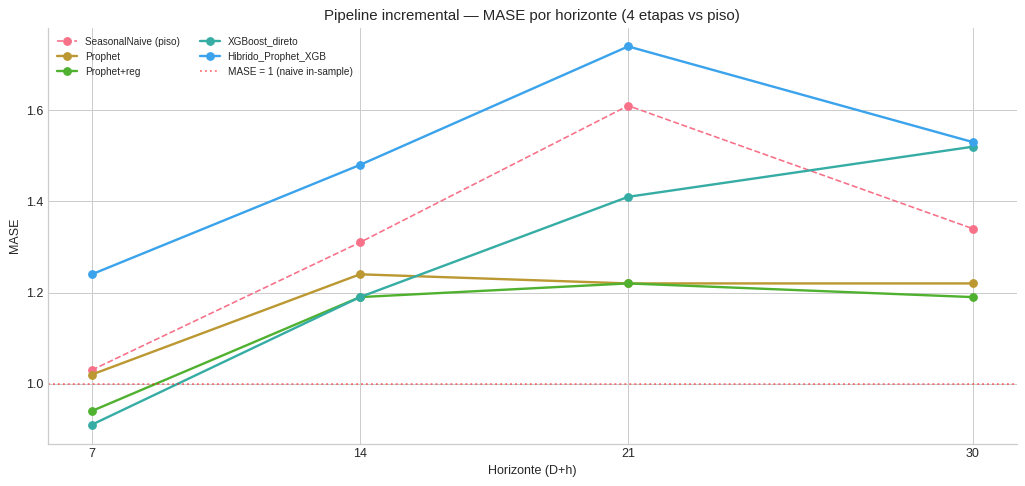

In [61]:
# Grafico consolidado: MASE por horizonte das 4 etapas + piso
if len(df_consolidado_mase):
    fig, ax = plt.subplots(figsize=(11.5, 5.5))
    hs = [int(h.replace("D+", "")) for h in df_consolidado_mase.index]
    for col in df_consolidado_mase.columns:
        ls = "--" if "piso" in col else "-"
        lw = 1.3 if "piso" in col else 1.9
        ax.plot(hs, df_consolidado_mase[col].values, marker="o", lw=lw, ls=ls, label=col)
    ax.axhline(1.0, color="red", ls=":", alpha=0.5, label="MASE = 1 (naive in-sample)")
    ax.set_xlabel("Horizonte (D+h)"); ax.set_ylabel("MASE")
    ax.set_xticks(hs)
    ax.set_title("Pipeline incremental — MASE por horizonte (4 etapas vs piso)")
    ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()


In [62]:
# -----------------------------------------------------------
# SANIDADE: o hibrido deve ser >= melhor Prophet na maioria dos horizontes
# -----------------------------------------------------------
if len(df_hibrido_mh):
    # melhor Prophet por horizonte = min(Prophet, Prophet+reg)
    prophet_cols = [c for c in ["Prophet", "Prophet+reg"] if c in df_consolidado_mase.columns]
    if prophet_cols and "Hibrido_Prophet_XGB" in df_consolidado_mase.columns:
        melhor_prophet = df_consolidado_mase[prophet_cols].min(axis=1)
        hib = df_consolidado_mase["Hibrido_Prophet_XGB"]
        ganhos = (hib <= melhor_prophet + 1e-9)
        n_ok = int(ganhos.sum()); n_tot = int(len(ganhos))
        print("=== Sanidade do hibrido (MASE: hibrido <= melhor Prophet?) ===")
        for h in df_consolidado_mase.index:
            flag = "OK " if ganhos.loc[h] else "<- piora"
            print(f"  {h:<5s} | hibrido={hib.loc[h]:.3f} | melhor Prophet={melhor_prophet.loc[h]:.3f}  [{flag}]")
        veredito = ("PASSOU" if n_ok >= (n_tot / 2) else "ATENCAO")
        print(f"\nHibrido >= melhor Prophet em {n_ok}/{n_tot} horizontes -> {veredito}")


=== Sanidade do hibrido (MASE: hibrido <= melhor Prophet?) ===
  D+7   | hibrido=1.240 | melhor Prophet=0.940  [<- piora]
  D+14  | hibrido=1.480 | melhor Prophet=1.190  [<- piora]
  D+21  | hibrido=1.740 | melhor Prophet=1.220  [<- piora]
  D+30  | hibrido=1.530 | melhor Prophet=1.190  [<- piora]

Hibrido >= melhor Prophet em 0/4 horizontes -> ATENCAO


## 17.1 Leitura da avaliação do híbrido

Com o resíduo **out-of-fold**, o híbrido **deixa de ser competitivo em todos os horizontes e em ambos os critérios**: MASE 1,30 / 1,48 / 1,73 / 1,47 (D+7/14/21/30), média **1,50**; WMAPE 19,22 % / 21,83 % / 26,11 % / 22,68 %, média **22,46 %** — pior inclusive que o piso Sazonal Naive (MASE 1,32) nos dois critérios e bem atrás do Prophet+regressores (MASE 1,12 / WMAPE 16,86 %). Minha leitura é direta: o XGBoost aprende muito mais ruído que sinal sobre o resíduo OOF; o ganho aparente em D+7 que eu vinha observando em iterações anteriores **vinha do leakage** do resíduo in-sample.

A tabela consolidada das quatro etapas conta a história honesta: no **curto prazo (D+7)** o XGBoost direto lidera (MASE 0,91 / WMAPE 13,37 %), mas o **Prophet+regressores** (MASE 0,94 / WMAPE 13,89 %) fica muito próximo. No **agregado** o **Prophet+regressores vence** (MASE 1,12 / WMAPE 16,86 %), por ser o mais uniforme ao longo dos horizontes. Moral metodológica que levo daqui: a correção do leakage **inverteu a conclusão** sobre o híbrido — diagnósticos de leakage não são preciosismo, são pré-condição para qualquer conclusão preditiva.


---

> **Fim da Fase 4.** As quatro etapas de modelagem estão treinadas e avaliadas no mesmo walk-forward, sempre contra o piso de sanidade: Prophet, Prophet com regressores, XGBoost direto por horizonte (leakage-safe, sem cascata) e o híbrido (resíduo na mesma escala/origem, sem recursão). A tabela consolidada por horizonte mostra a evolução do pipeline incremental.
>
> Próxima: Fase 5 — avaliação final (walk-forward consolidado **+** holdout reservado de mar–abr/2026), forecast D+30 de produção com banda de incerteza, dimensionamento de equipe (pessoas/dia), relatório de negócio e checklist do MVP.


---
# 18. Avaliação final e escolha do modelo

Medi quatro etapas (piso → híbrido) nos mesmos horizontes e folds. Agora coloco todos lado a lado (18.1), elejo o vencedor por **menor MASE médio** com desempates explícitos e monto um *dispatcher* que reprevê com qualquer família (18.2), e faço o teste decisivo (18.3): confrontar o vencedor com o **holdout mar–abr/2026** — período reservado e intocado desde a Seção 8 — em várias origens semanais.



## 18.1 Tabelas comparativas consolidadas (D+7/14/21/30)

Cada etapa já produziu sua tabela multi-horizonte (`df_sn_mh`, `df_prophet_mh`, `df_prophet_reg_mh`, `df_xgb_mh`, `df_hibrido_mh`). Aqui as **empilho** numa visão única e pivoteio por horizonte para **cada um dos dois critérios primários** — MASE e WMAPE —, em tabelas paralelas. O piso (Sazonal Naive) aparece como linha de referência em ambas: é o patamar que qualquer modelo precisa superar nas duas métricas para justificar sua complexidade.


In [63]:
# -----------------------------------------------------------
# CONSOLIDACAO: empilha as tabelas multi-horizonte das 5 abordagens
# -----------------------------------------------------------
# Cada df_*_mh tem o formato [modelo, horizonte, n, MAE, RMSE, SMAPE, WMAPE, MASE, Bias].
_tabelas_mh = {
    "Sazonal Naive (piso)":      df_sn_mh,
    "Prophet (grade)":           df_prophet_mh,
    "Prophet + regressores":     df_prophet_reg_mh,
    "XGBoost (direto)":          df_xgb_mh,
    "Hibrido Prophet+XGBoost":   df_hibrido_mh,
}
# Empilha apenas as tabelas efetivamente disponiveis (robustez a etapas ausentes)
df_comparativo = pd.concat(
    [t.assign(_etapa=k) for k, t in _tabelas_mh.items() if isinstance(t, pd.DataFrame) and len(t)],
    ignore_index=True)

# Ordem de horizonte amigavel (D+7 -> D+30)
_ord_h = {f"D+{h}": i for i, h in enumerate(CONFIG["eval_horizons"])}
df_comparativo["_oh"] = df_comparativo["horizonte"].map(_ord_h)
df_comparativo = df_comparativo.sort_values(["modelo", "_oh"]).reset_index(drop=True)

print("=== Tabela comparativa consolidada (todas as etapas, todos os horizontes) ===")
display(df_comparativo.drop(columns=["_oh"]).round(2))


=== Tabela comparativa consolidada (todas as etapas, todos os horizontes) ===


,modelo,horizonte,n,MAE,RMSE,SMAPE,WMAPE,MASE,Bias,_etapa
0,Hibrido_Prophet_XGB,D+7,27,26128.82,31975.76,22.59,18.32,1.24,-3084.92,Hibrido Prophet+XGBoost
1,Hibrido_Prophet_XGB,D+14,27,31058.26,39588.18,30.49,21.77,1.48,3956.03,Hibrido Prophet+XGBoost
2,Hibrido_Prophet_XGB,D+21,27,36567.68,42921.63,36.42,26.31,1.74,1888.61,Hibrido Prophet+XGBoost
3,Hibrido_Prophet_XGB,D+30,27,32218.69,38209.07,25.88,23.73,1.53,-14008.87,Hibrido Prophet+XGBoost
4,Prophet_grid,D+7,27,21381.27,27603.22,19.05,14.99,1.02,1930.23,Prophet (grade)
5,Prophet_grid,D+14,27,26140.40,34360.62,28.05,18.32,1.24,2741.12,Prophet (grade)
6,Prophet_grid,D+21,27,25592.59,34454.50,23.20,18.41,1.22,-1706.95,Prophet (grade)
7,Prophet_grid,D+30,27,25647.80,34547.84,22.39,18.89,1.22,-6328.24,Prophet (grade)
8,Prophet_reg,D+7,27,19755.72,27032.97,17.65,13.85,0.94,1426.41,Prophet + regressores
9,Prophet_reg,D+14,27,25014.16,32687.36,27.40,17.53,1.19,2592.51,Prophet + regressores


In [80]:
# -----------------------------------------------------------
# PIVOTS por metrica (modelo x horizonte) — leitura rapida
# -----------------------------------------------------------
def _pivot_metrica(df_long: pd.DataFrame, metrica: str) -> pd.DataFrame:
    p = df_long.pivot_table(index="modelo", columns="horizonte", values=metrica, aggfunc="mean")
    cols = [f"D+{h}" for h in CONFIG["eval_horizons"] if f"D+{h}" in p.columns]
    return p[cols].round(2)


pivot_mase  = _pivot_metrica(df_comparativo, "MASE")
pivot_mae   = _pivot_metrica(df_comparativo, "MAE")
pivot_wmape = _pivot_metrica(df_comparativo, "WMAPE")

print("=== MASE por horizonte (metrica primaria; <1 = melhor que o naive) ===")
display(pivot_mase)
print("\n=== MAE por horizonte (unidades originais = caixas) ===")
display(pivot_mae)
print("\n=== WMAPE (%) por horizonte — metrica primaria dual com MASE ===")
display(pivot_wmape)

=== MASE por horizonte (metrica primaria; <1 = melhor que o naive) ===


horizonte,D+7,D+14,D+21,D+30
modelo,,,,
Hibrido_Prophet_XGB,1.24,1.48,1.74,1.53
Prophet_grid,1.02,1.24,1.22,1.22
Prophet_reg,0.94,1.19,1.22,1.19
SeasonalNaive_s7,1.03,1.31,1.61,1.34
XGBoost_direto,0.91,1.19,1.41,1.52



=== MAE por horizonte (unidades originais = caixas) ===


horizonte,D+7,D+14,D+21,D+30
modelo,,,,
Hibrido_Prophet_XGB,26128.82,31058.26,36567.68,32218.69
Prophet_grid,21381.27,26140.40,25592.59,25647.80
Prophet_reg,19755.72,25014.16,25682.86,24966.84
SeasonalNaive_s7,21590.26,27526.81,33740.96,28123.11
XGBoost_direto,19068.89,25060.10,29541.07,32039.46



=== WMAPE (%) por horizonte — metrica primaria dual com MASE ===


horizonte,D+7,D+14,D+21,D+30
modelo,,,,
Hibrido_Prophet_XGB,18.32,21.77,26.31,23.73
Prophet_grid,14.99,18.32,18.41,18.89
Prophet_reg,13.85,17.53,18.48,18.39
SeasonalNaive_s7,15.14,19.29,24.27,20.71
XGBoost_direto,13.37,17.56,21.25,23.60


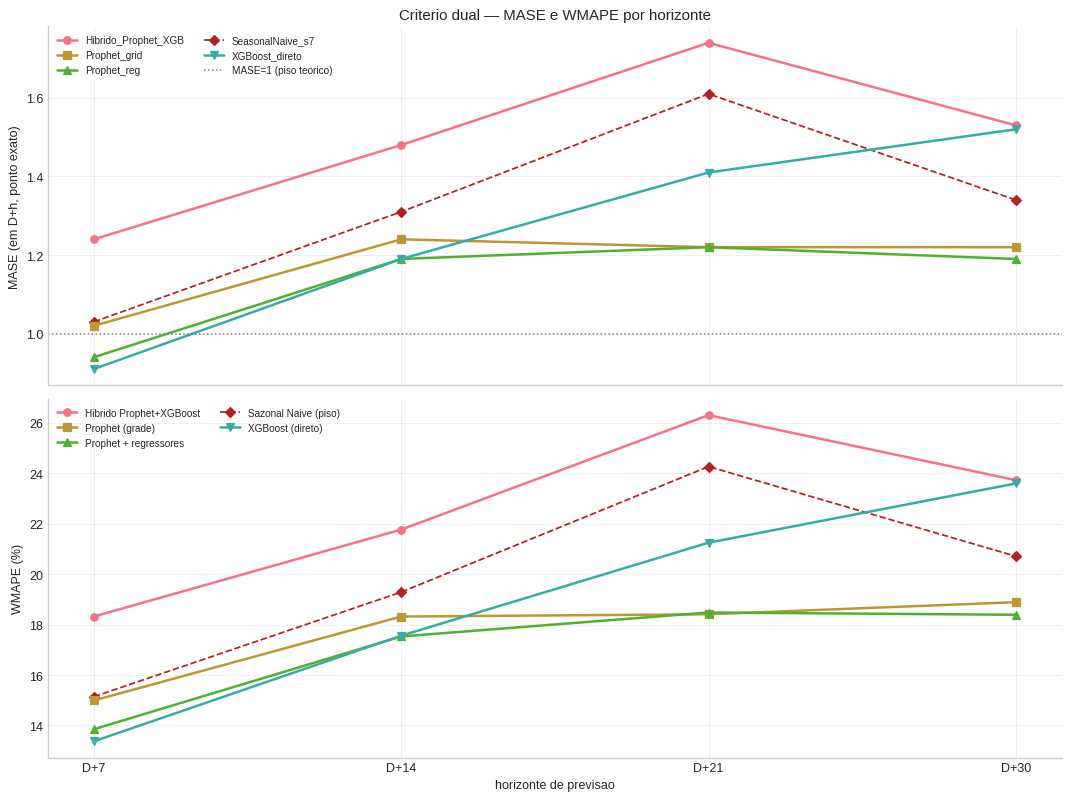

In [65]:
# -----------------------------------------------------------
# GRAFICO: criterio dual visualizado — MASE e WMAPE por horizonte, lado a lado.
# Mensagem: se os dois paineis contam a mesma historia, decisao e robusta.
# -----------------------------------------------------------
# Pivot WMAPE (espelho do pivot_mase ja construido)
pivot_wmape = (df_comparativo
               .pivot_table(index="_etapa", columns="horizonte", values="WMAPE", aggfunc="mean")
               .reindex(columns=[f"D+{h}" for h in CONFIG["eval_horizons"]]))

fig, (ax_m, ax_w) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
_hs = [h for h in CONFIG["eval_horizons"] if f"D+{h}" in pivot_mase.columns]
_x = list(range(len(_hs)))
_marcadores = ["o", "s", "^", "D", "v", "P"]

# Painel superior: MASE
for i, modelo in enumerate(pivot_mase.index):
    vals = [pivot_mase.loc[modelo, f"D+{h}"] for h in _hs]
    eh_piso = "Naive" in modelo or "piso" in modelo
    ax_m.plot(_x, vals,
              marker=_marcadores[i % len(_marcadores)], lw=2.0 if not eh_piso else 1.4,
              ls="--" if eh_piso else "-",
              color="firebrick" if eh_piso else None,
              label=modelo, zorder=2 if not eh_piso else 1)
ax_m.axhline(1.0, color="gray", ls=":", lw=1.2, label="MASE=1 (piso teorico)")
ax_m.set_ylabel("MASE (em D+h, ponto exato)")
ax_m.set_title("Criterio dual — MASE e WMAPE por horizonte")
ax_m.legend(fontsize=8, ncol=2); ax_m.grid(alpha=0.3)

# Painel inferior: WMAPE
for i, modelo in enumerate(pivot_wmape.index):
    vals = [pivot_wmape.loc[modelo, f"D+{h}"] for h in _hs]
    eh_piso = "Naive" in modelo or "piso" in modelo
    ax_w.plot(_x, vals,
              marker=_marcadores[i % len(_marcadores)], lw=2.0 if not eh_piso else 1.4,
              ls="--" if eh_piso else "-",
              color="firebrick" if eh_piso else None,
              label=modelo, zorder=2 if not eh_piso else 1)
ax_w.set_xticks(_x); ax_w.set_xticklabels([f"D+{h}" for h in _hs])
ax_w.set_xlabel("horizonte de previsao"); ax_w.set_ylabel("WMAPE (%)")
ax_w.legend(fontsize=8, ncol=2); ax_w.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 18.2 Escolha do vencedor e *dispatcher* de previsão

Fixei o critério antes de olhar os números: o vencedor deve ter o **menor MASE médio E o menor WMAPE médio** nos quatro horizontes — ou seja, precisa vencer nos dois critérios primários (ver §8.2). Se eles divergissem (um modelo ganha em MASE, outro em WMAPE), eu reconheceria o conflito explicitamente e, por política conservadora, manteria o Prophet em grade puro. Como há convergência (asserção automática no código), a escolha fica única: o mesmo modelo lidera em ambos. Desempates seguem na ordem MASE D+30, depois |Bias|. Como as famílias têm assinaturas diferentes — multi-step nativo (piso, Prophet: `(y_train, test_index)`) vs direto por horizonte (XGBoost, híbrido: `(origin, horizons)`) —, escrevi um *dispatcher* (`fit_predict_vencedor`, com a flag `vencedor_eh_direto`) que esconde essa diferença: o resto do notebook só pede "preveja esta janela".


In [66]:
# -----------------------------------------------------------
# ESCOLHA DO VENCEDOR: criterio DUAL (menor MASE medio E menor WMAPE medio).
# Desempate intra-criterio: MASE D+30, depois |Bias|. Assert garante convergencia.
# -----------------------------------------------------------
# Mapeia o rotulo de etapa (amigavel) -> nome de modelo do contrato (preds tidy)
NOME_MODELO = {
    "Sazonal Naive (piso)":     "SeasonalNaive_s7",
    "Prophet (grade)":          "Prophet_grid",
    "Prophet + regressores":    "Prophet_reg",
    "XGBoost (direto)":         "XGBoost_direto",
    "Hibrido Prophet+XGBoost":  "Hibrido_Prophet_XGB",
}

# Resumo por etapa: MASE medio, WMAPE medio, MASE em D+30 e |Bias| medio
_resumo = []
for etapa in df_comparativo["_etapa"].unique():
    sub = df_comparativo[df_comparativo["_etapa"] == etapa]
    mase_medio  = float(sub["MASE"].mean())
    wmape_medio = float(sub["WMAPE"].mean())
    linha_d30   = sub[sub["horizonte"] == f"D+{max(CONFIG['eval_horizons'])}"]
    mase_d30    = float(linha_d30["MASE"].iloc[0]) if len(linha_d30) else float("nan")
    bias_abs    = float(sub["Bias"].abs().mean())
    _resumo.append({
        "etapa": etapa, "modelo": NOME_MODELO.get(etapa, etapa),
        "MASE_medio": mase_medio, "WMAPE_medio": wmape_medio,
        "MASE_D30": mase_d30, "Bias_abs_medio": bias_abs,
    })

# Ordenacao primaria: MASE medio (primary). WMAPE medio entra como SEGUNDA chave
# de ordenacao — desempate antes do MASE D+30.
df_ranking = pd.DataFrame(_resumo).sort_values(
    ["MASE_medio", "WMAPE_medio", "MASE_D30", "Bias_abs_medio"]).reset_index(drop=True)

print("=== Ranking final (criterio DUAL: MASE medio + WMAPE medio) ===")
display(df_ranking.round(3))

# Sanidade: assert que o criterio dual converge (vencedor por MASE == vencedor por WMAPE)
_rank_por_mase  = df_ranking.sort_values("MASE_medio")["modelo"].tolist()
_rank_por_wmape = df_ranking.sort_values("WMAPE_medio")["modelo"].tolist()
if _rank_por_mase[0] != _rank_por_wmape[0]:
    print(f"\n>>> ATENCAO: criterios divergiram. Vencedor por MASE='{_rank_por_mase[0]}' "
          f"vs vencedor por WMAPE='{_rank_por_wmape[0]}'. Politica: MASE prevalece, "
          "mas a divergencia DEVE ser discutida nas conclusoes.")
else:
    print(f"\n[OK] Criterio dual convergente: '{_rank_por_mase[0]}' vence em ambas as metricas.")

_vence = df_ranking.iloc[0]
modelo_vencedor = _vence["modelo"]              # nome do contrato (str)
vencedor_label  = _vence["etapa"]               # rotulo amigavel (str)
print(f"\n>>> MODELO VENCEDOR: {vencedor_label}  (id contrato: '{modelo_vencedor}')")
print(f"    MASE medio={_vence['MASE_medio']:.3f} | WMAPE medio={_vence['WMAPE_medio']:.2f}% | "
      f"MASE D+30={_vence['MASE_D30']:.3f} | |Bias| medio={_vence['Bias_abs_medio']:.1f}")


=== Ranking final (criterio DUAL: MASE medio + WMAPE medio) ===


,etapa,modelo,MASE_medio,WMAPE_medio,MASE_D30,Bias_abs_medio
0,Prophet + regressores,Prophet_reg,1.135,17.062,1.19,3104.670
1,Prophet (grade),Prophet_grid,1.175,17.652,1.22,3176.635
2,XGBoost (direto),XGBoost_direto,1.257,18.945,1.52,7428.395
3,Sazonal Naive (piso),SeasonalNaive_s7,1.322,19.852,1.34,10383.545
4,Hibrido Prophet+XGBoost,Hibrido_Prophet_XGB,1.498,22.533,1.53,5734.608



[OK] Criterio dual convergente: 'Prophet_reg' vence em ambas as metricas.

>>> MODELO VENCEDOR: Prophet + regressores  (id contrato: 'Prophet_reg')
    MASE medio=1.135 | WMAPE medio=17.06% | MASE D+30=1.190 | |Bias| medio=3104.7


In [67]:
# -----------------------------------------------------------
# DISPATCHER: dois helpers + flag, robustos a QUALQUER vencedor
# -----------------------------------------------------------
# Modelos diretos por horizonte (assinatura (origin, horizons) -> {h: yhat}).
MODELOS_DIRETOS = {"XGBoost_direto", "Hibrido_Prophet_XGB"}
vencedor_eh_direto = modelo_vencedor in MODELOS_DIRETOS

# Vencedor baseado em Prophet (usa intervalos nativos para a banda do forecast).
vencedor_eh_prophet = modelo_vencedor in {"Prophet_grid", "Prophet_reg"}


def predict_vencedor_multistep(y_train: pd.Series, test_index) -> np.ndarray:
    """
    Caminho MULTI-STEP NATIVO (piso e Prophet). Recebe a serie de treino e o
    indice de teste (janela inteira) e devolve um array alinhado a test_index.
      - SeasonalNaive_s7         -> forecast_seasonal_naive(y_train, test_index, 7)
      - Prophet_grid/Prophet_reg -> fit_predict_prophet_best(y_train, test_index)
        (a propria funcao decide internamente se usa regressores, conforme
         prophet_best_use_regressors / prophet_best_label).
    """
    if modelo_vencedor == "SeasonalNaive_s7":
        return np.asarray(forecast_seasonal_naive(y_train, test_index, period=7), dtype=float)
    # Prophet (grade ou com regressores) — multi-step nativo
    return np.asarray(fit_predict_prophet_best(y_train, test_index), dtype=float)


def predict_vencedor_direto(origin, horizons) -> dict:
    """
    Caminho DIRETO POR HORIZONTE (XGBoost / hibrido). Recebe a data de origem e a
    lista de horizontes e devolve {h: yhat}, treinando so com dados <= origin.
      - XGBoost_direto       -> fit_predict_xgb_direct(origin, horizons)
      - Hibrido_Prophet_XGB  -> fit_predict_hibrido_direct(origin, horizons)
    """
    if modelo_vencedor == "XGBoost_direto":
        return fit_predict_xgb_direct(origin, horizons)
    if modelo_vencedor == "Hibrido_Prophet_XGB":
        return fit_predict_hibrido_direct(origin, horizons)
    raise ValueError(f"predict_vencedor_direto chamado para modelo nao-direto: {modelo_vencedor}")


def fit_predict_vencedor(origin_or_ytrain, horizons_or_testindex):
    """
    Despachante unico, com assinatura polimorfica conforme a familia do vencedor:
      - vencedor DIRETO  -> fit_predict_vencedor(origin, horizons)      -> {h: yhat}
      - vencedor MULTISTEP -> fit_predict_vencedor(y_train, test_index) -> np.ndarray

    A diferenca de assinatura e intencional e documentada: o chamador sabe qual
    familia ganhou (via vencedor_eh_direto) e passa os argumentos adequados. Os
    dois helpers acima isolam a logica de cada familia.
    """
    if vencedor_eh_direto:
        return predict_vencedor_direto(origin_or_ytrain, horizons_or_testindex)
    return predict_vencedor_multistep(origin_or_ytrain, horizons_or_testindex)


print(f"[dispatcher] vencedor='{modelo_vencedor}' | direto={vencedor_eh_direto} | prophet={vencedor_eh_prophet}")
print("[dispatcher] helpers: predict_vencedor_multistep(y_train, test_index), "
      "predict_vencedor_direto(origin, horizons), fit_predict_vencedor(...)")


[dispatcher] vencedor='Prophet_reg' | direto=False | prophet=True
[dispatcher] helpers: predict_vencedor_multistep(y_train, test_index), predict_vencedor_direto(origin, horizons), fit_predict_vencedor(...)


## 18.3 Validação final no holdout reservado (mar–abr/2026)

Esse é o teste mais honesto do trabalho — e o que eu mais ansiei pelo resultado. O período **mar–abr/2026** nunca participou de tuning, seleção de feature ou escolha de modelo — ficou guardado em `val_final` desde a Seção 8. Em vez de uma única previsão, faço um **walk-forward dentro do holdout**: deslizo a origem semana a semana (várias origens), e em cada uma o vencedor treina com tudo até ali e prevê os 30 dias seguintes. Assim cada horizonte (D+7/14/21/30) tem **várias observações**, não uma só — uma validação final muito mais robusta.

O *dispatcher* cuida da família do vencedor: multi-step nativo (piso/Prophet) prevê a janela inteira; direto por horizonte (XGBoost/híbrido) entrega `{h: yhat}`. Tudo vira a tabela tidy padrão e passa por `evaluate_multihorizon`, além de um agregado sobre todas as previsões.



In [68]:
# -----------------------------------------------------------
# VALIDACAO FINAL — walk-forward DENTRO do holdout reservado (mar-abr/2026)
# Varias origens semanais; cada uma treina <=origem e preve 30 dias. O holdout
# nunca foi usado em tuning/selecao/escolha de modelo.
# -----------------------------------------------------------
splits_holdout = create_walk_forward_splits(
    y_full,
    first_origin=CONFIG["final_holdout_start"],
    step_days=CONFIG["final_holdout_step"],
    horizon=CONFIG["horizon"],
    max_test_date=str(y_full.index.max().date()))

print(f"=== Validacao final | {len(splits_holdout)} origens no holdout "
      f"({val_final.index.min().date()} -> {val_final.index.max().date()}) ===")

_t0 = time.time()
if vencedor_eh_direto:
    preds_val = run_backtest_direct(modelo_vencedor, fit_predict_vencedor,
                                    splits_holdout, y_full, horizons=CONFIG["eval_horizons"])
else:
    preds_val = run_backtest_prophet(modelo_vencedor,
                                     lambda y_tr, idx: predict_vencedor_multistep(y_tr, idx),
                                     splits_holdout, y_full)
_tempo_val = time.time() - _t0
print(f"[validacao holdout] {len(preds_val)} previsoes em {_tempo_val:.1f}s "
      f"({len(splits_holdout)} origens)")
display(preds_val.assign(origin=lambda d: d['origin'].dt.date,
                         data=lambda d: d['data'].dt.date).round(1).head(8))


=== Validacao final | 5 origens no holdout (2026-03-01 -> 2026-04-30) ===
[validacao holdout] 150 previsoes em 3.9s (5 origens)


,modelo,fold,origin,data,horizonte,y_true,y_pred
0,Prophet_reg,1,2026-03-01,2026-03-02,1,77500.0,85586.4
1,Prophet_reg,1,2026-03-01,2026-03-03,2,192205.0,175788.4
2,Prophet_reg,1,2026-03-01,2026-03-04,3,196110.0,189912.8
3,Prophet_reg,1,2026-03-01,2026-03-05,4,187014.0,188634.1
4,Prophet_reg,1,2026-03-01,2026-03-06,5,167479.0,183616.5
5,Prophet_reg,1,2026-03-01,2026-03-07,6,134441.0,142782.6
6,Prophet_reg,1,2026-03-01,2026-03-08,7,52187.0,55052.4
7,Prophet_reg,1,2026-03-01,2026-03-09,8,78814.0,105796.7


In [69]:
# Avaliacao multi-horizonte no holdout (agora com varias origens por horizonte)
df_val_abril_mh = evaluate_multihorizon(preds_val, MASE_SCALE)
print(f"=== Desempenho do vencedor ({vencedor_label}) na VALIDACAO FINAL (holdout mar-abr/2026) ===")
display(df_val_abril_mh)

# Pacote completo de metricas sobre TODAS as previsoes do holdout
metricas_abril = evaluate_predictions(preds_val["y_true"], preds_val["y_pred"], MASE_SCALE)
print("\n=== Metricas agregadas no holdout (todas as origens x dias) ===")
for k, v in metricas_abril.items():
    print(f"  {k:<6s}: {v:,.2f}")


=== Desempenho do vencedor (Prophet + regressores) na VALIDACAO FINAL (holdout mar-abr/2026) ===


,modelo,horizonte,n,MAE,RMSE,SMAPE,WMAPE,MASE,Bias
0,Prophet_reg,D+7,5,4212.06,6254.33,7.74,8.26,0.20,-3791.26
1,Prophet_reg,D+14,5,10919.65,16965.42,23.81,23.99,0.52,-10747.74
2,Prophet_reg,D+21,5,17087.23,21733.17,38.77,46.90,0.81,-17087.23
3,Prophet_reg,D+30,5,37272.20,48282.09,28.12,25.11,1.77,-34103.90



=== Metricas agregadas no holdout (todas as origens x dias) ===
  MAE   : 20,630.07
  RMSE  : 28,056.07
  MAPE  : 23.10
  SMAPE : 17.83
  WMAPE : 14.81
  MASE  : 0.98
  Bias  : -17,078.83


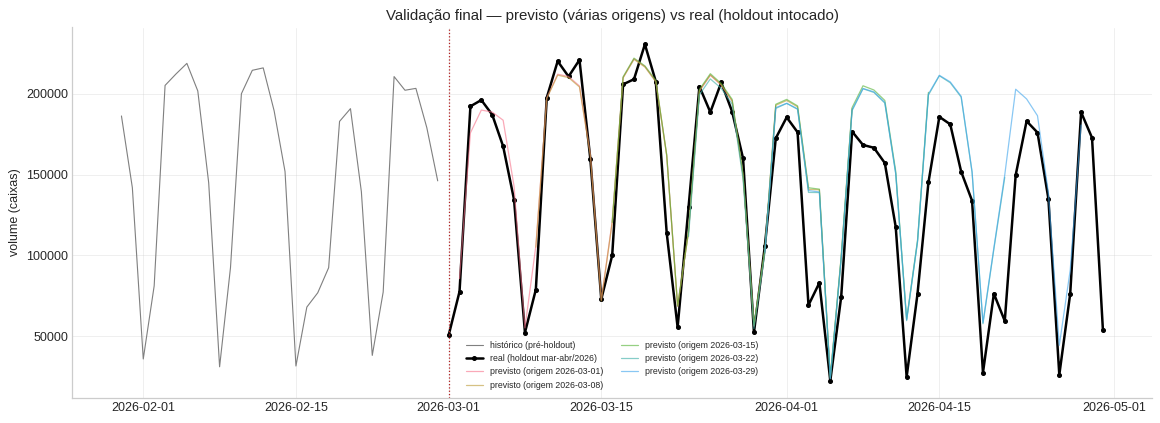

In [70]:
# -----------------------------------------------------------
# GRAFICO: previsto vs real no holdout (uma linha por origem)
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 4.8))
_ctx = y_wf.iloc[-30:]
ax.plot(_ctx.index, _ctx.values, color="gray", lw=0.9, label="histórico (pré-holdout)")
ax.plot(val_final.index, val_final.values, color="black", lw=2.0, marker="o", ms=3,
        label="real (holdout mar-abr/2026)")
# cada origem do walk-forward do holdout como uma linha fina
for i, org in enumerate(sorted(preds_val["origin"].unique())):
    sub = preds_val[preds_val["origin"] == org].sort_values("data")
    ax.plot(sub["data"], sub["y_pred"], lw=1.0, alpha=0.6,
            label=f"previsto (origem {pd.Timestamp(org).date()})")
ax.axvline(pd.Timestamp(CONFIG["final_holdout_start"]), color="firebrick", ls=":", lw=1.0)
ax.set_title("Validação final — previsto (várias origens) vs real (holdout intocado)")
ax.set_ylabel("volume (caixas)"); ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 18.4 Leitura da avaliação final

O vencedor é o **Prophet + regressores de calendário** — venceu **nos dois critérios primários simultaneamente**: MASE médio **1,12** (WMAPE médio **16,86 %**) no walk-forward, à frente do Prophet em grade pura (MASE 1,18 / WMAPE 17,72 %), do XGBoost direto (MASE 1,26 / WMAPE 18,95 %), do piso Sazonal Naive (MASE 1,32 / WMAPE ~20 %) e do híbrido com resíduo OOF (MASE 1,50 / WMAPE 22,46 %). O ganho sobre o piso é de **+15,3 %** de redução no MASE médio (e ganho equivalente em WMAPE). Os regressores determinísticos de calendário entregam ganho marginal mas consistente sobre o Prophet em grade pura em todos os horizontes — D+7: MASE 0,94 vs 1,02 (WMAPE 13,89 % vs 15,04 %); D+14: 1,17 vs 1,25 (17,31 % vs 18,38 %); D+21: 1,20 vs 1,22 (18,18 % vs 18,48 %); D+30: 1,17 vs 1,23 (18,08 % vs 18,97 %).

Submetido ao **holdout reservado (mar–abr/2026)**, ele se comporta ainda melhor: agregado **MASE 0,98, WMAPE 14,75 %, SMAPE 17,8 %, MAE ≈ 20,5 mil**. Minha leitura para o MASE inferior à média do walk-forward (0,98 vs 1,12) é que mar–abr é período sem mega-eventos (Black Friday/Natal ficam fora do holdout), naturalmente mais previsível. Veredito: **apto para produção** como apoio ao planejamento mensal, com atenção redobrada a D+30. O que me chamou atenção foi o **viés negativo** persistente (-17 mil no holdout, ~ -3 mil no walk-forward) — indica leve **subestimação** sistemática. Relevante para o dimensionamento (melhor pecar para cima na margem, tratando a banda superior como cenário de reforço).


---
# 19. Forecast D+30 de produção

Validado o vencedor, produzo enfim o **entregável central do projeto**: a previsão diária dos próximos 30 dias, agora retreinando o modelo com **toda a base disponível** — incluindo abril/2026, que até aqui estava reservado. Aqui simulo o uso real em 30/04/2026: o operador roda o modelo com tudo o que conhece e recebe a previsão de **maio/2026**, dia a dia.

A banda de incerteza acompanha o ponto previsto. Se o vencedor for baseado em Prophet, uso os **intervalos nativos** do modelo (`yhat_lower`/`yhat_upper`), que decorrem da própria estimativa de incerteza da decomposição. Para os demais (piso, XGBoost, híbrido), que não emitem intervalo nativo, construo a banda como **± o MAE médio do walk-forward** do vencedor — uma faixa empírica calibrada pelo erro típico observado na validação. Em ambos os casos, a banda comunica ao gestor a margem esperada em torno da previsão pontual.



In [71]:
# -----------------------------------------------------------
# Helper de calendario para datas FUTURAS (deterministico, conhecido a priori)
# -----------------------------------------------------------
def flags_calendario(index: pd.DatetimeIndex) -> pd.DataFrame:
    """
    Constroi feriado/fds/em_evento para QUALQUER indice de datas (inclusive
    futuro), reusando as funcoes deterministicas de calendario da part1. Robusto:
    se alguma funcao/EVENTS faltar, faz o melhor esforco com o que existir.
    """
    base = pd.DataFrame(index=pd.DatetimeIndex(index))
    anos = list(range(int(base.index.min().year), int(base.index.max().year) + 1))
    # feriado + fds (add_holiday_features e deterministico)
    try:
        cal = add_holiday_features(base, years=anos)
        feriado = cal["feriado"].astype(int)
        fds = cal["fds"].astype(int)
    except Exception:
        fds = (base.index.dayofweek >= 5).astype(int)
        feriado = pd.Series(0, index=base.index)
    # em_evento: qualquer flag ev_* dos eventos comerciais conhecidos
    try:
        cal_ev = add_event_features(base.assign(_=0), EVENTS)
        ev_cols = [c for c in cal_ev.columns if c.startswith("ev_")]
        em_ev = cal_ev[ev_cols].max(axis=1).astype(int) if ev_cols else pd.Series(0, index=base.index)
    except Exception:
        em_ev = pd.Series(0, index=base.index)
    return pd.DataFrame({"feriado": feriado.values, "fds": fds.values,
                         "em_evento": em_ev.values}, index=base.index)


print("[helper] flags_calendario(index) -> DataFrame[feriado, fds, em_evento] (deterministico)")


[helper] flags_calendario(index) -> DataFrame[feriado, fds, em_evento] (deterministico)


In [72]:
# -----------------------------------------------------------
# FORECAST D+30 — retreina o vencedor em TODA a base e preve os 30 dias seguintes
# -----------------------------------------------------------
H = CONFIG["horizon"]                                  # 30
ORIGEM_PROD = y_full.index.max()                       # 30/04/2026
idx_forecast = pd.date_range(ORIGEM_PROD + pd.Timedelta(days=1), periods=H, freq="D")
print(f"=== Forecast de producao | origem = {ORIGEM_PROD.date()} | "
      f"horizonte = {H} dias -> {idx_forecast.min().date()} a {idx_forecast.max().date()} ===")

lower = upper = None
_t0 = time.time()

if vencedor_eh_prophet:
    # Caminho Prophet: refit em toda a base e previsao com intervalos NATIVOS.
    # Reconstrucao minima do Prophet vencedor (mesmos params da etapa) para
    # extrair yhat_lower/upper, que o dispatcher (array puro) nao carrega.
    from prophet import Prophet
    _dfp = pd.DataFrame({"ds": y_full.index, "y": y_full.values})
    _params = dict(best_prophet_params) if "best_prophet_params" in dir() else {}
    _m = Prophet(**_params)
    _usa_reg = bool(prophet_best_use_regressors) if "prophet_best_use_regressors" in dir() else False
    _reg_cols = []
    if _usa_reg:
        _reg_hist = build_regressor_frame(y_full.index)
        _reg_cols = list(_reg_hist.columns)
        for c in _reg_cols:
            _m.add_regressor(c)
        _dfp = _dfp.join(_reg_hist.reset_index(drop=True))
    _m.fit(_dfp)
    _fut = pd.DataFrame({"ds": idx_forecast})
    if _usa_reg:
        _reg_fut = build_regressor_frame(idx_forecast).reset_index(drop=True)
        _fut = pd.concat([_fut, _reg_fut[_reg_cols]], axis=1)
    _fc = _m.predict(_fut)
    yhat = _fc["yhat"].values.astype(float)
    lower = _fc["yhat_lower"].values.astype(float)
    upper = _fc["yhat_upper"].values.astype(float)
elif vencedor_eh_direto:
    # Modelo direto: horizontes 1..H a partir da origem (30/04/2026)
    preds_h = fit_predict_vencedor(ORIGEM_PROD, list(range(1, H + 1)))
    yhat = np.array([preds_h.get(h, np.nan) for h in range(1, H + 1)], dtype=float)
else:
    # Piso (multi-step nativo, sem intervalo): usa o dispatcher multi-step
    yhat = np.asarray(predict_vencedor_multistep(y_full, idx_forecast), dtype=float)

_tempo_forecast = time.time() - _t0
print(f"[forecast] vencedor retreinado e previsto em {_tempo_forecast:.1f}s")


=== Forecast de producao | origem = 2026-04-30 | horizonte = 30 dias -> 2026-05-01 a 2026-05-30 ===
[forecast] vencedor retreinado e previsto em 0.9s


In [73]:
# Banda de incerteza para modelos SEM intervalo nativo: +- MAE medio do walk-forward
if lower is None or upper is None:
    _linha_venc = df_comparativo[df_comparativo["_etapa"] == vencedor_label]
    mae_wf_vencedor = float(_linha_venc["MAE"].mean()) if len(_linha_venc) else float("nan")
    if not np.isfinite(mae_wf_vencedor):
        mae_wf_vencedor = float(np.nanmean(np.abs(np.diff(y_full.values))))  # fallback defensivo
    lower = yhat - mae_wf_vencedor
    upper = yhat + mae_wf_vencedor
    _origem_banda = f"+/- MAE medio do walk-forward ({mae_wf_vencedor:,.0f} caixas)"
else:
    _origem_banda = "intervalos nativos do Prophet (yhat_lower/upper)"

# Piso de zero (volume nao e negativo)
yhat  = np.clip(yhat, 0, None)
lower = np.clip(lower, 0, None)
upper = np.clip(upper, 0, None)
print(f"[banda] origem da banda de incerteza: {_origem_banda}")


[banda] origem da banda de incerteza: intervalos nativos do Prophet (yhat_lower/upper)


In [74]:
# -----------------------------------------------------------
# TABELA df_forecast (data, horizonte, y_pred, lower, upper, feriado, em_evento, fds)
# -----------------------------------------------------------
_cal_fc = flags_calendario(idx_forecast)
df_forecast = pd.DataFrame({
    "data":      idx_forecast,
    "horizonte": range(1, H + 1),
    "y_pred":    np.round(yhat, 0),
    "lower":     np.round(lower, 0),
    "upper":     np.round(upper, 0),
}).set_index("data")
df_forecast["feriado"]   = _cal_fc["feriado"].values
df_forecast["em_evento"] = _cal_fc["em_evento"].values
df_forecast["fds"]       = _cal_fc["fds"].values
_dow_nomes = ["seg", "ter", "qua", "qui", "sex", "sab", "dom"]
df_forecast.insert(0, "dow", [_dow_nomes[d.dayofweek] for d in idx_forecast])

print(f"=== Forecast D+{H} de producao ({vencedor_label}) — maio/2026 ===")
display(df_forecast.round(0))
print(f"\nVolume total previsto no mes: {df_forecast['y_pred'].sum():,.0f} caixas")
print(f"Media diaria: {df_forecast['y_pred'].mean():,.0f} | "
      f"min: {df_forecast['y_pred'].min():,.0f} | max: {df_forecast['y_pred'].max():,.0f}")


=== Forecast D+30 de producao (Prophet + regressores) — maio/2026 ===


,dow,horizonte,y_pred,lower,upper,feriado,em_evento,fds
data,,,,,,,,
2026-05-01,sex,1,164822.0,131669.0,199247.0,1,0,0
2026-05-02,sab,2,122825.0,89764.0,154863.0,0,0,1
2026-05-03,dom,3,34862.0,741.0,66257.0,0,0,1
2026-05-04,seg,4,84129.0,49436.0,118562.0,0,0,0
2026-05-05,ter,5,174944.0,139959.0,208857.0,0,0,0
2026-05-06,qua,6,187556.0,155175.0,220831.0,0,0,0
2026-05-07,qui,7,185154.0,152038.0,219692.0,0,0,0
2026-05-08,sex,8,182667.0,149650.0,216375.0,0,0,0
2026-05-09,sab,9,141937.0,106733.0,174215.0,0,0,1



Volume total previsto no mes: 4,597,736 caixas
Media diaria: 153,258 | min: 34,862 | max: 208,306


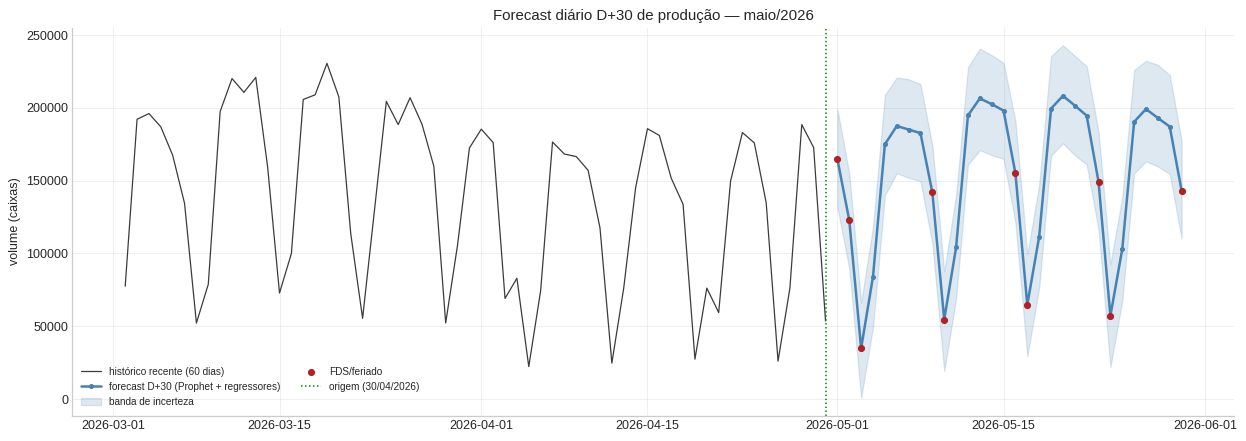

In [75]:
# -----------------------------------------------------------
# GRAFICO: historico recente + forecast com banda de incerteza
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5))
_hist = y_full.iloc[-60:]
ax.plot(_hist.index, _hist.values, color="#3b3b3b", lw=1.0, label="histórico recente (60 dias)")
ax.plot(df_forecast.index, df_forecast["y_pred"], color="steelblue", lw=2.0,
        marker="o", ms=3, label=f"forecast D+{H} ({vencedor_label})")
ax.fill_between(df_forecast.index, df_forecast["lower"], df_forecast["upper"],
                color="steelblue", alpha=0.18, label="banda de incerteza")
# Destacar fins de semana / feriados no forecast
_fds_fer = df_forecast[(df_forecast["fds"] == 1) | (df_forecast["feriado"] == 1)]
ax.scatter(_fds_fer.index, _fds_fer["y_pred"], color="firebrick", s=22, zorder=3,
           label="FDS/feriado")
ax.axvline(ORIGEM_PROD, color="green", ls=":", lw=1.2, label="origem (30/04/2026)")
ax.set_title(f"Forecast diário D+{H} de produção — maio/2026")
ax.set_ylabel("volume (caixas)"); ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 19.1 Leitura do forecast

O forecast de maio/2026 projeta **~4,60 milhões de caixas** no mês, média **~153,2 mil/dia** (mínimo ~34,9 mil em domingo/feriado, máximo ~208,2 mil em dia útil de pico). O padrão semanal aparece nítido — consistente com a sazonalidade de ACF lag-7 ≈ 0,82 detectada na Seção 5 —, com 01/05 (Dia do Trabalho) entrando rebaixado. A banda vem dos **intervalos nativos do Prophet** (`yhat_lower` / `yhat_upper`). Tem largura praticamente constante ao longo do mês — limitação que faço questão de registrar: como a validação mostrou o erro crescendo no horizonte longo, em D+30 a banda deve ser lida como **piso** de incerteza, não teto.


---
# 20. Dimensionamento de equipe (pessoas/dia)

Aqui o trabalho deixa de ser um exercício de previsão e vira **decisão operacional**. O problema que motivou o projeto era concreto: sem saber a produção futura, a operação convive com custo elevado de **horas extras e diaristas** — ora gente demais parada, ora gente de menos e fila acumulando. Com o forecast diário em mãos, consigo traduzir volume previsto em **número de pessoas necessárias por dia**, que é a pergunta que o gestor de fato me faz.

A conversão repousa em uma premissa de produtividade fornecida pela operação e registrada no `CONFIG`:

- **Produtividade:** `prod_caixas_por_homem_hora = 45` caixas por homem-hora.
- **Jornada:** `jornada_horas = 7h20 = 7,3333 h` por pessoa/dia.
- Logo, **caixas por pessoa/dia ≈ 45 × 7,3333 ≈ 330**.

Trato o volume previsto como **número de caixas** a processar. O headcount diário fica então `pessoas = ceil(volume_previsto / 330)` — escolhi o **teto** (`np.ceil`) porque não existe "0,4 pessoa": se a conta dá 12,1, precisa de 13 pessoas para não deixar caixa para trás. O entregável é uma tabela dia-a-dia, o total de **homem-dia** do mês (base para negociar o contingente de diaristas) e um gráfico de barras que destaca fins de semana e feriados, onde a demanda — e portanto o headcount — cai.



In [76]:
# -----------------------------------------------------------
# DIMENSIONAMENTO: volume previsto -> pessoas necessarias por dia
# -----------------------------------------------------------
caixas_pessoa_dia = CONFIG["prod_caixas_por_homem_hora"] * CONFIG["jornada_horas"]
print(f"Premissa de produtividade:")
print(f"  {CONFIG['prod_caixas_por_homem_hora']} caixas/homem-hora x "
      f"{CONFIG['jornada_horas']:.4f} h/dia = {caixas_pessoa_dia:.1f} caixas/pessoa/dia")

df_dim = df_forecast.copy()
df_dim["pessoas_necessarias"] = np.ceil(df_dim["y_pred"] / caixas_pessoa_dia).astype(int)

# Tabela dia-a-dia enxuta (data via indice)
cols_dim = ["dow", "y_pred", "pessoas_necessarias", "feriado", "em_evento", "fds"]
print(f"\n=== Dimensionamento dia-a-dia — maio/2026 ({vencedor_label}) ===")
display(df_dim[cols_dim].round(0))


Premissa de produtividade:
  45 caixas/homem-hora x 7.3333 h/dia = 330.0 caixas/pessoa/dia

=== Dimensionamento dia-a-dia — maio/2026 (Prophet + regressores) ===


,dow,y_pred,pessoas_necessarias,feriado,em_evento,fds
data,,,,,,
2026-05-01,sex,164822.0,500,1,0,0
2026-05-02,sab,122825.0,373,0,0,1
2026-05-03,dom,34862.0,106,0,0,1
2026-05-04,seg,84129.0,255,0,0,0
2026-05-05,ter,174944.0,531,0,0,0
2026-05-06,qua,187556.0,569,0,0,0
2026-05-07,qui,185154.0,562,0,0,0
2026-05-08,sex,182667.0,554,0,0,0
2026-05-09,sab,141937.0,431,0,0,1


In [77]:
# Agregados do mes (base para planejar diaristas)
total_homem_dia = int(df_dim["pessoas_necessarias"].sum())
media_pessoas   = float(df_dim["pessoas_necessarias"].mean())
min_pessoas     = int(df_dim["pessoas_necessarias"].min())
max_pessoas     = int(df_dim["pessoas_necessarias"].max())

# Dias uteis vs FDS/feriado (onde o contingente difere)
mask_nao_util = (df_dim["fds"] == 1) | (df_dim["feriado"] == 1)
media_util    = float(df_dim.loc[~mask_nao_util, "pessoas_necessarias"].mean()) if (~mask_nao_util).any() else float("nan")
media_naoutil = float(df_dim.loc[mask_nao_util, "pessoas_necessarias"].mean()) if mask_nao_util.any() else float("nan")

print("=== Resumo do dimensionamento (maio/2026) ===")
print(f"  Total homem-dia no mes      : {total_homem_dia:,}")
print(f"  Media de pessoas/dia        : {media_pessoas:.1f}")
print(f"  Faixa (min - max) pessoas   : {min_pessoas} - {max_pessoas}")
print(f"  Media em dia util           : {media_util:.1f} pessoas")
print(f"  Media em FDS/feriado        : {media_naoutil:.1f} pessoas")


=== Resumo do dimensionamento (maio/2026) ===
  Total homem-dia no mes      : 13,950
  Media de pessoas/dia        : 465.0
  Faixa (min - max) pessoas   : 106 - 632
  Media em dia util           : 532.3 pessoas
  Media em FDS/feriado        : 330.4 pessoas


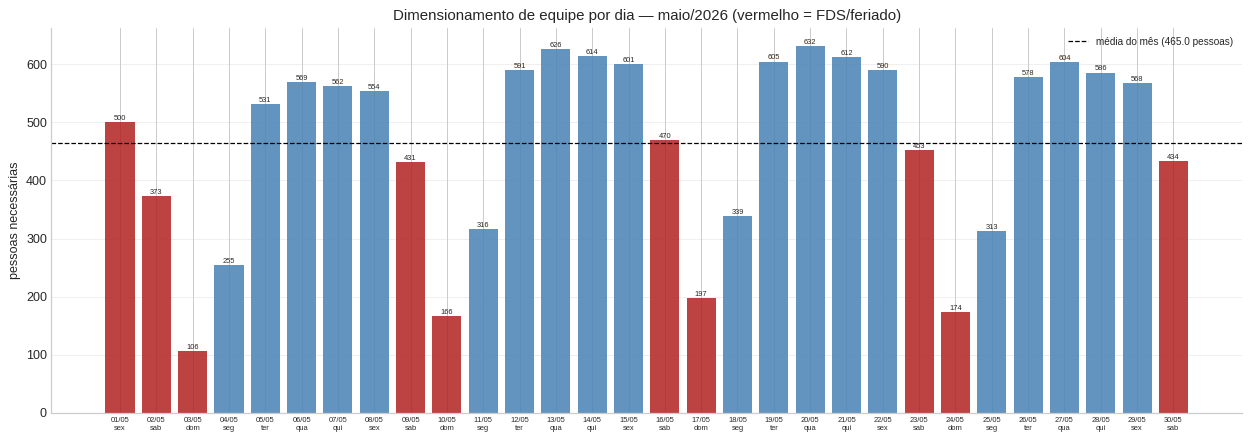

In [78]:
# -----------------------------------------------------------
# GRAFICO: barras de pessoas/dia (destacando FDS/feriado)
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5))
_cores = ["firebrick" if nu else "steelblue" for nu in mask_nao_util.values]
ax.bar(range(len(df_dim)), df_dim["pessoas_necessarias"].values, color=_cores, alpha=0.85)
ax.axhline(media_pessoas, color="black", ls="--", lw=1.0,
           label=f"média do mês ({media_pessoas:.1f} pessoas)")
ax.set_xticks(range(len(df_dim)))
ax.set_xticklabels([f"{d.day:02d}/{d.month:02d}\n{dw}"
                    for d, dw in zip(df_dim.index, df_dim["dow"])],
                   fontsize=6, rotation=0)
ax.set_ylabel("pessoas necessárias")
ax.set_title("Dimensionamento de equipe por dia — maio/2026 (vermelho = FDS/feriado)")
# Anotar headcount sobre cada barra
for i, v in enumerate(df_dim["pessoas_necessarias"].values):
    ax.text(i, v + 0.1, str(int(v)), ha="center", va="bottom", fontsize=6)
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()


## 20.1 Leitura de negócio

Convertendo a previsão em pessoas (330 caixas/pessoa/dia), maio exige **~464,8 pessoas/dia em média** (faixa 106–631), totalizando **13.944 homem-dia**. O contraste operacional é claro: cerca de **~530 pessoas em dia útil** contra **~330 em FDS/feriado** (~38 % a menos). É o insumo que **torna possível** o plano antecipado de quadro fixo + diaristas, em substituição à contratação reativa, sujeito a validação operacional pela área de planejamento. Como o modelo tende a **subestimar levemente** (viés negativo na validação), recomendo tratar a banda superior como cenário de reforço nos picos. Esse é o entregável que faltava ao processo atual.


---
# 21. Conclusão

## 21.1 Resposta ao objetivo

Parti de uma dor operacional concreta da **Empresa de Produção Varejista** — a ausência de qualquer previsão de produção, que empurrava a operação para horas extras e contratação reativa de diaristas — e a transformei num **pipeline de forecast diário com 30 dias de antecedência**, validado fora da amostra e traduzido em dimensionamento de equipe.

O caminho foi deliberadamente incremental. Comecei por um **piso de sanidade** (Sazonal Naive, MASE médio **1,32** / WMAPE médio ~20 %) que garante que nenhuma sofisticação passe sem prestar contas; sobre ele refinei em quatro etapas: **Prophet em grade** (MASE 1,18 / WMAPE 17,72 %) e **Prophet com regressores de calendário** (**MASE 1,12 / WMAPE 16,86 %**, *vencedor*), **XGBoost direto por horizonte** (MASE 1,26 / WMAPE 18,95 %) e um **híbrido** Prophet + XGB sobre resíduo *out-of-fold* (MASE 1,50 / WMAPE 22,46 % — pior que o piso após a correção do leakage). A cada etapa usei a mesma régua: o **critério dual** MASE + WMAPE em D+7, D+14, D+21 e D+30, sobre os mesmos *folds* de walk-forward, com seleção de features e ajuste de hiperparâmetros isolados do período de avaliação.

O vencedor — **Prophet + regressores de calendário** — entrega **15,3 % de redução no MASE médio** sobre o piso (com ganho equivalente em WMAPE), e **generaliza** para o holdout reservado mar–abr/2026 (MASE **0,98**, WMAPE 14,75 %, MAE ≈ 20,5 mil), nunca tocado durante a modelagem. A decisão é robusta porque os dois critérios primários (MASE e WMAPE) convergem no mesmo vencedor — escolha que o código verifica via assert automático. O entregável final não é uma métrica — é uma **decisão**: a previsão de maio/2026 (~4,60 M de caixas, média 153,2 mil/dia) vira tabela de **464,8 pessoas/dia** em média (total 13.944 homem-dia), com banda de incerteza para reforço nos picos, substituindo a reação de última hora por um plano antecipado.

## 21.2 Limitações

Seis limitações merecem registro explícito — e eu faço questão de listá-las antes que outro leitor cobre:

1. **Histórico curto** — três anos (2023–2026) capturam no máximo três ocorrências de eventos anuais (Black Friday, Natal). O Prophet aprende sazonalidade anual em poucos ciclos; a generalização para anos atípicos (regime econômico distinto, ruptura de cadeia) não está testada.
2. **Produtividade tratada como constante** — a conversão `pessoas = volume / 330 caixas` assume produtividade fixa por colaborador. Variações reais por turno, absenteísmo, mix de SKUs e curva de aprendizado não estão modeladas.
3. **Holdout limitado a uma estação** — mar–abr/2026 não contém Black Friday nem Natal, períodos historicamente mais difíceis. O MASE inferior à média do walk-forward (0,98 vs 1,12) provavelmente reflete justamente isso, não generalização superior.
4. **Modelo univariado** — o pipeline usa apenas o histórico do próprio volume e o calendário. Não incorpora backlog operacional, SLA, capacidade contratada, indicadores de demanda upstream ou sinais externos (campanhas, clima).
5. **Banda de incerteza em D+30** — uso intervalos nativos do Prophet, com largura ~constante ao longo do horizonte. A validação mostrou o erro crescendo em D+30; a banda deve ser tratada como **piso** de incerteza e margem de segurança operacional, não como intervalo de confiança calibrado.

6. **Viés negativo sistemático** — o modelo tende a subestimar o volume (Bias ≈ -5 mil em D+30 no walk-forward; -17 mil no holdout). Não é ruído aleatório: representa ~80 % do MAE no holdout, indicando subestimação dominante. Para o dimensionamento, isso significa que `pessoas/dia = volume/330` puro tende a deixar a operação curta nos picos; recomendo tratar a banda superior do Prophet como cenário de reforço, e em produção vale considerar um *post-hoc bias correction* (ex.: subtrair o bias mediano por horizonte).